In [5]:
from tqdm import tqdm
import re,os,glob, time
import datetime
import ast
import html
import json
import warnings
import tempfile
import nbformat
import subprocess
from pathlib import Path
from nbformat.v4 import new_notebook, new_code_cell
from multiprocessing import Pool, Manager, RLock
import multiprocessing
warnings.filterwarnings("ignore", category=SyntaxWarning)

parent = './fetch/competitions'

def init_pool(l):
    """Initialize the worker process with a shared lock for tqdm."""
    tqdm.set_lock(l)

def get_folders(base_path):
    """Get the folder names under the base path"""
    return [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]

def read_html_content(file_path, nb=None):
    """Read the content of an HTML file and append code cells to notebook if provided"""

    with open(file_path, "r", encoding="utf-8") as file:
        content = file.read()

        # Find all code blocks with highlight hl-ipython class
        highlight_blocks = re.findall(r'<div class="highlight hl-ipython">(.*?)</div>', content, re.DOTALL) or re.findall(r'<div class="highlight hl-ipython2">(.*?)</div>', content, re.DOTALL) or re.findall(r'<div class="highlight hl-ipython3">(.*?)</div>', content, re.DOTALL)
        
        # Process all input areas as before for backward compatibility
        input_areas = re.findall(r'<div class="input_area">(.*?)</div>', content, re.DOTALL)
        input_areas = "".join(input_areas) if input_areas else ""
        input_areas = re.sub(r' *<pre>', '<pre>', input_areas)
        
        # If notebook object provided, add each code block as a cell
        if nb is not None:
            for block in highlight_blocks:
                # Extract code from the highlight block
                code_match = re.search(r'<pre>(.*?)</pre>', block, re.DOTALL)
                if code_match:
                    # Clean up the code
                    code_text = html.unescape(code_match.group(1))
                    raw_code = assemble_code_regex(code_text)
                    # code = inspect.cleandoc(raw_code)
                    raw_code = re.sub(r"(?m)^\s*!\s*pip\s+install\b.*\n?", "", raw_code)
                    nb.cells.append(new_code_cell(raw_code))
        
        return nb
    
def assemble_code_regex(html_snippet: str) -> str:
    """
    Uses a regular expression to remove HTML tags from the snippet and unescapes HTML entities.
    """
    # Unescape any HTML entities (if present)
    code = html.unescape(html_snippet)
    # Remove all HTML tags using regex
    code = re.sub(r'</?[a-zA-Z][^>]*>', '', code)

    return code


def time_to_seconds(text):
    """
    Extracts hours, minutes, and seconds from a text and converts them to seconds.
    Expected formats are, for example, "4s", "1m 54s", or "1h 59m 59s".
    """
    # The regex looks for optional hours and minutes, and mandatory seconds.
    time_pattern = r'(?:(?P<h>\d+)\s*h)?\s*(?:(?P<m>\d+)\s*m)?\s*(?P<s>\d+)\s*s'
    match = re.search(time_pattern, text)
    if match:
        h = int(match.group('h')) if match.group('h') is not None else 0
        m_val = int(match.group('m')) if match.group('m') is not None else 0
        s = int(match.group('s'))
        return h * 3600 + m_val * 60 + s
    return None


competitions = get_folders(parent)
# Prepare arguments for each worker
args_list = [(comp, parent) for comp in competitions]

total = 0
r_script = 0
p_script = 0
date_range = []

for competi in tqdm(competitions):
    total += len(glob.glob(os.path.join(parent, competi, 'meta_html','*.html')))
    files = glob.glob(os.path.join(parent, competi, 'meta_html','*_C1.html'))

    for file in files:
        # Extract dependencies
        path = os.path.join(parent, competi, 'html', file.split("/")[-1])
        # Create notebook first
        nb = new_notebook()
        # Pass notebook to read_html_content to add cells directly
        nb = read_html_content(path, nb)

        # If no cells were added, add the whole content as one cell
        if len(nb.cells) == 1:
            r_script += 1
        else:
            p_script += 1
            with open(os.path.join(parent, competi, 'meta_html',file.split("/")[-1]), "r", encoding="utf-8") as fp:
                content = fp.read()
            # Submission Year
            pattern = r'<span [^>]*title="([A-Z][a-z]{2} [A-Z][a-z]{2} \d{2} \d{4} \d{2}:\d{2}:\d{2} GMT[+-]\d{4} \([^"]+\))"'
            date = re.findall(pattern, content, re.DOTALL)[0]
            # print(date)
            date_str = date.split(" (")[0].replace("GMT", "")
            # print(date_str)
            dt = datetime.datetime.strptime(date_str, "%a %b %d %Y %H:%M:%S %z")
            date_range.append(dt)

print(f"Total files collected: {total}")
print(f"R scripts: {r_script}, Python scripts: {p_script}")
print(f"Date range: {min(date_range)} to {max(date_range)}")

100%|██████████| 79/79 [19:35<00:00, 14.88s/it]

Total files collected: 171075
R scripts: 2335, Python scripts: 148901
Date range: 2016-08-30 04:33:06-04:00 to 2025-04-04 11:38:12-04:00


In [ ]:
tot = 0
tot_c1 = 0
parent = './fetch/competitions'
for competi in tqdm(get_folders(parent)):
    tot += len(glob.glob(os.path.join(parent, competi,'meta_html','*.html')))
    tot_c1 += len(glob.glob(os.path.join(parent, competi,'meta_html','*_C1.html')))
print(f'Total files in all competitions: {tot}')
print(f'Total runnable _C1 files in all competitions: {tot_c1}')

  0%|          | 0/79 [00:00<?, ?it/s]

100%|██████████| 79/79 [00:00<00:00, 171.83it/s]

Total files in all competitions: 171075
Total runnable _C1 files in all competitions: 151236


# data stats

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import json

import os
from glob import glob
import pandas as pd
import codecs
from pathlib import Path

filename = "../.kaggle/KernelVersions.csv"
versions = pd.read_csv(filename,low_memory=False)

filename = "../.kaggle/Kernels.csv"
kernels = pd.read_csv(filename)

filename = "../.kaggle/KernelVersionDatasetSources.csv"
src = pd.read_csv(filename)

filename = "../.kaggle/Teams.csv"
teams = pd.read_csv(filename,low_memory=False)

filename = "../.kaggle/Submissions.csv"
submissions_df = pd.read_csv(filename,low_memory=False)

filename = "../.kaggle/Competitions.csv"
competitions_df = pd.read_csv(filename)

filename = "../.kaggle/Users.csv"
users = pd.read_csv(filename,low_memory=False)

def idToPath(id):
    f = str(id).zfill(10)
    prefix = '../.kaggle/meta-kaggle-code/'+f[0:4]+'/'+f[4:7]+'/'+str(id)+'.*'
    g = glob(prefix)
    if len(g) == 1:
        return g[0]
    return ""

def ftype(p):
    parts = os.path.splitext(p)
    if len(parts) != 2:
        return ""
    return parts[1]

def pathToId(p):
    parts = os.path.splitext(os.path.basename(p))
    if len(parts) != 2:
        return ""
    if parts[0] != "":
        return int(parts[0])
    return None

def rawSource(path):
    return Path(path).read_text()

def ipynbSource(path):
    f = codecs.open(path, 'r')
    source = f.read()
    
    jsource = json.loads(rawSource(path))
    cells = []
    for cell in jsource['cells']:
        cells.append(cell['source'])
    return cells

def sourceCode(path):
    t = ftype(path)
    if t == ".ipynb":
        return ipynbSource(path)
    return [Path(path).read_text()]

def sourceCodeById(id):
    p = idToPath(id)
    if p != "":
        return sourceCode(p)
    return None

def versionById(id):
    return versions.loc[id]
# def kernelById(id):
#     return kernels.loc[id]

src_kernel_version_id = pd.to_numeric(src["KernelVersionId"], errors="coerce")
def sourceDatasetByVersionId(id):
    kid = pd.to_numeric(pd.Series([id]), errors="coerce").iloc[0]
    return src.loc[src_kernel_version_id == kid, "SourceDatasetVersionId"].tolist()

def teamByCompetitionId(id):
    return teams.loc[teams["CompetitionId"] == id, "Id"].tolist()

def submissionByKernelId(ids):
    if not ids:
        return []

    # Vectorized numeric validation keeps retrieval fast on large tables.
    public_score = pd.to_numeric(submissions_df["PublicScoreFullPrecision"], errors="coerce")
    private_score = pd.to_numeric(submissions_df["PrivateScoreFullPrecision"], errors="coerce")

    mask = (
        submissions_df["TeamId"].isin(ids)
        & (private_score.notna())
        & (private_score.ne(0))
    )

    kernel_version_ids = (
        pd.to_numeric(submissions_df.loc[mask, "SourceKernelVersionId"], errors="coerce")
        .dropna()
        .astype("int64")
        .unique()
    )

    return kernel_version_ids.tolist()

def chosen_submission_has_valid_private_score(kernel_id):
    kernel_id_num = pd.to_numeric(pd.Series([kernel_id]), errors="coerce").iloc[0]
    if pd.isna(kernel_id_num):
        return False

    version_rows = versions.loc[version_ids == kernel_id_num]
    if version_rows.empty:
        return False

    version = version_rows.iloc[0]
    version_evaluation_dt = pd.to_datetime(
        pd.Series([version.get("EvaluationDate")]),
        errors="coerce"
    ).iloc[0]
    version_creation_dt = pd.to_datetime(
        pd.Series([version.get("CreationDate")]),
        errors="coerce"
    ).iloc[0]

    kernel_submissions = submissions_df.loc[
        pd.to_numeric(submissions_df["SourceKernelVersionId"], errors="coerce") == kernel_id_num
    ].copy()
    if kernel_submissions.empty:
        return False

    kernel_submissions["_submission_dt"] = pd.to_datetime(
        kernel_submissions["SubmissionDate"],
        format="%m/%d/%Y",
        errors="coerce"
    )

    if "ScoreDate" in kernel_submissions.columns:
        kernel_submissions["_score_dt"] = pd.to_datetime(
            kernel_submissions["ScoreDate"],
            errors="coerce"
        )
    else:
        kernel_submissions["_score_dt"] = pd.NaT

    kernel_submissions = kernel_submissions.sort_values(
        "_submission_dt", ascending=False, na_position="last"
    )

    def same_calendar_day(left, right):
        if pd.isna(left) or pd.isna(right):
            return False
        return left.date() == right.date()

    def match_rank(submission):
        if same_calendar_day(submission.get("_score_dt"), version_evaluation_dt):
            return 2
        if same_calendar_day(submission.get("_submission_dt"), version_creation_dt):
            return 1
        return 0

    best_submission = None
    best_rank = -1

    for _, submission in kernel_submissions.iterrows():
        rank = match_rank(submission)
        if rank > best_rank:
            best_submission = submission
            best_rank = rank

    if best_submission is None:
        return False

    private_score = pd.to_numeric(
        pd.Series([best_submission.get("PrivateScoreFullPrecision")]),
        errors="coerce"
    ).iloc[0]

    return pd.notna(private_score) and float(private_score) != 0.0
    
def competitionByName(name):
    return competitions_df.loc[competitions_df['Slug'] == name].iloc[0]

In [4]:
cutoff = pd.Timestamp("2025-05-31")

with open("./fetch/competitions.txt") as f:
    competition_slugs = {line.strip() for line in f if line.strip()}

competition_ids = set(
    competitions_df.loc[
        competitions_df["Slug"].isin(competition_slugs),
        "Id"
    ]
)

team_ids = set(
    teams.loc[
        teams["CompetitionId"].isin(competition_ids),
        "Id"
    ]
)

submission_kernel_ids = set(
    pd.to_numeric(
        submissions_df.loc[
            submissions_df["TeamId"].isin(team_ids),
            "SourceKernelVersionId"
        ],
        errors="coerce"
    )
    .dropna()
    .astype("int64")
)

version_creation_dates = pd.to_datetime(
    versions["CreationDate"],
    errors="coerce"
)

version_ids = pd.to_numeric(versions["Id"], errors="coerce")

items = versions.loc[
    version_ids.isin(submission_kernel_ids)
    & version_creation_dates.lt(cutoff)
]

print(f"Total number ofscripts w/o applying filters: {len(items)}")

slugs_with_items = 0
for slug in competition_slugs:
    compt_id = competitions_df.loc[competitions_df["Slug"] == slug, "Id"]
    if compt_id.empty:
        continue
    t_ids = set(teams.loc[teams["CompetitionId"] == compt_id.iloc[0], "Id"])
    sk_ids = set(
        pd.to_numeric(
            submissions_df.loc[submissions_df["TeamId"].isin(t_ids), "SourceKernelVersionId"],
            errors="coerce",
        ).dropna().astype("int64")
    )
    n = (
        version_ids.isin(sk_ids) & version_creation_dates.lt(cutoff)
    ).sum()
    if n > 0:
        slugs_with_items += 1
    print(f"    competition {slug}: {n}")
print(f"competition_slugs with items > 0: {slugs_with_items}")

Total number ofscripts w/o applying filters: 51743
    competition random-acts-of-pizza: 3
    competition uw-madison-gi-tract-image-segmentation: 868
    competition cdiscount-image-classification-challenge: 6
    competition siim-covid19-detection: 1148
    competition plant-pathology-2021-fgvc8: 1549
    competition h-and-m-personalized-fashion-recommendations: 467
    competition dog-breed-identification: 354
    competition inaturalist-2019-fgvc6: 43
    competition aerial-cactus-identification: 1549
    competition histopathologic-cancer-detection: 761
    competition imet-2020-fgvc7: 75
    competition ml2021spring-hw2: 1
    competition tweet-sentiment-extraction: 1452
    competition whale-categorization-playground: 85
    competition tensorflow2-question-answering: 403
    competition freesound-audio-tagging-2019: 45
    competition hubmap-kidney-segmentation: 901
    competition new-york-city-taxi-fare-prediction: 1258
    competition multi-modal-gesture-recognition: 0
    c

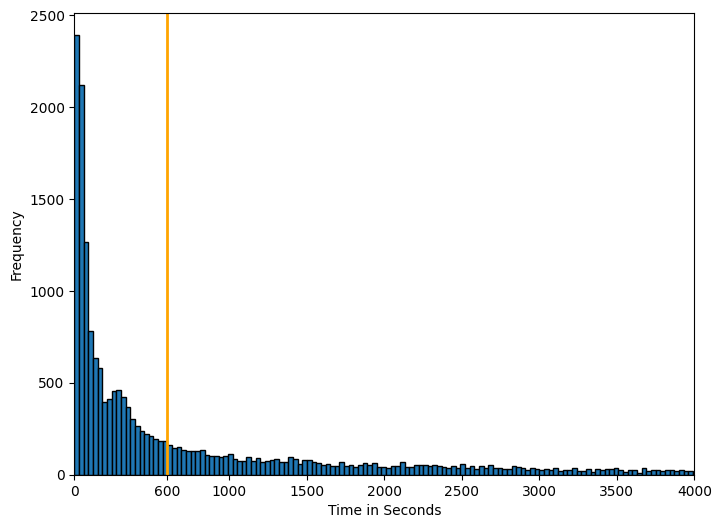

In [ ]:
dataset_bound_kernel_ids = set(
    src_kernel_version_id
    .dropna()
    .astype("int64")
    .unique()
    .tolist()
)

submission_dates = pd.to_datetime(
    submissions_df["SubmissionDate"],
    format="%m/%d/%Y",   # example: 05/12/2014
    errors="coerce"
)
cutoff = pd.Timestamp("2025-05-31")  # May 31, 2025

# Pre-normalize versions columns once for speed.
version_ids = pd.to_numeric(versions["Id"], errors="coerce")
version_runtime_seconds = pd.to_numeric(
    versions["RunningTimeInMilliseconds"], errors="coerce"
) / 1000
script_language_ids = pd.to_numeric(versions["ScriptLanguageId"], errors="coerce")

all_script = set()
times_in_seconds = []   

with open("./fetch/competitions.txt") as f:
    for line in f:
        collected_scriptIds = {}
        comptId = competitionByName(line.strip()).Id
        reported_submissions = competitions_df.loc[competitions_df["Id"] == comptId, "TotalSubmissions"].iloc[0]
        teamIds = teamByCompetitionId(comptId)
        matched_submissions = submissions_df.loc[submissions_df["TeamId"].isin(teamIds) & submission_dates.lt(cutoff)]

        has_score = submissionByKernelId(teamIds)
        sourceKernelIds = [
            sourceKernelId
            for sourceKernelId in has_score
            if sourceKernelId not in dataset_bound_kernel_ids
        ]

        kernelIds = (
            version_ids[
                version_ids.isin(sourceKernelIds)
                & script_language_ids.isin([2, 8, 9, 14])
            ]
            .dropna()
            .astype("int64")
            .unique()
            .tolist()
        )

        PythonKernelIds = [
            p
            for p in kernelIds
            if ftype(idToPath(p)) == ".ipynb"
            and chosen_submission_has_valid_private_score(p)
        ]

        all_script = all_script.union(set(PythonKernelIds))


for PythonKernelId in all_script:
    runtime = versions.loc[versions["Id"] == PythonKernelId, "RunningTimeInMilliseconds"].iloc[0] / 1000
    times_in_seconds.append(runtime)

bins = np.arange(0, max(times_in_seconds) + 30, 30)
# Plot 1: Histogram with linear bins.
plt.figure(figsize=(8, 6))
plt.hist(times_in_seconds, bins=bins, edgecolor='black')
plt.axvline(600, color="orange", linewidth=2)
plt.xlabel('Time in Seconds')
plt.ylabel('Frequency')
# plt.title('Distribution of Script Execution Times (Linear Scale)')
plt.xlim(0, 4000)
# ensure 600 is shown on x-axis and rotate labels
ax = plt.gca()
xticks = [t for t in ax.get_xticks() if t != 500]
if 600 not in xticks:
    xticks.append(600)
ax.set_xticks(sorted(set(xticks)))
# plt.xticks(rotation=30)
# plt.savefig("distribution_of_script_execution_time.png", dpi=800, bbox_inches="tight")
plt.show()


82it [03:03,  2.23s/it]


Total scripts with no external dataset used, valid scores, runtime <= 600s, and Script is a notebook: 12106
The oldest notebook can be traced back to 2016-09-13 01:09:07


/tmp/ipykernel_3814065/1608636633.py:93: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, counts.max() * 2.6)


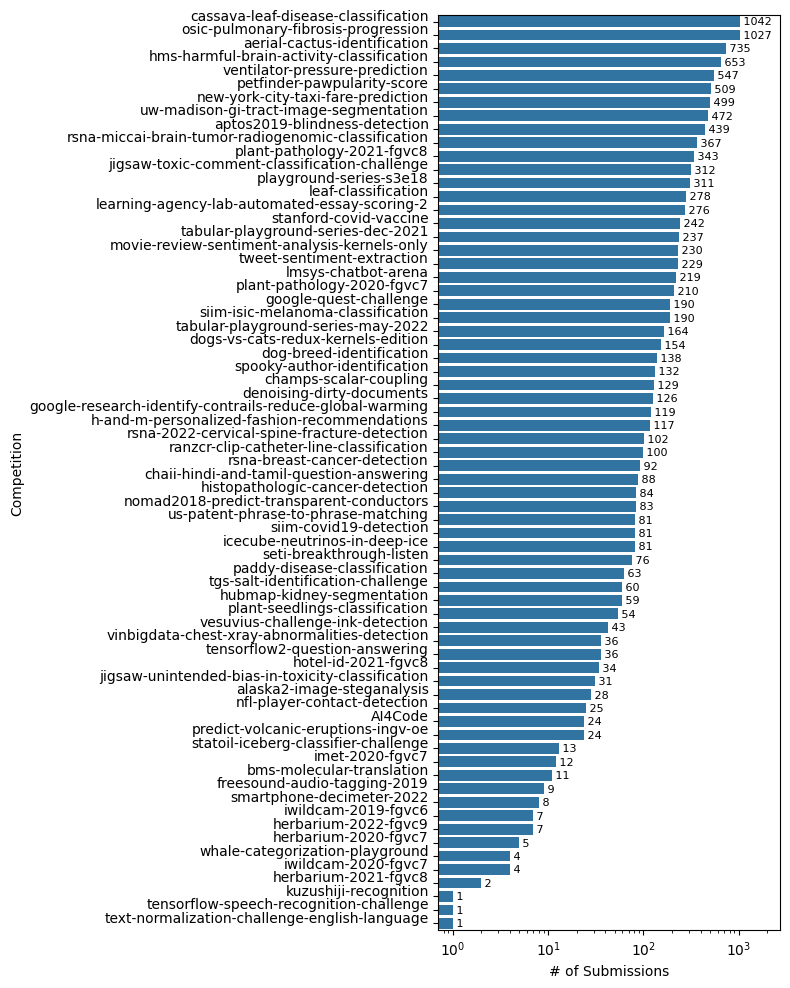

In [4]:
from tqdm import tqdm

dataset_bound_kernel_ids = set(
    src_kernel_version_id
    .dropna()
    .astype("int64")
    .unique()
    .tolist()
)

submission_dates = pd.to_datetime(
    submissions_df["SubmissionDate"],
    format="%m/%d/%Y",   # example: 05/12/2014
    errors="coerce"
)
cutoff = pd.Timestamp("2025-05-31")  # May 31, 2025

# Pre-normalize versions columns once for speed.
version_ids = pd.to_numeric(versions["Id"], errors="coerce")
version_runtime_seconds = pd.to_numeric(
    versions["RunningTimeInMilliseconds"], errors="coerce"
) / 1000
script_language_ids = pd.to_numeric(versions["ScriptLanguageId"], errors="coerce")

compt_stats = []
all_script = set()
with open("./fetch/competitions.txt") as f:
    for line in tqdm(f):
        collected_scriptIds = {} 
        comptId = competitionByName(line.strip()).Id
        reported_submissions = competitions_df.loc[competitions_df["Id"] == comptId, "TotalSubmissions"].iloc[0]
        teamIds = teamByCompetitionId(comptId)
        matched_submissions = submissions_df.loc[submissions_df["TeamId"].isin(teamIds) & submission_dates.lt(cutoff)]

        has_score = submissionByKernelId(teamIds)
        sourceKernelIds = [
            sourceKernelId
            for sourceKernelId in has_score
            if sourceKernelId not in dataset_bound_kernel_ids
        ]

        kernelIds = (
            version_ids[
                version_ids.isin(sourceKernelIds)
                & version_runtime_seconds.le(600)
                & script_language_ids.isin([2, 8, 9, 14])
            ]
            .dropna()
            .astype("int64")
            .unique()
            .tolist()
        )

        PythonKernelIds = [
            p
            for p in kernelIds
            if ftype(idToPath(p)) == ".ipynb"
            and chosen_submission_has_valid_private_score(p)
        ]

        all_script = all_script.union(set(PythonKernelIds))
        for _ in PythonKernelIds:
            compt_stats.append(line)

print(f"Total scripts with no external dataset used, valid scores, runtime <= 600s, and Script is a notebook: {len(all_script)}")
version_creation_dates = pd.to_datetime(versions["CreationDate"], errors="coerce")
oldest_date = version_creation_dates[version_ids.isin(all_script)].min()
# optional: which version is oldest
oldest_mask = version_ids.isin(all_script) & (version_creation_dates == oldest_date)
oldest_id = version_ids[oldest_mask].iloc[0]
print(f"The oldest notebook can be traced back to {oldest_date}")
            
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker

compt_stats = Counter(compt_stats)
categories = list(compt_stats.keys())
counts = np.array(list(compt_stats.values()), dtype=float)

# Sort by counts for better visualization
sorted_indices = np.argsort(counts)[::-1]
categories = [categories[i] for i in sorted_indices]
counts = counts[sorted_indices]

plt.figure(figsize=(8, 10))
ax = sns.barplot(x=counts, y=categories)  # barplot is the cleanest for dict {cat:count}
ax.set_ylabel("Competition")
ax.set_xlabel("# of Submissions")  # will SHOW counts via formatter below
ax.set_xscale("log")
ax.set_xlim(0, counts.max() * 2.6)

for i, v in enumerate(counts):
    ax.text(v, i, f" {int(v)}", va='center', fontsize=8)

plt.tight_layout()
# plt.savefig("competition_submission_distribution.png", dpi=600)
plt.show()


Tokenizing: 100%|██████████| 8638/8638 [05:40<00:00, 25.35it/s]


N=8638
90th percentile tokens: 8596
95th percentile tokens: 16337
99th percentile tokens: 33520
99.9th percentile tokens: 181774
x (p95) = 16337
y = P(X >= p95) = 0.050012  (~5.00%)
x (p99) = 33520
y = P(X >= p99) = 0.010072  (~1.01%)
x (p99.9) = 181774
y = P(X >= p99.9) = 0.001042  (~0.10%)
On-curve point (first xs >= p99): x=181817, y=0.001042


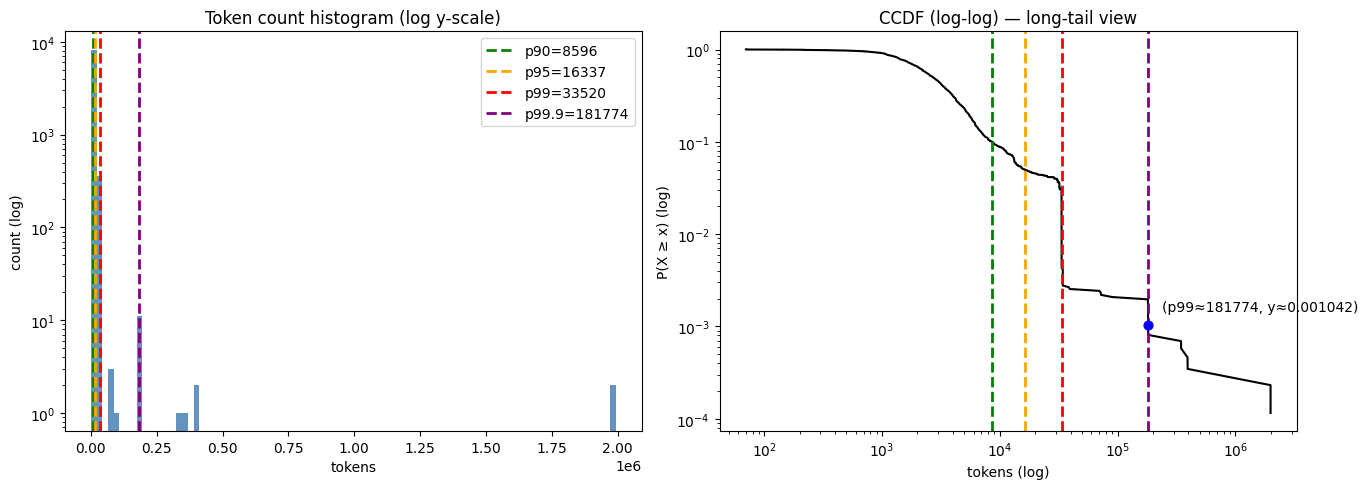

In [3]:
import glob
import json
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import tiktoken

ANSI_RE = re.compile(r"\x1b\[[0-9;]*m")

def _drop_hash_comment_lines(src: str) -> str:
    """
    Remove lines that are commented out, e.g. starting with '#'
    (also removes ones with leading whitespace before '#').
    Keeps inline comments like: x = 1  # keep
    """
    kept: list[str] = []
    in_triple = None  # None, "'''", or '"""'

    for line in src.splitlines(True):  # keep newlines
        # naive triple-quote toggle (won't handle all edge cases, but avoids the common ones)
        if in_triple is None:
            if "'''" in line or '"""' in line or '```' in line:
                # enter triple-quote mode if it starts an odd-count triple quote on this line
                if line.count("'''") % 2 == 1:
                    in_triple = "'''"
                elif line.count('"""') % 2 == 1:
                    in_triple = '"""'
        else:
            if line.count(in_triple) % 2 == 1:
                in_triple = None

        if in_triple is None and line.lstrip().startswith("#"):
            continue
        kept.append(line)

    return "".join(kept)

def get_script_contents(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        nb = json.load(f)

    code_blocks = []

    for i, cell in enumerate(nb.get('cells', [])):
        if cell.get('cell_type') != 'code':
            continue

        source = ''.join(cell.get('source', []))
        source = _drop_hash_comment_lines(source)
        if source.strip() == "":
            continue

        code_blocks.append(f"## === cell {i}\n{source}")

        for output in cell.get('outputs', []) or []:
            if output.get('output_type') == 'error':
                err_msg = "\n".join(output.get('traceback', []) or [])
                err_msg = ANSI_RE.sub("", err_msg)
                code_blocks.append(f"## --- ERROR in cell {i}, traceback:\n{err_msg}")
                break
    
    return "\n\n".join(code_blocks)

def _encode_piece(encoding, text: str) -> int:
    return len(encoding.encode(text))


def count_tokens_safe(encoding, text: str, max_line_chars: int = 8000, max_slice: int = 4000) -> int:
    total = 0
    for line in text.splitlines(keepends=True):
        if len(line) > max_line_chars:
            for i in range(0, len(line), max_slice):
                chunk = line[i : i + max_slice]
                total += _encode_piece(encoding, chunk)
            continue
        try:
            total += _encode_piece(encoding, line)
        except ValueError as e:
            if "Regex error" not in str(e) and "tokenizing" not in str(e).lower():
                raise
            for i in range(0, len(line), max_slice):
                chunk = line[i : i + max_slice]
                total += _encode_piece(encoding, chunk)
    return total

# threshold
# with error
baseline = {}
with open("./verification/baseline_non_reproducible.json", "r", encoding="utf-8") as f:
    data = json.load(f)
    baseline.update(data)

encoding = tiktoken.encoding_for_model("gpt-5")

script_tokens = []
for entity in tqdm(baseline.keys(), desc="Tokenizing"):
    script_in_prompt = get_script_contents(Path("./results/baseline/script_out_allINone") / entity)
    script_tokens.append(count_tokens_safe(encoding, script_in_prompt))

# script_tokens: list[int] (or np.ndarray) of token counts per notebook/script
arr = np.asarray(script_tokens, dtype=float)
arr = arr[np.isfinite(arr)]
arr = arr[arr >= 0]

if arr.size == 0:
    raise ValueError("script_tokens is empty after filtering.")

# p80 = float(np.percentile(arr, 80))
p90 = float(np.percentile(arr, 90))
p95 = float(np.percentile(arr, 95))
p99 = float(np.percentile(arr, 99))
p99_9 = float(np.percentile(arr, 99.9))

print(f"N={arr.size}")
# print(f"80th percentile tokens: {p80:.0f}")
print(f"90th percentile tokens: {p90:.0f}")
print(f"95th percentile tokens: {p95:.0f}")
print(f"99th percentile tokens: {p99:.0f}")
print(f"99.9th percentile tokens: {p99_9:.0f}")

# Long-tailed distribution plots
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# (1) Histogram with log-y to show long tail
bins = min(200, max(20, int(np.sqrt(arr.size))))
ax[0].hist(arr, bins=bins, color="steelblue", alpha=0.85)
ax[0].set_yscale("log")
# ax[0].axvline(p80, color="green", linestyle="--", linewidth=2, label=f"p80={p80:.0f}")
ax[0].axvline(p90, color="green", linestyle="--", linewidth=2, label=f"p90={p90:.0f}")
ax[0].axvline(p95, color="orange", linestyle="--", linewidth=2, label=f"p95={p95:.0f}")
ax[0].axvline(p99, color="red", linestyle="--", linewidth=2, label=f"p99={p99:.0f}")
ax[0].axvline(p99_9, color="purple", linestyle="--", linewidth=2, label=f"p99.9={p99_9:.0f}")
ax[0].set_title("Token count histogram (log y-scale)")
ax[0].set_xlabel("tokens")
ax[0].set_ylabel("count (log)")
ax[0].legend()

# (2) CCDF (survival function): P(X >= x) vs x, log-log looks straight-ish for heavy tails
xs = np.sort(arr)
ccdf = 1.0 - (np.arange(1, xs.size + 1) / xs.size)
ccdf = 1.0 - (np.arange(xs.size) / xs.size)
ccdf = np.maximum(ccdf, 1e-12)  # avoid log(0)

x_p95 = p95
y_p95 = float(np.mean(arr >= x_p95))
print(f"x (p95) = {x_p95:.0f}")
print(f"y = P(X >= p95) = {y_p95:.6f}  (~{y_p95*100:.2f}%)")

x_p99 = p99
y_p99 = float(np.mean(arr >= x_p99))
print(f"x (p99) = {x_p99:.0f}")
print(f"y = P(X >= p99) = {y_p99:.6f}  (~{y_p99*100:.2f}%)")

x_p99 = p99_9
y_p99 = float(np.mean(arr >= x_p99))
print(f"x (p99.9) = {x_p99:.0f}")
print(f"y = P(X >= p99.9) = {y_p99:.6f}  (~{y_p99*100:.2f}%)")

idx = int(np.searchsorted(xs, x_p99, side="left"))
idx = min(idx, len(xs) - 1)
x_on_curve = float(xs[idx])
y_on_curve = float(ccdf[idx])

print(f"On-curve point (first xs >= p99): x={x_on_curve:.0f}, y={y_on_curve:.6f}")

# Optional: mark it on the CCDF plot
ax[1].scatter([x_on_curve], [y_on_curve], color="blue", s=40, zorder=5)
ax[1].annotate(f"(p99≈{x_p99:.0f}, y≈{y_p99:.6f})",
               xy=(x_on_curve, y_on_curve),
               xytext=(10, 10),
               textcoords="offset points")
ax[1].plot(xs, ccdf, color="black", linewidth=1.5)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
# ax[1].axvline(p80, color="green", linestyle="--", linewidth=2)
ax[1].axvline(p90, color="green", linestyle="--", linewidth=2)
ax[1].axvline(p95, color="orange", linestyle="--", linewidth=2)
ax[1].axvline(p99, color="red", linestyle="--", linewidth=2)
ax[1].axvline(p99_9, color="purple", linestyle="--", linewidth=2)
ax[1].set_title("CCDF (log-log) — long-tail view")
ax[1].set_xlabel("tokens (log)")
ax[1].set_ylabel("P(X ≥ x) (log)")

plt.tight_layout()
plt.show()



















































































Summary:
Cases where rep_score != 0 but kaggle_score == 0: 0
Cases where rep_score == 0 but kaggle_score != 0: 82
Cases where rep_score == 0 and kaggle_score == 0: 0
6476 6476


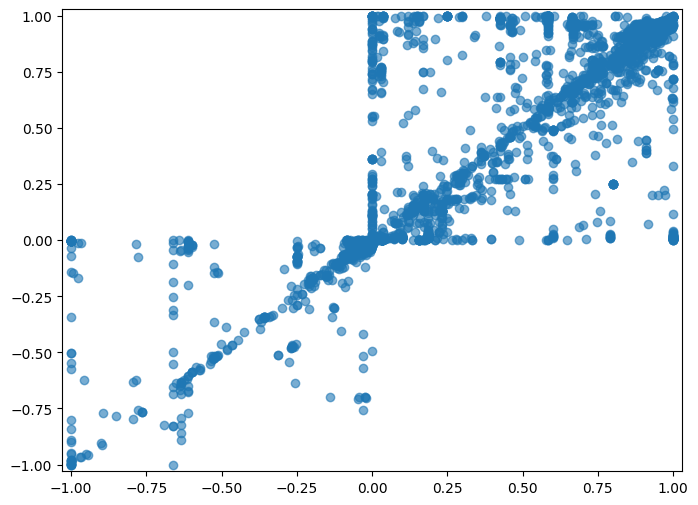

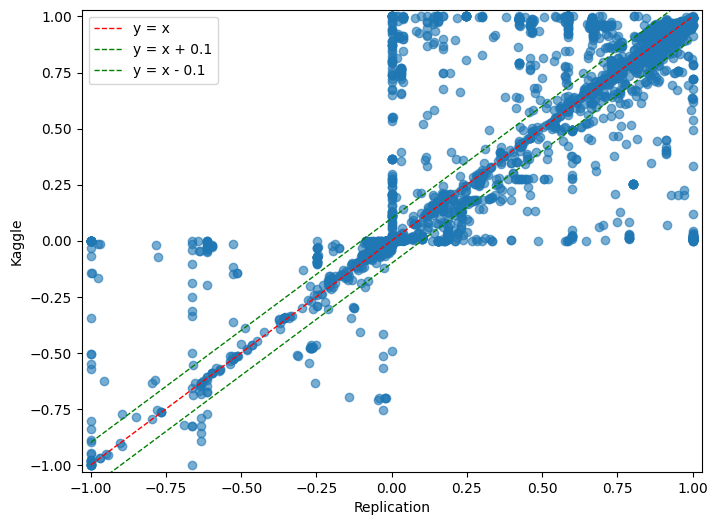

80th-percentile |y-x| threshold: 0.100256
Points inside band: 80.0%


In [ ]:
import json, os
import numpy as np
from collections import defaultdict
from tqdm import tqdm

json_path = "./results/baseline/csv_score.json"
with open(json_path, 'r') as f:
    compare = json.load(f)

with open("kernel.json", "r", encoding="utf-8") as f:
    data = json.load(f)

kaggle_zero_rep_nonzero = 0  # kaggle_score == 0 but rep_score != 0
rep_zero_kaggle_nonzero = []  # rep_score == 0 but kaggle_score != 0
rep_zero_kaggle_zero = 0  # rep_score == 0 but kaggle_score == 0
rep_nonzero_kaggle_zero = []  # rep_score != 0 but kaggle_score == 0


# Group data by competition first
comp_data = defaultdict(list)
for key, value in compare.items():
    compt = key.split("_")[0]
    name = key.split("_", 1)[1]
    
    if ("score" in value and 
        value["score"] and 
        "score" in value["score"] and
        compt in data and 
        name in data[compt] and 
        "ps" in data[compt][name]):

        rep_score = value["score"]["score"]
        kaggle_score = float(data[compt][name]["ps"])
        is_lower_better = value["score"]["is_lower_better"]

        if kaggle_score == 0.0:
            continue
        
        if rep_score is not None and kaggle_score is not None:
            
            # Count the specific zero/non-zero cases
            if kaggle_score == 0.0 and rep_score != 0.0:
                kaggle_zero_rep_nonzero += 1
                # print(f"Kaggle=0, Rep≠0: {name} (kaggle: {kaggle_score}, rep: {rep_score})")
            
            if rep_score == 0.0 and kaggle_score != 0.0:
                print()
                rep_zero_kaggle_nonzero.append(f"{compt}_{name}")
                # print(f"Rep=0, Kaggle≠0: {name} (rep: {rep_score}, kaggle: {kaggle_score})")
            
            if rep_score == 0.0 and kaggle_score == 0.0:
                rep_zero_kaggle_zero += 1

            if kaggle_score ==0 and rep_score >= 0.75:
                rep_nonzero_kaggle_zero.append(f"{compt}_{name}")

            comp_data[compt].append({
                'file' : name,
                'rep_score': float(rep_score),
                'kaggle_score': float(kaggle_score),
                'is_lower_better': is_lower_better,
                'key': key
            })

print(f"Summary:")
print(f"Cases where rep_score != 0 but kaggle_score == 0: {kaggle_zero_rep_nonzero}")
print(f"Cases where rep_score == 0 but kaggle_score != 0: {len(rep_zero_kaggle_nonzero)}")
print(f"Cases where rep_score == 0 and kaggle_score == 0: {rep_zero_kaggle_zero}")

# Process each competition group by Log transform + min-max
x, y = [], []
for compt, entries in comp_data.items():
    if len(entries) == 0:
        continue

    # if compt == "osic-pulmonary-fibrosis-progression":
    #     print("x=", [entry['rep_score'] for entry in entries])
    #     print("y=", [entry['kaggle_score'] for entry in entries])
    # else:
    #     continue
    # break

    # print("\n",compt)
    # Extract scores for this competition
    rep_scores = np.array([entry['rep_score'] for entry in entries])
    kaggle_scores = np.array([entry['kaggle_score'] for entry in entries])

    # print("Org - min rep:",min(rep_scores), "max rep:", max(rep_scores))
    # print("Org - min kaggle:",min(kaggle_scores), "max kaggle:", max(kaggle_scores))

    # Step 1: Log transform (using log1p for numeric stability)
    # Combine all scores to ensure consistent transformation
    all_scores = np.concatenate([rep_scores, kaggle_scores])
    all_scores_log = np.log1p(np.maximum(0, np.abs(all_scores))) # Ensure all positive
    
    # Split back into rep and kaggle
    n_rep = len(rep_scores)
    rep_scores_log = all_scores_log[:n_rep]
    kaggle_scores_log = all_scores_log[n_rep:]

    # print("Log1p - min rep:", min(rep_scores_log), "max rep:", max(rep_scores_log))
    # print("Log1p - min kaggle:", min(kaggle_scores_log), "max kaggle:", max(kaggle_scores_log))

    # Step 2: Linear normalization within competition
    # Normalize replication scores
    combined_min = min(all_scores_log)
    combined_max = max(all_scores_log)

    if combined_max > combined_min:
        rep_scores_norm = (rep_scores_log - combined_min) / (combined_max - combined_min)
        kaggle_scores_norm = (kaggle_scores_log - combined_min) / (combined_max - combined_min)
    else:
        # All values are the same - set to neutral midpoint
        # rep_scores_norm = np.full_like(rep_scores_log, 0.5)
        # kaggle_scores_norm = np.full_like(kaggle_scores_log, 0.5)
        rep_scores_norm = rep_scores_log
        kaggle_scores_norm = kaggle_scores_log

    # print("Norm - min rep:", min(rep_scores_norm), "max rep:", max(rep_scores_norm))
    # print("Norm - min kaggle:", min(kaggle_scores_norm), "max kaggle:", max(kaggle_scores_norm))


    # Step 3: Apply negation for "lower is better" competitions
    is_lower_better = entries[0]['is_lower_better']  # Same for all entries in competition

    if is_lower_better:
        rep_scores_final = -1 * rep_scores_norm
        kaggle_scores_final = -1 * kaggle_scores_norm
    else:
        rep_scores_final = rep_scores_norm
        kaggle_scores_final = kaggle_scores_norm
    
    # Add processed scores to final arrays
    x.extend(rep_scores_final)
    y.extend(kaggle_scores_final)

print(len(x), len(y))

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.6)

plt.xlim(-1.03, 1.03)
plt.ylim(-1.03, 1.03)
x_arr = np.array(x, dtype=float)
y_arr = np.array(y, dtype=float)

mask = np.isfinite(x_arr) & np.isfinite(y_arr)
x_clean = x_arr[mask]
y_clean = y_arr[mask]

diff = x_clean - y_clean
t80 = np.percentile(np.abs(diff), 80)  # threshold so 80% of |y-x| are inside

lims = [min(x_clean.min(), y_clean.min()), max(x_clean.max(), y_clean.max())]

plt.figure(figsize=(8,6))
plt.scatter(x_clean, y_clean, alpha=0.6)
plt.plot(lims, lims, 'r--', linewidth=1, label='y = x')
plt.plot(lims, [v + t80 for v in lims], 'g--', linewidth=1, label=f'y = x + {t80:.1f}')
plt.plot(lims, [v - t80 for v in lims], 'g--', linewidth=1, label=f'y = x - {t80:.1f}')
plt.xlim(-1.03, 1.03)
plt.ylim(-1.03, 1.03)
plt.xlabel("Replication")
plt.ylabel("Kaggle")
# plt.title("80% band around y = x")
plt.legend()
plt.show()

print(f"80th-percentile |y-x| threshold: {t80:.6f}")
print(f"Points inside band: {(np.abs(diff) <= t80).mean()*100:.1f}%")

# RQ1: result analysis
1. Checks the original csv_score.json result.
2. When it is failed, searches run_2 through run_10.
3. Opens each corresponding result.json.
4. Uses the first non-failed retry.
5. Locates the executed .ipynb from that retry directory.
6. Classifies it normally.
7. Keeps "Failed" only when every available retry is failed or unusable.

In [8]:
import json
import os
from pathlib import Path
from tqdm import tqdm
import plotly.graph_objects as go
import re

threshold = 10
# Load shared resources
with open("./upgrade/competition_score_rank.json", "r", encoding="utf-8") as f:
    lower_better = json.load(f)
with open("./kernel.json", "r") as f:
    kernel_content = json.load(f)

# Helper functions for classification
def get_score_map(score_content):
    # Returns a dict {filename: score}
    scores = {}
    for key, val in score_content.items():
        if "status" in val and "score" in val and "score" in val["score"]:
            sc = val["score"]["score"]
            if sc != "error":
                scores[key] = sc
    return scores


with open("./verification/baseline_non_reproducible.json") as f:
    baseline_non_reproducible = json.load(f)
with open("./verification/backporting_non_reproducible.json") as f:
    downgrade_non_reproducible = json.load(f)
with open("./verification/gpt_file_non_reproducible.json") as f:
    gpt_file_non_reproducible = json.load(f)
with open("./verification/oss_file_non_reproducible.json") as f:
    oss_file_non_reproducible = json.load(f)


def get_failure_reason(run_type, info):
    """Return one primary failure reason, or None if successful."""
    if not isinstance(info, dict):
        return "Failed"

    detail = info.get("detail", "") or ""
    error = info.get("error", "") or ""
    execution_time = info.get("execution_time", 0) or 0

    if run_type in UPGRADE_RUN_TYPES:
        if info.get("failed") == 1:
            return "LLM Failed"

        if execution_time > 600:
            return "Timeout"

        # Check this before "Not saving", since a disk-space failure may
        # also lack the NbConvert writing message.
        if "No space left on device" in error:
            return "Failed"

        if "[NbConvertApp] Writing " not in detail:
            return "Not saving Notebooks"

        return None

    if run_type == "Backporting":
        if execution_time > 600:
            return "Timeout"

        if "No space left on device" in error:
            return "Failed"

        if (
            "Backporting Failed. Aborting." in detail
            or "Environment processed." not in detail
        ):
            return "Backporting Failed"

        if "[NbConvertApp] Writing " not in detail:
            return "Not saving Notebooks"

        if info.get("failed") == 1:
            return "Failed"

        return None

    if execution_time > 600:
        return "Timeout"

    if "No space left on device" in error:
        return "Failed"

    if "[NbConvertApp] Writing " not in detail:
        return "Not saving Notebooks"

    if info.get("failed") == 1:
        return "Failed"

    return None

def is_failed_result(run_type, info):
    return get_failure_reason(run_type, info) is not None

def parse_entity_path_parts(entity):
    """
    Parse:
        competition_notebook_name_version_cell.ipynb

    Example:
        competition_author_notebook_v6_C1.ipynb

    Returns:
        competition = competition
        notebook_name = author_notebook
        version = v6
    """
    parts = Path(entity).stem.split("_")

    # Need at least:
    # competition, notebook_name, version, final suffix
    if len(parts) < 4:
        return None

    competition = parts[0]
    notebook_name = "_".join(parts[1:-2])
    version = parts[-2] if parts[-2] else None

    if not competition or not notebook_name or not version:
        return None

    return competition, notebook_name, version

def normalize_retry_result(payload, entity):
    """
    Support result.json files that are either:

        1. The result dictionary itself
        2. {entity: result_dictionary}
        3. {entity_stem: result_dictionary}
        4. {"result": result_dictionary}
    """
    if not isinstance(payload, dict):
        return {}

    entity_stem = Path(entity).stem

    if entity in payload and isinstance(payload[entity], dict):
        return payload[entity]

    if entity_stem in payload and isinstance(payload[entity_stem], dict):
        return payload[entity_stem]

    for wrapper_key in ("result", "info", "data"):
        wrapped = payload.get(wrapper_key)

        if isinstance(wrapped, dict):
            if entity in wrapped and isinstance(wrapped[entity], dict):
                return wrapped[entity]

            if (
                entity_stem in wrapped
                and isinstance(wrapped[entity_stem], dict)
            ):
                return wrapped[entity_stem]

            # The wrapped dictionary may itself be the result.
            if any(
                key in wrapped
                for key in (
                    "status",
                    "score",
                    "detail",
                    "execution_time",
                    "failed",
                    "error",
                )
            ):
                return wrapped

    return payload


def path_from_nbconvert_detail(detail, attempt_dir):
    """
    Try to extract the output notebook path from:

        [NbConvertApp] Writing ... to some/path.ipynb
    """
    if not isinstance(detail, str):
        return None

    match = re.search(
        r"\[NbConvertApp\]\s+Writing.*?\s+to\s+([^\n\r]+?\.ipynb)",
        detail,
    )

    if not match:
        return None

    raw_path = Path(match.group(1).strip().strip("'\""))

    candidates = []

    if raw_path.is_absolute():
        candidates.append(raw_path)
    else:
        candidates.extend(
            [
                raw_path,
                attempt_dir / raw_path,
                attempt_dir / raw_path.name,
            ]
        )

    for candidate in candidates:
        if candidate.exists() and candidate.is_file():
            return candidate

    return None


def resolve_retry_script_path(attempt_dir, entity, retry_info):
    """
    Locate the executed notebook for a successful retry.

    Priority:
        1. Explicit path fields in result.json
        2. Path extracted from NbConvert detail
        3. attempt_dir / entity
        4. Any matching notebook under attempt_dir
    """
    path_keys = (
        "script_path",
        "output_path",
        "output_notebook",
        "executed_notebook",
        "notebook_path",
        "result_path",
    )

    for key in path_keys:
        raw_value = retry_info.get(key)

        if not isinstance(raw_value, str) or not raw_value:
            continue

        raw_path = Path(raw_value)

        candidates = (
            [raw_path]
            if raw_path.is_absolute()
            else [
                raw_path,
                attempt_dir / raw_path,
                attempt_dir / raw_path.name,
            ]
        )

        for candidate in candidates:
            if (
                candidate.exists()
                and candidate.is_file()
                and candidate.suffix == ".ipynb"
            ):
                return candidate

    detail_path = path_from_nbconvert_detail(
        retry_info.get("detail", ""),
        attempt_dir,
    )

    if detail_path is not None:
        return detail_path

    direct_candidates = [
        attempt_dir / entity,
        attempt_dir / Path(entity).name,
    ]

    for candidate in direct_candidates:
        if candidate.exists() and candidate.is_file():
            return candidate

    # Prefer a notebook with the exact same filename.
    exact_matches = list(attempt_dir.rglob(Path(entity).name))

    if exact_matches:
        return exact_matches[0]

    # Last fallback: use a unique .ipynb file in the retry directory.
    notebook_candidates = list(attempt_dir.rglob("*.ipynb"))

    if len(notebook_candidates) == 1:
        return notebook_candidates[0]

    return None


def find_successful_retry(
    run_type,
    root_path,
    entity,
    start_run=2,
    end_run=10,
):
    """
    Search run_2 through run_10.

    Returns:
        retry:
            Successful retry information, or None.

        attempt_history:
            A list containing the outcome and failure reason of every
            retry result that was found.
    """
    parsed = parse_entity_path_parts(entity)

    if parsed is None:
        return None, [
            {
                "run": None,
                "reason": "Failed",
                "detail": "Could not parse entity path",
            }
        ]

    competition, notebook_name, version = parsed

    verification_name = VERIFICATION_DIRS[run_type]
    verification_root = Path("./verification") / verification_name

    attempt_history = []

    for run_index in range(start_run, end_run + 1):
        attempt_dir = (
            verification_root
            / f"run_{run_index}"
            / "script_out"
            / competition
            / notebook_name
            / version
        )

        result_path = attempt_dir / "result.json"

        if not result_path.exists():
            attempt_history.append(
                {
                    "run": run_index,
                    "status": "Missing",
                    "reason": "Result not found",
                    "result_path": str(result_path),
                }
            )
            continue

        try:
            payload = json.loads(
                result_path.read_text(encoding="utf-8")
            )
        except Exception as exc:
            attempt_history.append(
                {
                    "run": run_index,
                    "status": "Failed",
                    "reason": "Failed",
                    "detail": f"Unreadable result.json: {exc}",
                    "result_path": str(result_path),
                }
            )
            continue

        retry_info = normalize_retry_result(payload, entity)
        failure_reason = get_failure_reason(run_type, retry_info)

        if failure_reason is not None:
            attempt_history.append(
                {
                    "run": run_index,
                    "status": "Failed",
                    "reason": failure_reason,
                    "result_path": str(result_path),
                }
            )
            continue

        retry_script_path = resolve_retry_script_path(
            attempt_dir,
            entity,
            retry_info,
        )

        if retry_script_path is None:
            attempt_history.append(
                {
                    "run": run_index,
                    "status": "Failed",
                    "reason": "Not saving Notebooks",
                    "detail": "Successful result but output notebook not found",
                    "result_path": str(result_path),
                }
            )
            continue

        attempt_history.append(
            {
                "run": run_index,
                "status": "Successful",
                "reason": None,
                "result_path": str(result_path),
                "script_path": str(retry_script_path),
            }
        )

        return (
            {
                "run": run_index,
                "info": retry_info,
                "script_path": retry_script_path,
                "result_path": result_path,
            },
            attempt_history,
        )

    return None, attempt_history


def is_replicable(run_type, entity, measured_score):
    if run_type == "Baseline":
        return entity not in baseline_non_reproducible

    if run_type == "Backporting":
        return entity not in downgrade_non_reproducible

    if run_type == "Cell":
        if isinstance(measured_score, str):
            return False

        competition = entity.split("_")[0]
        submission_id = (
            "_".join(Path(entity).stem.split("_")[1:])
            + ".ipynb"
        )

        submission_info = (
            kernel_content
            .get(competition, {})
            .get(submission_id, {})
        )

        reported_score = submission_info.get("ps")

        try:
            reported_score = float(reported_score)
            measured_score = float(measured_score)
        except (TypeError, ValueError):
            return False

        if reported_score == 0.0:
            return False

        difference_percentage = (
            abs(measured_score - reported_score)
            / abs(reported_score)
            * 100
        )

        return difference_percentage <= float(threshold)

    if run_type == "GPT":
        return entity not in gpt_file_non_reproducible

    if run_type == "OSS":
        return entity not in oss_file_non_reproducible

    raise ValueError(f"Unknown run type: {run_type}")


def default_script_path(run_type, root_path, entity, info):
    """Resolve the ordinary non-retry executed notebook path."""
    scripts_dir = Path(root_path) / "script_out_allINone"

    if run_type == "Baseline" or run_type == "Backporting":
        return scripts_dir / entity

    fix = info.get("fix", 0)

    if fix > 0:
        return scripts_dir / f"fix_{fix}" / entity

    return Path("./results/baseline/script_out_allINone") / entity


def notebook_has_error(script_path):
    """
    Return:
        True  -> notebook contains an error output
        False -> notebook has no error output
        None  -> notebook could not be loaded
    """
    if not script_path.exists():
        print(f"Script NOT FOUND: {script_path}")
        return None

    try:
        notebook = json.loads(
            script_path.read_text(encoding="utf-8")
        )
    except Exception as exc:
        print(f"Failed to load {script_path}: {exc}")
        return None

    for cell in notebook.get("cells", []):
        if cell.get("cell_type") != "code":
            continue

        for output in cell.get("outputs", []):
            if output.get("output_type") == "error":
                return True

    return False

def extract_measured_score(info):
    """
    Extract a scalar score from one result object.

    Possible formats:
        {"score": {"score": 0.123}}
        {"score": {"error": "..."}}
        {"score": 0.123}
    """
    if not isinstance(info, dict):
        return None

    score_data = info.get("score")

    if isinstance(score_data, dict):
        if "error" in score_data:
            return "n/r"

        return score_data.get("score")

    return score_data

def categorize_notebooks(run_type, root_path):
    # Broad categories used by the existing Sankey.
    category_map = {} # {filename: category_index}
    # Detailed categories distinguishing whether CSV/status exists.
    detailed_category_map = {}
    score_path = f"{root_path}/csv_score.json"

    with open(score_path, 'r') as f:
        score_content = json.load(f)
    data = score_content

    scores_lut = get_score_map(score_content) if "upgrade" not in root_path else {}
    full_files = {f for f in os.listdir('./baseline/notebooks') if f.endswith('.ipynb')}

    failure_reason_map = {}
    retry_failure_history = {}
    recovered_retries = []
    permanently_failed = []
    unreadable_scripts = []

    for entity, original_info in tqdm(data.items()):
        if entity not in full_files:
            continue

        effective_info = original_info

        script_path = default_script_path(
            run_type,
            root_path,
            entity,
            original_info,
        )

        original_failure_reason = get_failure_reason(run_type, original_info)
        # Retry notebooks whose original execution failed.
        if original_failure_reason is not None:
            retry, attempt_history = find_successful_retry(
                run_type,
                root_path,
                entity,
                start_run=2,
                end_run=10,
            )

            retry_failure_history[entity] = {
                "original": {
                    "run": 1,
                    "status": "Failed",
                    "reason": original_failure_reason,
                },
                "retries": attempt_history,
            }

            if retry is None:
                category_map[entity] = "Failed"

                valid_failure_reasons = {
                    "Timeout",
                    "Not saving Notebooks",
                    "Backporting Failed",
                    "LLM Failed",
                    "Failed",
                }

                failed_retry_reasons = [
                    attempt.get("reason")
                    for attempt in attempt_history
                    if (
                        attempt.get("status") == "Failed"
                        and attempt.get("reason") in valid_failure_reasons
                    )
                ]

                # Use the latest actual retry failure reason.
                # If no retry result existed, retain the original-run reason.
                final_reason = (
                    failed_retry_reasons[-1]
                    if failed_retry_reasons
                    else original_failure_reason
                )

                if final_reason not in valid_failure_reasons:
                    final_reason = "Failed"

                detailed_category_map[entity] = final_reason
                failure_reason_map[entity] = final_reason
                permanently_failed.append(entity)
                continue

            effective_info = retry["info"]
            script_path = retry["script_path"]

            recovered_retries.append(
                {
                    "entity": entity,
                    "original_reason": original_failure_reason,
                    "recovered_run": retry["run"],
                    "script_path": str(script_path),
                }
            )

        has_error = notebook_has_error(script_path)

        if has_error is None:
            category_map[entity] = "Failed"
            detailed_category_map[entity] = "Failed"
            failure_reason_map[entity] = "Failed"
            unreadable_scripts.append(entity)
            continue

        # Use the successful retry result when available.
        measured_score = extract_measured_score(effective_info)

        if measured_score is None:
            if run_type == "Baseline":
                measured_score = scores_lut.get(entity)
            else:
                measured_score = extract_measured_score(
                    score_content.get(entity, {})
                )

        replicable = is_replicable(
            run_type,
            entity,
            measured_score,
        )

        # CSV/status availability:
        #
        # A retry may omit "status" even though the original csv_score.json
        # record contains it, so check both records.
        has_csv = (
            "status" in effective_info
            or "status" in original_info
        )

        if has_error:
            if replicable and has_csv:
                broad_category = "Error Reproducible"
                detailed_category = "Error Reproducible"

            elif has_csv:
                broad_category = "Error Non-reproducible"
                detailed_category = (
                    "Error Non-reproducible w/ CSV"
                )

            else:
                broad_category = "Error Non-reproducible"
                detailed_category = (
                    "Error Non-reproducible w/o CSV"
                )

        else:
            if replicable and has_csv:
                broad_category = "Error-free Reproducible"
                detailed_category = "Error-free Reproducible"

            elif has_csv:
                broad_category = "Error-free Non-reproducible"
                detailed_category = (
                    "Error-free Non-reproducible w/ CSV"
                )

            else:
                broad_category = "Error-free Non-reproducible"
                detailed_category = (
                    "Error-free Non-reproducible w/o CSV"
                )

        category_map[entity] = broad_category
        detailed_category_map[entity] = detailed_category


    return category_map, detailed_category_map

# Configuration
roots = {
    "Baseline": "./results/baseline",
    "Backporting": "./results/downgrade/baseline",
    "GPT": "./results/upgrade/gpt_file",
    "OSS": "./results/upgrade/oss_file",
    "Cell": "./results/upgrade/gpt_cell"
}
VERIFICATION_DIRS = {
    "Baseline": "baseline",
    "Backporting": "backporting",
    "GPT": "gpt_file",
    "OSS": "oss_file",
    "Cell": "gpt_cell",
}
UPGRADE_RUN_TYPES = {"GPT", "OSS", "Cell"}
# Run classification
print("Classifying Baseline...")
baseline_cats, baseline_detailed_cats = categorize_notebooks("Baseline",roots["Baseline"])
print("Classifying Backporting...")
backporting_cats, backporting_detailed_cats = categorize_notebooks("Backporting",roots["Backporting"])
print("Classifying GPT File-level Upgrade...")
gpt_file_cats, gpt_file_detailed_cats = categorize_notebooks("GPT",roots["GPT"])
print("Classifying OSS File-level Upgrade...")
oss_file_cats, oss_file_detailed_cats = categorize_notebooks("OSS",roots["OSS"])
print("Classifying Cell-level Upgrade...")
cell_cats, cell_detailed_cats = categorize_notebooks("Cell",roots["Cell"])


Classifying Baseline...


100%|██████████| 12106/12106 [00:21<00:00, 553.17it/s]


Classifying Backporting...


100%|██████████| 12106/12106 [00:17<00:00, 690.93it/s] 


Classifying GPT File-level Upgrade...


100%|██████████| 8210/8210 [00:09<00:00, 868.53it/s] 


Classifying OSS File-level Upgrade...


100%|██████████| 8210/8210 [00:08<00:00, 948.97it/s] 


Classifying Cell-level Upgrade...


100%|██████████| 2842/2842 [00:08<00:00, 348.02it/s]


In [ ]:
import pickle
# with open('cell_cats.pkl', 'wb') as file:
#     pickle.dump(cell_cats, file)
# with open('gpt_file_cats.pkl', 'wb') as file:
#     pickle.dump(gpt_file_cats, file)
# with open('oss_file_cats.pkl', 'wb') as file:
#     pickle.dump(oss_file_cats, file)
# with open('baseline_cats.pkl', 'wb') as file:
#     pickle.dump(baseline_cats, file)
# with open('backporting_cats.pkl', 'wb') as file:
#     pickle.dump(backporting_cats, file)

# with open('cell_detailed_cats.pkl', 'wb') as file:
#     pickle.dump(cell_detailed_cats, file)
# with open('gpt_file_detailed_cats.pkl', 'wb') as file:
#     pickle.dump(gpt_file_detailed_cats, file)
# with open('oss_file_detailed_cats.pkl', 'wb') as file:
#     pickle.dump(oss_file_detailed_cats, file)
# with open('baseline_detailed_cats.pkl', 'wb') as file:
#     pickle.dump(baseline_detailed_cats, file)
# with open('backporting_detailed_cats.pkl', 'wb') as file:
#     pickle.dump(backporting_detailed_cats, file)


with open('cell_cats.pkl', 'rb') as file:
    cell_cats = pickle.load(file)
with open('gpt_file_cats.pkl', 'rb') as file:
    gpt_file_cats = pickle.load(file)
with open('oss_file_cats.pkl', 'rb') as file:
    oss_file_cats = pickle.load(file)
with open('baseline_cats.pkl', 'rb') as file:
    baseline_cats = pickle.load(file)
with open('backporting_cats.pkl', 'rb') as file:
    backporting_cats = pickle.load(file)

with open('cell_detailed_cats.pkl', 'rb') as file:
    cell_detailed_cats = pickle.load(file)
with open('gpt_file_detailed_cats.pkl', 'rb') as file:
    gpt_file_detailed_cats = pickle.load(file)
with open('oss_file_detailed_cats.pkl', 'rb') as file:
    oss_file_detailed_cats = pickle.load(file)
with open('baseline_detailed_cats.pkl', 'rb') as file:
    baseline_detailed_cats = pickle.load(file)
with open('backporting_detailed_cats.pkl', 'rb') as file:
    backporting_detailed_cats = pickle.load(file)

In [47]:
from collections import Counter

category_order = [
    "Error-free Reproducible",
    "Error-free Non-reproducible",
    "Error-free Non-reproducible w/ CSV",
    "Error-free Non-reproducible w/o CSV",
    "Error Reproducible",
    "Error Non-reproducible",
    "Error Non-reproducible w/ CSV",
    "Error Non-reproducible w/o CSV",
    "Timeout",
    "Not saving Notebooks",
    "Backporting Failed",
    "LLM Failed",
    "Failed"
]


print("====Baseline====")
counts = Counter(baseline_detailed_cats.values())
for category in category_order:
    print(f"{category}: {counts[category]}") if counts[category] > 0 else None
print("\n")
counts = Counter(baseline_cats.values())
for category in category_order:
    print(f"{category}: {counts[category]}") if counts[category] > 0 else None
print("\n====Backporting====")
counts = Counter(backporting_detailed_cats.values())
for category in category_order:
    print(f"{category}: {counts[category]}") if counts[category] > 0 else None
print("\n")
counts = Counter(backporting_cats.values())
for category in category_order:
    print(f"{category}: {counts[category]}") if counts[category] > 0 else None
print("\n====GPT====")
counts = Counter(gpt_file_detailed_cats.values())
for category in category_order:
    print(f"{category}: {counts[category]}") if counts[category] > 0 else None
print("\n")
counts = Counter(gpt_file_cats.values())
for category in category_order:
    print(f"{category}: {counts[category]}") if counts[category] > 0 else None
print("\n====OSS====")
counts = Counter(oss_file_detailed_cats.values())
for category in category_order:
    print(f"{category}: {counts[category]}") if counts[category] > 0 else None
print("\n")
counts = Counter(oss_file_cats.values())
for category in category_order:
    print(f"{category}: {counts[category]}") if counts[category] > 0 else None
print("\n====Cell====")
counts = Counter(cell_detailed_cats.values())
for category in category_order:
    print(f"{category}: {counts[category]}") if counts[category] > 0 else None
print("\n")
counts = Counter(cell_cats.values())
for category in category_order:
    print(f"{category}: {counts[category]}") if counts[category] > 0 else None


====Baseline====
Error-free Reproducible: 1271
Error-free Non-reproducible w/ CSV: 580
Error-free Non-reproducible w/o CSV: 56
Error Reproducible: 1900
Error Non-reproducible w/ CSV: 1466
Error Non-reproducible w/o CSV: 6536
Timeout: 275
Not saving Notebooks: 22


Error-free Reproducible: 1271
Error-free Non-reproducible: 636
Error Reproducible: 1900
Error Non-reproducible: 8002
Failed: 297

====Backporting====
Error-free Reproducible: 972
Error-free Non-reproducible w/ CSV: 817
Error-free Non-reproducible w/o CSV: 62
Error Reproducible: 515
Error Non-reproducible w/ CSV: 1900
Error Non-reproducible w/o CSV: 7251
Timeout: 215
Not saving Notebooks: 9
Backporting Failed: 365


Error-free Reproducible: 972
Error-free Non-reproducible: 879
Error Reproducible: 515
Error Non-reproducible: 9151
Failed: 589

====GPT====
Error-free Reproducible: 2397
Error-free Non-reproducible w/ CSV: 2578
Error-free Non-reproducible w/o CSV: 1
Error Reproducible: 895
Error Non-reproducible w/ CSV: 633
Error N

# Motivation: Backporting

In [21]:
# Build Flow Data
labels = [
    "Error-free Reproducible", 
    "Error Reproducible", 
    "Error-free Non-reproducible", 
    "Error Non-reproducible", 
    "Failed"
]

# Fixed node positions (top -> bottom)
n = len(labels)
ys = [0.03, 0.18, 0.28, 0.66, 0.97]  # more separation between Error Reproducible and Error Non-reproducible
node_x = [0.02] * n + [0.99] * n
node_y = list(ys) + list(ys)

# Create source (0-4) and target (5-9) indices
label_to_node_src = {l: i for i, l in enumerate(labels)}
label_to_node_tgt = {l: i + len(labels) for i, l in enumerate(labels)}

# Color palette for links (optional)
colors = {
    "Error-free Reproducible": "rgba(44, 160, 44, 0.4)",      # Green
    "Error Reproducible": "rgba(31, 119, 180, 0.4)",          # Blue
    "Error-free Non-reproducible": "rgba(127, 127, 127, 0.4)", # Gray
    "Error Non-reproducible": "rgba(214, 39, 40, 0.4)",       # Red
    "Failed": "rgba(255, 127, 14, 0.4)"                    # Orange
}

# common files
common_files = set(baseline_cats.keys()) & set(backporting_cats.keys())
print(f"Plotting {len(common_files)} common files.")

# Count transitions
transitions = {}
src_node_totals = {l: 0 for l in labels}

for f in common_files:
    src = baseline_cats[f]
    tgt = backporting_cats[f] 
    key = (src, tgt)
    transitions[key] = transitions.get(key, 0) + 1
    src_node_totals[src] += 1

# Calculate counts per category for labelling
src_counts = {l: 0 for l in labels}
tgt_counts = {l: 0 for l in labels}

# Helper for calculation
source_indices = []
target_indices = []
values = []
link_colors = []
link_customdata = []
link_labels = []

draw_order = [
    "Error-free Reproducible", 
    "Error Reproducible", 
    "Error-free Non-reproducible", 
    "Error Non-reproducible", 
    "Failed"
]

# Build plot data
for (src_cat, tgt_cat), count in sorted(
    transitions.items(),
    key=lambda kv: (
        draw_order.index(kv[0][0]),
        label_to_node_tgt[kv[0][1]]
    )
):
    src_counts[src_cat] += count
    tgt_counts[tgt_cat] += count
    
    source_indices.append(label_to_node_src[src_cat])
    target_indices.append(label_to_node_tgt[tgt_cat])
    values.append(count)
    link_colors.append(colors[src_cat])
    
    # Calculate percentage relative to the SOURCE node total
    # e.g., 502 / 3007 if 3007 is the total for that source category
    total_in_src = src_node_totals[src_cat]
    pct = (count / total_in_src) * 100 if total_in_src > 0 else 0
    
    # Format: "502, 502/3007 (16.7%)"
    info_str = f"{count}, {pct:.1f}%"
    link_customdata.append(info_str)
    link_labels.append(info_str)

# Update labels with counts
src_labels = [f"{l} ({src_counts[l]})" for l in labels]
tgt_labels = [f"{l} ({tgt_counts[l]})" for l in labels]

# Build link annotations at the midpoint of each link
link_annotations = []
for i, (s, t) in enumerate(zip(source_indices, target_indices)):
    x_mid = (node_x[s] + node_x[t]) / 2
    y_mid = (node_y[s] + node_y[t]) / 2
    link_annotations.append(
        dict(
            x=x_mid,
            y=y_mid,
            xref="paper",
            yref="paper",
            text=link_labels[i],
            showarrow=False,
            font=dict(size=10, color="black"),
            bgcolor="rgba(255,255,255,0.6)",
        )
    )

# Plot
fig = go.Figure(data=[go.Sankey(
    arrangement="fixed",
    node = dict(
        pad = 26,
        thickness = 20,
        line = dict(color = "black", width = 0.5),
        label = src_labels + tgt_labels, # Label list repeats for left and right with counts
        color = ["green", "blue", "grey", "red", "orange"] * 2,
        x=node_x,
        y=node_y,
    ),
    link = dict(
        source = source_indices,
        target = target_indices,
        value = values,
        color = link_colors,
        # Plotly Sankey does not support static text on links, 
        # so we use hover labels to display the detailed stats.
        customdata = link_customdata,
        hovertemplate='From: %{source.label}<br>To: %{target.label}<br>Stats: %{customdata}<extra></extra>'
    ))])

fig.update_layout(
    # title_text="Notebook Status Flow", 
    font_size=10,
    annotations=[
        dict(
            x=0, y=-0.03,
            xref="paper", yref="paper",
            text="Baseline",
            showarrow=False,
            font=dict(size=14, color="black", weight="bold")
        ),
        dict(
            x=1, y=-0.03,
            xref="paper", yref="paper",
            text="Backporting",
            showarrow=False,
            font=dict(size=14, color="black", weight="bold")
        )
    ],
    margin=dict(b=60, t=40, l=10, r=10) # Add bottom margin for annotations
)
fig.write_image("sankey_downgrade_vs_baseline.png", scale=3)
fig.show()

Plotting 12106 common files.


# Upgrade

In [22]:
from collections import Counter
import json
import os
from pathlib import Path
from tqdm import tqdm
import plotly.graph_objects as go

with open("./verification/baseline_non_reproducible.json") as f:
    baselione_non_reproducible = json.load(f)
    
# Build Flow Data
labels = [
    "Error-free Reproducible", 
    "Error Reproducible", 
    "Error-free Non-reproducible", 
    "Error Non-reproducible", 
    "Failed"
]

NON_REPRO_BASELINE = ["Error-free Non-reproducible", "Error Non-reproducible"]
common_files = {k for k in baseline_cats if k in baselione_non_reproducible}
common_files = set(baseline_cats.keys()) & set(gpt_file_cats.keys())
print(f"Plotting {len(common_files)} common files.")
left_order = [l for l in labels if l in NON_REPRO_BASELINE]
right_order = labels[:]  # always show all 5 on Upgrade side

# Create node lists (left + right)
node_labels = left_order + right_order
n_left = len(left_order)
n_right = len(right_order)

# Fixed node positions
def _spread(n, top=0.05, bottom=0.95):
    if n <= 1:
        return [(top + bottom) / 2]
    step = (bottom - top) / (n - 1)
    return [top + i * step for i in range(n)]

node_x = [0.02] * n_left + [0.98] * n_right
# node_y = _spread(n_left, top=0.15, bottom=0.55) + _spread(n_right, top=0.05, bottom=0.95)
# Keep left spacing as-is; tighten lower right gaps
right_y = [0.03, 0.27, 0.45, 0.61, 0.75]  # tighter gaps for lower nodes
node_y = _spread(n_left, top=0.15, bottom=0.55) + right_y


# Create source (0-4) and target (5-9) indices
label_to_node_src = {l: i for i, l in enumerate(left_order)}
label_to_node_tgt = {l: i + n_left for i, l in enumerate(right_order)}

# Color palette for links (optional)
colors = {
    "Error-free Reproducible": "rgba(44, 160, 44, 0.4)",      # Green
    "Error-free Non-reproducible": "rgba(127, 127, 127, 0.4)", # Gray
    "Error Reproducible": "rgba(31, 119, 180, 0.4)",          # Blue
    "Error Non-reproducible": "rgba(214, 39, 40, 0.4)",       # Red
    "Failed": "rgba(255, 127, 14, 0.4)"                    # Orange
}

# common files
# common_files = set(baseline_cats.keys()) & set(gpt_file_cats.keys())
# print(f"Plotting {len(common_files)} common files.")

# Count transitions
transitions = {}
src_node_totals = {l: 0 for l in left_order}

for f in common_files:
    src = baseline_cats[f]
    tgt = gpt_file_cats[f] 
    if src not in label_to_node_src or tgt not in label_to_node_tgt:
        continue
    key = (src, tgt)
    transitions[key] = transitions.get(key, 0) + 1
    src_node_totals[src] += 1

# Calculate counts per category for labelling
src_counts = {l: 0 for l in left_order}
tgt_counts = {l: 0 for l in right_order}

# Helper for calculation
source_indices = []
target_indices = []
values = []
link_colors = []
link_customdata = []
link_labels = []

draw_order = [
    "Error-free Reproducible",
    "Error Reproducible",      # draw blue later (on top)
    "Error-free Non-reproducible",
    "Error Non-reproducible",  # draw red earlier
    "Failed",
]

# Build plot data
for (src_cat, tgt_cat), count in sorted(
    transitions.items(),
    key=lambda kv: (
        draw_order.index(kv[0][0]), # Sort by Source (Layering)
        draw_order.index(kv[0][1]) # Sort by Target (uncrossing)
    )
):
    src_counts[src_cat] += count
    tgt_counts[tgt_cat] += count
    
    source_indices.append(label_to_node_src[src_cat])
    target_indices.append(label_to_node_tgt[tgt_cat])
    values.append(count)
    link_colors.append(colors[src_cat])
    
    # Calculate percentage relative to the SOURCE node total
    # e.g., 502 / 3007 if 3007 is the total for that source category
    total_in_src = src_node_totals[src_cat]
    pct = (count / total_in_src) * 100 if total_in_src > 0 else 0
    
    # Format: "502, 502/3007 (16.7%)"
    info_str = f"{count}, {pct:.1f}%"
    link_customdata.append(info_str)
    link_labels.append(info_str)

# Update labels with counts
global_baseline = Counter(baseline_cats.values())
src_labels = [f"{l} ({global_baseline[l]})" for l in left_order]
global_baseline = Counter(gpt_file_cats.values())
tgt_labels = [f"{l} ({global_baseline[l]})" for l in right_order]

# Build link annotations at the midpoint of each link
link_annotations = []
for i, (s, t) in enumerate(zip(source_indices, target_indices)):
    x_mid = (node_x[s] + node_x[t]) / 2
    y_mid = (node_y[s] + node_y[t]) / 2
    link_annotations.append(
        dict(
            x=x_mid,
            y=y_mid,
            xref="paper",
            yref="paper",
            text=link_labels[i],
            showarrow=False,
            font=dict(size=10, color="black"),
            bgcolor="rgba(255,255,255,0.6)",
        )
    )

# Plot
fig = go.Figure(data=[go.Sankey(
    arrangement="fixed",
    node = dict(
        pad = 40,
        thickness = 20,
        line = dict(color = "black", width = 0.5),
        label = src_labels + tgt_labels, # Label list repeats for left and right with counts
        color = [colors[l].replace("0.4", "1.0") for l in left_order + right_order],
        x=node_x,
        y=node_y,
    ),
    link = dict(
        source = source_indices,
        target = target_indices,
        value = values,
        color = link_colors,
        # Plotly Sankey does not support static text on links, 
        # so we use hover labels to display the detailed stats.
        customdata = link_customdata,
        hovertemplate='From: %{source.label}<br>To: %{target.label}<br>Stats: %{customdata}<extra></extra>'
    ))])

fig.update_layout(
    # title_text="Notebook Status Flow", 
    font_size=10,
    annotations=[
        dict(
            x=0, y=0.12,
            xref="paper", yref="paper",
            text="Baseline",
            showarrow=False,
            font=dict(size=14, color="black", weight="bold")
        ),
        dict(
            x=1, y=0.12,
            xref="paper", yref="paper",
            text="Upgrade File",
            showarrow=False,
            font=dict(size=14, color="black", weight="bold")
        )
    ],
    margin=dict(b=20, t=60, l=10, r=10) # Add bottom margin for annotations
)
fig.write_image("sankey_baseline_vs_f-upgrade.png", scale=3)
fig.show()


Plotting 8210 common files.


In [23]:
from collections import Counter
# Build Flow Data
labels = [
    "Error-free Reproducible", 
    "Error Reproducible", 
    "Error-free Non-reproducible", 
    "Error Non-reproducible", 
    "Failed"
]

NON_REPRO_BASELINE = ["Error-free Non-reproducible", "Error Non-reproducible"]
common_files = {k for k in baseline_cats if k in baselione_non_reproducible}
common_files = set(baseline_cats.keys()) & set(oss_file_cats.keys())
print(f"Plotting {len(common_files)} common files.")
left_order = [l for l in labels if l in NON_REPRO_BASELINE]
right_order = labels[:]  # always show all 5 on Upgrade side

# Create node lists (left + right)
node_labels = left_order + right_order
n_left = len(left_order)
n_right = len(right_order)

# Fixed node positions
def _spread(n, top=0.05, bottom=0.95):
    if n <= 1:
        return [(top + bottom) / 2]
    step = (bottom - top) / (n - 1)
    return [top + i * step for i in range(n)]

node_x = [0.02] * n_left + [0.98] * n_right
# node_y = _spread(n_left, top=0.15, bottom=0.55) + _spread(n_right, top=0.05, bottom=0.95)
# Keep left spacing as-is; tighten lower right gaps
right_y = [0.03, 0.27, 0.45, 0.61, 0.75]  # tighter gaps for lower nodes
node_y = _spread(n_left, top=0.15, bottom=0.55) + right_y


# Create source (0-4) and target (5-9) indices
label_to_node_src = {l: i for i, l in enumerate(left_order)}
label_to_node_tgt = {l: i + n_left for i, l in enumerate(right_order)}

# Color palette for links (optional)
colors = {
    "Error-free Reproducible": "rgba(44, 160, 44, 0.4)",      # Green
    "Error-free Non-reproducible": "rgba(127, 127, 127, 0.4)", # Gray
    "Error Reproducible": "rgba(31, 119, 180, 0.4)",          # Blue
    "Error Non-reproducible": "rgba(214, 39, 40, 0.4)",       # Red
    "Failed": "rgba(255, 127, 14, 0.4)"                    # Orange
}

# common files
# common_files = set(baseline_cats.keys()) & set(gpt_file_cats.keys())
# print(f"Plotting {len(common_files)} common files.")

# Count transitions
transitions = {}
src_node_totals = {l: 0 for l in left_order}

for f in common_files:
    src = baseline_cats[f]
    tgt = oss_file_cats[f] 
    if src not in label_to_node_src or tgt not in label_to_node_tgt:
        continue
    key = (src, tgt)
    transitions[key] = transitions.get(key, 0) + 1
    src_node_totals[src] += 1

# Calculate counts per category for labelling
src_counts = {l: 0 for l in left_order}
tgt_counts = {l: 0 for l in right_order}

# Helper for calculation
source_indices = []
target_indices = []
values = []
link_colors = []
link_customdata = []
link_labels = []

draw_order = [
    "Error-free Reproducible",
    "Error Reproducible",      # draw blue later (on top)
    "Error-free Non-reproducible",
    "Error Non-reproducible",  # draw red earlier
    "Failed",
]

# Build plot data
for (src_cat, tgt_cat), count in sorted(
    transitions.items(),
    key=lambda kv: (
        draw_order.index(kv[0][0]), # Sort by Source (Layering)
        draw_order.index(kv[0][1]) # Sort by Target (uncrossing)
    )
):
    src_counts[src_cat] += count
    tgt_counts[tgt_cat] += count
    
    source_indices.append(label_to_node_src[src_cat])
    target_indices.append(label_to_node_tgt[tgt_cat])
    values.append(count)
    link_colors.append(colors[src_cat])
    
    # Calculate percentage relative to the SOURCE node total
    # e.g., 502 / 3007 if 3007 is the total for that source category
    total_in_src = src_node_totals[src_cat]
    pct = (count / total_in_src) * 100 if total_in_src > 0 else 0
    
    # Format: "502, 502/3007 (16.7%)"
    info_str = f"{count}, {pct:.1f}%"
    link_customdata.append(info_str)
    link_labels.append(info_str)

# Update labels with counts
global_baseline = Counter(baseline_cats.values())
src_labels = [f"{l} ({global_baseline[l]})" for l in left_order]
global_baseline = Counter(oss_file_cats.values())
tgt_labels = [f"{l} ({global_baseline[l]})" for l in right_order]

# Build link annotations at the midpoint of each link
link_annotations = []
for i, (s, t) in enumerate(zip(source_indices, target_indices)):
    x_mid = (node_x[s] + node_x[t]) / 2
    y_mid = (node_y[s] + node_y[t]) / 2
    link_annotations.append(
        dict(
            x=x_mid,
            y=y_mid,
            xref="paper",
            yref="paper",
            text=link_labels[i],
            showarrow=False,
            font=dict(size=10, color="black"),
            bgcolor="rgba(255,255,255,0.6)",
        )
    )

# Plot
fig = go.Figure(data=[go.Sankey(
    arrangement="fixed",
    node = dict(
        pad = 40,
        thickness = 20,
        line = dict(color = "black", width = 0.5),
        label = src_labels + tgt_labels, # Label list repeats for left and right with counts
        color = [colors[l].replace("0.4", "1.0") for l in left_order + right_order],
        x=node_x,
        y=node_y,
    ),
    link = dict(
        source = source_indices,
        target = target_indices,
        value = values,
        color = link_colors,
        # Plotly Sankey does not support static text on links, 
        # so we use hover labels to display the detailed stats.
        customdata = link_customdata,
        hovertemplate='From: %{source.label}<br>To: %{target.label}<br>Stats: %{customdata}<extra></extra>'
    ))])

fig.update_layout(
    # title_text="Notebook Status Flow", 
    font_size=10,
    annotations=[
        dict(
            x=0, y=0.12,
            xref="paper", yref="paper",
            text="Baseline",
            showarrow=False,
            font=dict(size=14, color="black", weight="bold")
        ),
        dict(
            x=1, y=0.12,
            xref="paper", yref="paper",
            text="Upgrade File",
            showarrow=False,
            font=dict(size=14, color="black", weight="bold")
        )
    ],
    margin=dict(b=20, t=60, l=10, r=10) # Add bottom margin for annotations
)
fig.write_image("sankey_baseline_vs_f_oss-upgrade.png", scale=3)
fig.show()


Plotting 8210 common files.


In [30]:
from collections import Counter
import plotly.graph_objects as go

# Merged Sankey: GPT File (left) | Baseline (center) | OSS File (right)
# Links are drawn GPT -> Baseline -> OSS so Plotly stays left-to-right
# (avoids reverse-flow layout collapse + double-sized center nodes).
labels = [
    "Error-free Reproducible",
    "Error Reproducible",
    "Error-free Non-reproducible",
    "Error Non-reproducible",
    "Failed",
]
# Large baseline band first so center mass aligns with top green upgrade nodes.
NON_REPRO_BASELINE = ["Error Non-reproducible", "Error-free Non-reproducible"]
upgrade_order = labels[:]
baseline_order = list(NON_REPRO_BASELINE)

colors = {
    "Error-free Reproducible": "rgba(44, 160, 44, 0.4)",
    "Error-free Non-reproducible": "rgba(127, 127, 127, 0.4)",
    "Error Reproducible": "rgba(31, 119, 180, 0.4)",
    "Error Non-reproducible": "rgba(214, 39, 40, 0.4)",
    "Failed": "rgba(255, 127, 14, 0.4)",
}
draw_order = [
    "Error Non-reproducible",
    "Error-free Non-reproducible",
    "Error-free Reproducible",
    "Error Reproducible",
    "Failed",
]

# Plotly calculates node height from link values. Reduce only the visual
# weight of this dominant baseline category; labels/hover retain true counts.
BASELINE_VISUAL_SCALE = {
    "Error Non-reproducible": 0.30,
    "Error-free Non-reproducible": 0.40,
}

n_gpt = len(upgrade_order)
n_base = len(baseline_order)
n_oss = len(upgrade_order)

label_to_gpt = {l: i for i, l in enumerate(upgrade_order)}
label_to_base = {l: i + n_gpt for i, l in enumerate(baseline_order)}
label_to_oss = {l: i + n_gpt + n_base for i, l in enumerate(upgrade_order)}

common_files = (
    set(baseline_cats.keys())
    & set(gpt_file_cats.keys())
    & set(oss_file_cats.keys())
)
plot_files = [f for f in common_files if baseline_cats[f] in label_to_base]
print(f"Plotting {len(plot_files)} non-repro baseline files (3-way).")

transitions_gpt = {}
transitions_oss = {}
base_totals = {l: 0 for l in baseline_order}

for f in plot_files:
    base = baseline_cats[f]
    gpt = gpt_file_cats[f]
    oss = oss_file_cats[f]
    base_totals[base] += 1
    if gpt in label_to_gpt:
        key = (base, gpt)
        transitions_gpt[key] = transitions_gpt.get(key, 0) + 1
    if oss in label_to_oss:
        key = (base, oss)
        transitions_oss[key] = transitions_oss.get(key, 0) + 1


def _stack_by_counts(order, counts, margin=0.02, usable=0.96):
    """Stack nodes top-to-bottom with heights proportional to counts."""
    total = sum(counts[l] for l in order) or 1
    ys, cursor = [], margin
    for l in order:
        h = counts[l] / total * usable
        ys.append(cursor + h / 2)
        cursor += h
    return ys


# Counts represented by the Sankey links
gpt_counts_plot = Counter(gpt_file_cats[f] for f in plot_files)
base_counts_plot = Counter(baseline_cats[f] for f in plot_files)
oss_counts_plot = Counter(oss_file_cats[f] for f in plot_files)

gpt_y = _stack_by_counts(upgrade_order, gpt_counts_plot)
base_y = _stack_by_counts(baseline_order, base_counts_plot)
oss_y = _stack_by_counts(upgrade_order, oss_counts_plot)

node_x = [0.01] * n_gpt + [0.50] * n_base + [0.99] * n_oss
node_y = gpt_y + base_y + oss_y

source_indices, target_indices, values = [], [], []
link_colors, link_customdata = [], []

# Left links: GPT -> Baseline (LTR wiring). Hover still reads Baseline -> GPT.
for (base_cat, gpt_cat), count in sorted(
    transitions_gpt.items(),
    key=lambda kv: (draw_order.index(kv[0][0]), draw_order.index(kv[0][1])),
):
    total_in_src = base_totals[base_cat]
    pct = (count / total_in_src) * 100 if total_in_src else 0
    source_indices.append(label_to_gpt[gpt_cat])
    target_indices.append(label_to_base[base_cat])
    values.append(count * BASELINE_VISUAL_SCALE[base_cat])
    link_colors.append(colors[base_cat])
    link_customdata.append(
        f"From: {base_cat}<br>To: {gpt_cat}<br>Stats: {count}, {pct:.1f}%"
    )

# Right links: Baseline -> OSS
for (base_cat, oss_cat), count in sorted(
    transitions_oss.items(),
    key=lambda kv: (draw_order.index(kv[0][0]), draw_order.index(kv[0][1])),
):
    total_in_src = base_totals[base_cat]
    pct = (count / total_in_src) * 100 if total_in_src else 0
    source_indices.append(label_to_base[base_cat])
    target_indices.append(label_to_oss[oss_cat])
    values.append(count * BASELINE_VISUAL_SCALE[base_cat])
    link_colors.append(colors[base_cat])
    link_customdata.append(
        f"From: {base_cat}<br>To: {oss_cat}<br>Stats: {count}, {pct:.1f}%"
    )

gpt_labels = [f"{l} ({gpt_counts_plot[l]})" for l in upgrade_order]
base_labels = [f"{l} ({base_counts_plot[l]})" for l in baseline_order]
oss_labels = [f"{l} ({oss_counts_plot[l]})" for l in upgrade_order]

fig = go.Figure(data=[go.Sankey(
    arrangement="fixed",
    node=dict(
        pad=16,
        thickness=18,
        line=dict(color="black", width=0.5),
        label=gpt_labels + base_labels + oss_labels,
        color=[colors[l].replace("0.4", "1.0") for l in upgrade_order + baseline_order + upgrade_order],
        x=node_x,
        y=node_y,
    ),
    link=dict(
        source=source_indices,
        target=target_indices,
        value=values,
        color=link_colors,
        customdata=link_customdata,
        hovertemplate="%{customdata}<extra></extra>",
    ),
)])

fig.update_layout(
    font_size=9,
    width=1400,
    height=900,
    annotations=[
        dict(x=0.02, y=1.001, xref="paper", yref="paper", text="GPT File Upgrade",
             showarrow=False, font=dict(size=14, color="black"), xanchor="left"),
        dict(x=0.50, y=1.001, xref="paper", yref="paper", text="Baseline",
             showarrow=False, font=dict(size=14, color="black", weight="bold"), xanchor="center"),
        dict(x=0.98, y=1.001, xref="paper", yref="paper", text="OSS File Upgrade",
             showarrow=False, font=dict(size=14, color="black"), xanchor="right"),
    ],
    margin=dict(b=40, t=110, l=10, r=10),
)
fig.write_image("sankey_baseline_center_f_vs_f_oss_upgrade.png", scale=3)
fig.show()


Plotting 8210 non-repro baseline files (3-way).


In [43]:
from collections import Counter
import json
# Build Flow Data
with open("./verification/baseline_non_reproducible.json") as f:
    baselione_non_reproducible = json.load(f)

labels = [
    "Error-free Reproducible", 
    "Error Reproducible", 
    "Error-free Non-reproducible", 
    "Error Non-reproducible", 
    "Failed"
]

NON_REPRO_BASELINE = ["Error Non-reproducible"]
common_files = {k for k in baseline_cats if k in baselione_non_reproducible}
common_files = set(baseline_cats.keys()) & set(cell_cats.keys())
print(f"Plotting {len(common_files)} common files.")
left_order = [l for l in labels if l in NON_REPRO_BASELINE]
right_order = labels[:]  # always show all 5 on Upgrade side

# Create node lists (left + right)
node_labels = left_order + right_order
n_left = len(left_order)
n_right = len(right_order)

# Fixed node positions
def _spread(n, top=0.05, bottom=0.95):
    if n <= 1:
        return [(top + bottom) / 2]
    step = (bottom - top) / (n - 1)
    return [top + i * step for i in range(n)]

node_x = [0.02] * n_left + [0.98] * n_right
# node_y = _spread(n_left, top=0.15, bottom=0.55) + _spread(n_right, top=0.05, bottom=0.95)
# Keep left spacing as-is; tighten lower right gaps
right_y = [0.03, 0.27, 0.45, 0.61, 0.75]  # tighter gaps for lower nodes
node_y = _spread(n_left, top=0.15, bottom=0.55) + right_y


# Create source (0-4) and target (5-9) indices
label_to_node_src = {l: i for i, l in enumerate(left_order)}
label_to_node_tgt = {l: i + n_left for i, l in enumerate(right_order)}

# Color palette for links (optional)
colors = {
    "Error-free Reproducible": "rgba(44, 160, 44, 0.4)",      # Green
    "Error-free Non-reproducible": "rgba(127, 127, 127, 0.4)", # Gray
    "Error Reproducible": "rgba(31, 119, 180, 0.4)",          # Blue
    "Error Non-reproducible": "rgba(214, 39, 40, 0.4)",       # Red
    "Failed": "rgba(255, 127, 14, 0.4)"                    # Orange
}

# common files
# common_files = set(baseline_cats.keys()) & set(gpt_file_cats.keys())
# print(f"Plotting {len(common_files)} common files.")

# Count transitions
transitions = {}
src_node_totals = {l: 0 for l in left_order}

for f in common_files:
    src = baseline_cats[f]
    tgt = cell_cats[f] 
    if src not in label_to_node_src or tgt not in label_to_node_tgt:
        continue
    key = (src, tgt)
    transitions[key] = transitions.get(key, 0) + 1
    src_node_totals[src] += 1

# Calculate counts per category for labelling
src_counts = {l: 0 for l in left_order}
tgt_counts = {l: 0 for l in right_order}

# Helper for calculation
source_indices = []
target_indices = []
values = []
link_colors = []
link_customdata = []
link_labels = []

draw_order = [
    "Error-free Reproducible",
    "Error Reproducible",      # draw blue later (on top)
    "Error-free Non-reproducible",
    "Error Non-reproducible",  # draw red earlier
    "Failed",
]

# Build plot data
for (src_cat, tgt_cat), count in sorted(
    transitions.items(),
    key=lambda kv: (
        draw_order.index(kv[0][0]), # Sort by Source (Layering)
        draw_order.index(kv[0][1]) # Sort by Target (uncrossing)
    )
):
    src_counts[src_cat] += count
    tgt_counts[tgt_cat] += count
    
    source_indices.append(label_to_node_src[src_cat])
    target_indices.append(label_to_node_tgt[tgt_cat])
    values.append(count)
    link_colors.append(colors[src_cat])
    
    # Calculate percentage relative to the SOURCE node total
    # e.g., 502 / 3007 if 3007 is the total for that source category
    total_in_src = src_node_totals[src_cat]
    pct = (count / total_in_src) * 100 if total_in_src > 0 else 0
    
    # Format: "502, 502/3007 (16.7%)"
    info_str = f"{count}, {pct:.1f}%"
    link_customdata.append(info_str)
    link_labels.append(info_str)

# Update labels with counts
src_labels = [f"{l} ({src_counts[l]})" for l in NON_REPRO_BASELINE]
global_baseline = Counter(cell_cats.values())
tgt_labels = [f"{l} ({global_baseline[l]})" for l in right_order]

# Build link annotations at the midpoint of each link
link_annotations = []
for i, (s, t) in enumerate(zip(source_indices, target_indices)):
    x_mid = (node_x[s] + node_x[t]) / 2
    y_mid = (node_y[s] + node_y[t]) / 2
    link_annotations.append(
        dict(
            x=x_mid,
            y=y_mid,
            xref="paper",
            yref="paper",
            text=link_labels[i],
            showarrow=False,
            font=dict(size=10, color="black"),
            bgcolor="rgba(255,255,255,0.6)",
        )
    )

# Plot
fig = go.Figure(data=[go.Sankey(
    arrangement="fixed",
    node = dict(
        pad = 40,
        thickness = 20,
        line = dict(color = "black", width = 0.5),
        label = src_labels + tgt_labels, # Label list repeats for left and right with counts
        color = [colors[l].replace("0.4", "1.0") for l in left_order + right_order],
        x=node_x,
        y=node_y,
    ),
    link = dict(
        source = source_indices,
        target = target_indices,
        value = values,
        color = link_colors,
        # Plotly Sankey does not support static text on links, 
        # so we use hover labels to display the detailed stats.
        customdata = link_customdata,
        hovertemplate='From: %{source.label}<br>To: %{target.label}<br>Stats: %{customdata}<extra></extra>'
    ))])

fig.update_layout(
    # title_text="Notebook Status Flow", 
    font_size=10,
    annotations=[
        dict(
            x=0, y=0.18,
            xref="paper", yref="paper",
            text="Baseline",
            showarrow=False,
            font=dict(size=14, color="black", weight="bold")
        ),
        dict(
            x=1, y=0.18,
            xref="paper", yref="paper",
            text="Upgrade Cell",
            showarrow=False,
            font=dict(size=14, color="black", weight="bold")
        )
    ],
    margin=dict(b=0, t=50, l=0, r=0) # Add bottom margin for annotations
)
fig.write_image("sankey_baseline_vs_c-upgrade.png", scale=3)
fig.show()


Plotting 2842 common files.


# Discussion section: Cell-Level Error-Repair

In [56]:
import json
import re
from collections import Counter
from pathlib import Path

from tqdm import tqdm


UPGRADE_TYPES = ["gpt_cell", "gpt_file"]

# Change these values if the verification directory names differ.
VERIFICATION_DIRS = {
    "gpt_cell": "gpt_cell",
    "gpt_file": "gpt_file",
}

VALID_FAILURE_REASONS = {
    "LLM Failed",
    "Timeout",
    "Not saving Notebooks",
    "Failed",
}


def get_failure_reason(upgrade_type, info):
    """
    Return one primary failure reason, or None when the run succeeded.

    For cell/GPT-file upgrades, the priority is:
        1. failed == 1
        2. timeout
        3. disk-space failure
        4. notebook not saved
    """
    if not isinstance(info, dict):
        return "Failed"

    detail = info.get("detail", "") or ""
    error = info.get("error", "") or ""

    if upgrade_type in {"gpt_cell", "gpt_file"}:
        if info.get("failed") == 1:
            return "LLM Failed"

        if info.get("execution_time", 0) > 600:
            return "Timeout"

        if "No space left on device" in error:
            return "Failed"

        if "[NbConvertApp] Writing " not in detail:
            return "Not saving Notebooks"

        return None

    if info.get("execution_time", 0) > 600:
        return "Timeout"

    if "No space left on device" in error:
        return "Failed"

    if "[NbConvertApp] Writing " not in detail:
        return "Not saving Notebooks"

    if info.get("failed") == 1:
        return "Failed"

    return None


def parse_entity_path_parts(entity):
    """
    Parse:
        competition_notebook_name_version_cell.ipynb

    Example:
        competition_author_notebook_v6_C1.ipynb

    Returns:
        competition, notebook_name, version
    """
    parts = Path(entity).stem.split("_")

    if len(parts) < 4:
        return None

    competition = parts[0]
    notebook_name = "_".join(parts[1:-2])
    version = parts[-2]

    if not competition or not notebook_name or not version:
        return None

    return competition, notebook_name, version


def normalize_retry_result(payload, entity):
    """Extract the result dictionary from several possible JSON layouts."""
    if not isinstance(payload, dict):
        return {}

    entity_stem = Path(entity).stem

    if isinstance(payload.get(entity), dict):
        return payload[entity]

    if isinstance(payload.get(entity_stem), dict):
        return payload[entity_stem]

    for wrapper_key in ("result", "info", "data"):
        wrapped = payload.get(wrapper_key)

        if not isinstance(wrapped, dict):
            continue

        if isinstance(wrapped.get(entity), dict):
            return wrapped[entity]

        if isinstance(wrapped.get(entity_stem), dict):
            return wrapped[entity_stem]

        if any(
            key in wrapped
            for key in (
                "status",
                "score",
                "target",
                "detail",
                "execution_time",
                "failed",
                "error",
            )
        ):
            return wrapped

    return payload

def _has_error(notebook):
    """Return True when an executed notebook contains an error output."""
    if not isinstance(notebook, dict):
        return False

    for cell in notebook.get("cells", []):
        if cell.get("cell_type") != "code":
            continue

        for output in cell.get("outputs", []):
            if output.get("output_type") == "error":
                return True

    return False
    
def path_from_nbconvert_detail(detail, attempt_dir):
    """Extract the written notebook path from NbConvert output."""
    if not isinstance(detail, str):
        return None

    match = re.search(
        r"\[NbConvertApp\]\s+Writing.*?\s+to\s+([^\n\r]+?\.ipynb)",
        detail,
    )

    if not match:
        return None

    raw_path = Path(match.group(1).strip().strip("'\""))

    if raw_path.is_absolute():
        candidates = [raw_path]
    else:
        candidates = [
            raw_path,
            attempt_dir / raw_path,
            attempt_dir / raw_path.name,
        ]

    for candidate in candidates:
        if candidate.exists() and candidate.is_file():
            return candidate

    return None


def resolve_retry_script_path(attempt_dir, entity, retry_info):
    """Locate the executed notebook produced by a successful retry."""
    explicit_path_keys = (
        "script_path",
        "output_path",
        "output_notebook",
        "executed_notebook",
        "notebook_path",
        "result_path",
    )

    for key in explicit_path_keys:
        value = retry_info.get(key)

        if not isinstance(value, str) or not value:
            continue

        raw_path = Path(value)

        if raw_path.is_absolute():
            candidates = [raw_path]
        else:
            candidates = [
                raw_path,
                attempt_dir / raw_path,
                attempt_dir / raw_path.name,
            ]

        for candidate in candidates:
            if (
                candidate.exists()
                and candidate.is_file()
                and candidate.suffix == ".ipynb"
            ):
                return candidate

    detail_path = path_from_nbconvert_detail(
        retry_info.get("detail", ""),
        attempt_dir,
    )

    if detail_path is not None:
        return detail_path

    direct_path = attempt_dir / Path(entity).name

    if direct_path.exists():
        return direct_path

    exact_matches = list(attempt_dir.rglob(Path(entity).name))

    if exact_matches:
        return exact_matches[0]

    notebook_candidates = list(attempt_dir.rglob("*.ipynb"))

    if len(notebook_candidates) == 1:
        return notebook_candidates[0]

    return None


def find_successful_retry(
    upgrade_type,
    entity,
    start_run=2,
    end_run=10,
):
    """
    Search retry runs and return the first successful retry.

    Returns:
        retry_info_or_none, attempt_history
    """
    parsed = parse_entity_path_parts(entity)

    if parsed is None:
        return None, [
            {
                "run": None,
                "status": "Failed",
                "reason": "Failed",
                "detail": "Could not parse entity name",
            }
        ]

    competition, notebook_name, version = parsed

    verification_dir = VERIFICATION_DIRS[upgrade_type]
    verification_root = Path("./verification") / verification_dir

    attempt_history = []

    for run_index in range(start_run, end_run + 1):
        attempt_dir = (
            verification_root
            / f"run_{run_index}"
            / "script_out"
            / competition
            / notebook_name
            / version
        )

        result_path = attempt_dir / "result.json"

        if not result_path.exists():
            attempt_history.append(
                {
                    "run": run_index,
                    "status": "Missing",
                    "reason": "Result not found",
                    "result_path": str(result_path),
                }
            )
            continue

        try:
            payload = json.loads(
                result_path.read_text(encoding="utf-8")
            )
        except Exception as exc:
            attempt_history.append(
                {
                    "run": run_index,
                    "status": "Failed",
                    "reason": "Failed",
                    "detail": f"Cannot read result.json: {exc}",
                    "result_path": str(result_path),
                }
            )
            continue

        retry_info = normalize_retry_result(payload, entity)

        failure_reason = get_failure_reason(
            upgrade_type,
            retry_info,
        )

        if failure_reason is not None:
            attempt_history.append(
                {
                    "run": run_index,
                    "status": "Failed",
                    "reason": failure_reason,
                    "result_path": str(result_path),
                }
            )
            continue

        script_path = resolve_retry_script_path(
            attempt_dir,
            entity,
            retry_info,
        )

        if script_path is None:
            attempt_history.append(
                {
                    "run": run_index,
                    "status": "Failed",
                    "reason": "Not saving Notebooks",
                    "detail": (
                        "Result indicates success, but no executed "
                        "notebook was found"
                    ),
                    "result_path": str(result_path),
                }
            )
            continue

        attempt_history.append(
            {
                "run": run_index,
                "status": "Successful",
                "reason": None,
                "result_path": str(result_path),
                "script_path": str(script_path),
            }
        )

        return (
            {
                "run": run_index,
                "info": retry_info,
                "script_path": script_path,
                "result_path": result_path,
            },
            attempt_history,
        )

    return None, attempt_history


def resolve_previous_fix_path(upgrade_type, entity, info):
    """
    Preserve the original behavior: inspect the notebook immediately before
    the current fix.
    """
    fix = info.get("fix", 0)

    if fix <= 0:
        return None

    previous_fix = fix - 1

    if previous_fix == 0:
        return (
            Path("./results/baseline/script_out_allINone")
            / entity
        )

    return (
        Path("./results/upgrade")
        / upgrade_type
        / "script_out_allINone"
        / f"fix_{previous_fix}"
        / entity
    )


def load_notebook(script_path):
    if script_path is None:
        return None

    if not script_path.exists():
        print(f"Script NOT FOUND: {script_path}")
        return None

    try:
        return json.loads(
            script_path.read_text(encoding="utf-8")
        )
    except Exception as exc:
        print(f"Failed to read {script_path}: {exc}")
        return None

def is_replicable(reported_score, measured_score):
    if measured_score is str:
        return False

    if isinstance(reported_score, float) and isinstance(measured_score, float) and reported_score != 0.0:
        thrus = abs(measured_score-reported_score)/abs(reported_score) * 100
        # thrus = 2 * abs(measured_score-reported_score)/ (abs(reported_score)+abs(measured_score)) * 100
    else:
        thrus = None
    return (thrus is not None) and (thrus <= float(threshold))

def get_final_failure_reason(
    original_reason,
    attempt_history,
):
    """
    Use the latest real retry failure reason. Missing retry files do not
    replace the original failure reason.
    """
    retry_reasons = [
        attempt.get("reason")
        for attempt in attempt_history
        if (
            attempt.get("status") == "Failed"
            and attempt.get("reason") in VALID_FAILURE_REASONS
        )
    ]

    if retry_reasons:
        return retry_reasons[-1]

    return (
        original_reason
        if original_reason in VALID_FAILURE_REASONS
        else "Failed"
    )


with open(
    "./results/baseline/csv_score.json",
    "r",
    encoding="utf-8",
) as f:
    baseline_exec_files = json.load(f)


cell_repli_nbs = []
cell_non_repli_nbs = []
file_repli_nbs = []
file_non_repli_nbs = []

# Permanent failures, separated by upgrade type.
failed_nbs = {
    upgrade_type: {}
    for upgrade_type in UPGRADE_TYPES
}

# Full original/retry histories.
retry_histories = {
    upgrade_type: {}
    for upgrade_type in UPGRADE_TYPES
}

# Successful recoveries.
recovered_nbs = {
    upgrade_type: []
    for upgrade_type in UPGRADE_TYPES
}


with open(
    "./results/upgrade/gpt_cell/csv_score.json",
    "r",
    encoding="utf-8",
) as f:
    cell_content = json.load(f)

non_repl_nbs = set(cell_content)


for upgrade_type in UPGRADE_TYPES:
    score_path = (
        Path("./results/upgrade")
        / upgrade_type
        / "csv_score.json"
    )

    with score_path.open("r", encoding="utf-8") as f:
        score_content = json.load(f)

    if upgrade_type == "gpt_file":
        score_content = {
            entity: info
            for entity, info in score_content.items()
            if entity in cell_content
        }

    for entity, original_info in tqdm(
        sorted(score_content.items()),
        desc=upgrade_type,
    ):
        if entity not in non_repl_nbs:
            continue

        effective_info = original_info

        original_failure_reason = get_failure_reason(
            upgrade_type,
            original_info,
        )

        if original_failure_reason is not None:
            retry, attempt_history = find_successful_retry(
                upgrade_type,
                entity,
                start_run=2,
                end_run=10,
            )

            retry_histories[upgrade_type][entity] = {
                "original": {
                    "run": 1,
                    "status": "Failed",
                    "reason": original_failure_reason,
                },
                "retries": attempt_history,
            }

            if retry is None:
                final_reason = get_final_failure_reason(
                    original_failure_reason,
                    attempt_history,
                )

                failed_nbs[upgrade_type][entity] = final_reason
                continue

            effective_info = retry["info"]
            script_path = retry["script_path"]

            recovered_nbs[upgrade_type].append(
                {
                    "entity": entity,
                    "original_reason": original_failure_reason,
                    "recovered_run": retry["run"],
                    "script_path": str(script_path),
                }
            )

        else:
            # Preserve the original behavior for normal successful runs.
            if original_info.get("fix", 0) == 0:
                continue

            script_path = resolve_previous_fix_path(
                upgrade_type,
                entity,
                original_info,
            )

        pred_nb = load_notebook(script_path)

        if pred_nb is None:
            failed_nbs[upgrade_type][entity] = (
                "Not saving Notebooks"
            )
            continue

        error_nb = _has_error(pred_nb)

        # Prefer retry fields, but fall back to the original csv_score entry
        # when result.json omits target or score.
        target = effective_info.get(
            "target",
            original_info.get("target"),
        )

        measured_score = effective_info.get(
            "score",
            original_info.get("score"),
        )

        replicable = is_replicable(
            target,
            measured_score,
        )

        execution_time = effective_info.get(
            "execution_time",
            original_info.get("execution_time", 0),
        )

        if replicable and execution_time <= 600:
            if upgrade_type == "gpt_cell":
                cell_repli_nbs.append(entity)
            else:
                file_repli_nbs.append(entity)
        else:
            if upgrade_type == "gpt_cell":
                cell_non_repli_nbs.append(entity)
            else:
                file_non_repli_nbs.append(entity)


print("\nClassification summary")

print("Cell reproducible:", len(cell_repli_nbs))
print("Cell non-reproducible:", len(cell_non_repli_nbs))
print("Cell permanently failed:", len(failed_nbs["gpt_cell"]))
print(
    "Cell failure reasons:",
    Counter(failed_nbs["gpt_cell"].values()),
)

print("GPT-file reproducible:", len(file_repli_nbs))
print("GPT-file non-reproducible:", len(file_non_repli_nbs))
print(
    "GPT-file permanently failed:",
    len(failed_nbs["gpt_file"]),
)
print(
    "GPT-file failure reasons:",
    Counter(failed_nbs["gpt_file"].values()),
)

print("Cell recovered by retry:", len(recovered_nbs["gpt_cell"]))
print(
    "GPT-file recovered by retry:",
    len(recovered_nbs["gpt_file"]),
)

gpt_file: 100%|██████████| 2842/2842 [00:04<00:00, 631.22it/s] 


Classification summary
Cell reproducible: 1378
Cell non-reproducible: 1362
Cell permanently failed: 102
Cell failure reasons: Counter({'Timeout': 91, 'Not saving Notebooks': 9, 'LLM Failed': 2})
GPT-file reproducible: 1875
GPT-file non-reproducible: 806
GPT-file permanently failed: 161
GPT-file failure reasons: Counter({'Timeout': 152, 'LLM Failed': 6, 'Not saving Notebooks': 3})
Cell recovered by retry: 0
GPT-file recovered by retry: 9


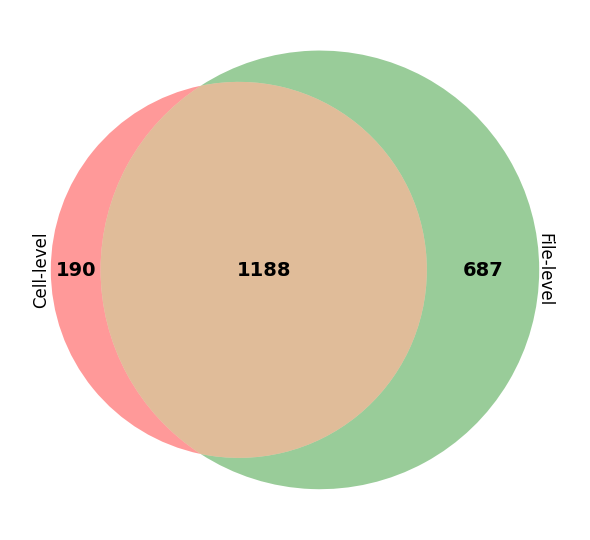

In [66]:
import matplotlib.pyplot as plt

cell_set = set(cell_repli_nbs)
file_set = set(file_repli_nbs)

both = cell_set & file_set
only_cell = cell_set - file_set
only_file = file_set - cell_set


# If you want to confirm the two approaches cover the same notebook universe:
all_cell = set(cell_repli_nbs) | set(cell_non_repli_nbs)
all_file = set(file_repli_nbs) | set(file_non_repli_nbs)

# ---- Venn diagram ----
from matplotlib_venn import venn2
plt.figure(figsize=(6, 6))
v=venn2(
    subsets=(len(only_cell), len(only_file), len(both)),
    set_labels=("Cell-level", "File-level"),
)
if v.set_labels[0] is not None:
    v.set_labels[0].set_position((-0.60, 0.0))
    v.set_labels[0].set_horizontalalignment("center")
    v.set_labels[0].set_verticalalignment("center")
    v.set_labels[0].set_rotation(90)

for text in v.subset_labels:
    if text: text.set_fontsize(14)
    text.set_fontweight('bold')

# Right label: place on right, rotate -90
if v.set_labels[1] is not None:
    v.set_labels[1].set_position((0.635, 0.0))
    v.set_labels[1].set_horizontalalignment("center")
    v.set_labels[1].set_verticalalignment("center")
    v.set_labels[1].set_rotation(-90)
# plt.title("Successfully modernized notebooks (replicable)")
plt.tight_layout()
plt.savefig("venn_diagram_upgrade_replicable.png", dpi=600)
plt.show()

# RQ2: ave fixes in cell-level and file-level

In [1]:
import json
import os
from pathlib import Path
from tqdm import tqdm
import plotly.graph_objects as go
import re

threshold = 10
# Load shared resources
with open("./upgrade/competition_score_rank.json", "r", encoding="utf-8") as f:
    lower_better = json.load(f)
with open("./kernel.json", "r") as f:
    kernel_content = json.load(f)

# Helper functions for classification
def get_score_map(score_content):
    # Returns a dict {filename: score}
    scores = {}
    for key, val in score_content.items():
        if "status" in val and "score" in val and "score" in val["score"]:
            sc = val["score"]["score"]
            if sc != "error":
                scores[key] = sc
    return scores


with open("./verification/baseline_non_reproducible.json") as f:
    baseline_non_reproducible = json.load(f)
with open("./verification/backporting_non_reproducible.json") as f:
    downgrade_non_reproducible = json.load(f)
with open("./verification/gpt_file_non_reproducible.json") as f:
    gpt_file_non_reproducible = json.load(f)
with open("./verification/oss_file_non_reproducible.json") as f:
    oss_file_non_reproducible = json.load(f)


def get_failure_reason(run_type, info):
    """Return one primary failure reason, or None if successful."""
    if not isinstance(info, dict):
        return "Failed"

    detail = info.get("detail", "") or ""
    error = info.get("error", "") or ""
    execution_time = info.get("execution_time", 0) or 0

    if run_type in UPGRADE_RUN_TYPES:
        if info.get("failed") == 1:
            return "LLM Failed"

        if execution_time > 600:
            return "Timeout"

        # Check this before "Not saving", since a disk-space failure may
        # also lack the NbConvert writing message.
        if "No space left on device" in error:
            return "Failed"

        if "[NbConvertApp] Writing " not in detail:
            return "Not saving Notebooks"

        return None

    if run_type == "Backporting":
        if execution_time > 600:
            return "Timeout"

        if "No space left on device" in error:
            return "Failed"

        if (
            "Backporting Failed. Aborting." in detail
            or "Environment processed." not in detail
        ):
            return "Backporting Failed"

        if "[NbConvertApp] Writing " not in detail:
            return "Not saving Notebooks"

        if info.get("failed") == 1:
            return "Failed"

        return None

    if execution_time > 600:
        return "Timeout"

    if "No space left on device" in error:
        return "Failed"

    if "[NbConvertApp] Writing " not in detail:
        return "Not saving Notebooks"

    if info.get("failed") == 1:
        return "Failed"

    return None

def is_failed_result(run_type, info):
    return get_failure_reason(run_type, info) is not None

def parse_entity_path_parts(entity):
    """
    Parse:
        competition_notebook_name_version_cell.ipynb

    Example:
        competition_author_notebook_v6_C1.ipynb

    Returns:
        competition = competition
        notebook_name = author_notebook
        version = v6
    """
    parts = Path(entity).stem.split("_")

    # Need at least:
    # competition, notebook_name, version, final suffix
    if len(parts) < 4:
        return None

    competition = parts[0]
    notebook_name = "_".join(parts[1:-2])
    version = parts[-2] if parts[-2] else None

    if not competition or not notebook_name or not version:
        return None

    return competition, notebook_name, version

def normalize_retry_result(payload, entity):
    """
    Support result.json files that are either:

        1. The result dictionary itself
        2. {entity: result_dictionary}
        3. {entity_stem: result_dictionary}
        4. {"result": result_dictionary}
    """
    if not isinstance(payload, dict):
        return {}

    entity_stem = Path(entity).stem

    if entity in payload and isinstance(payload[entity], dict):
        return payload[entity]

    if entity_stem in payload and isinstance(payload[entity_stem], dict):
        return payload[entity_stem]

    for wrapper_key in ("result", "info", "data"):
        wrapped = payload.get(wrapper_key)

        if isinstance(wrapped, dict):
            if entity in wrapped and isinstance(wrapped[entity], dict):
                return wrapped[entity]

            if (
                entity_stem in wrapped
                and isinstance(wrapped[entity_stem], dict)
            ):
                return wrapped[entity_stem]

            # The wrapped dictionary may itself be the result.
            if any(
                key in wrapped
                for key in (
                    "status",
                    "score",
                    "detail",
                    "execution_time",
                    "failed",
                    "error",
                )
            ):
                return wrapped

    return payload


def path_from_nbconvert_detail(detail, attempt_dir):
    """
    Try to extract the output notebook path from:

        [NbConvertApp] Writing ... to some/path.ipynb
    """
    if not isinstance(detail, str):
        return None

    match = re.search(
        r"\[NbConvertApp\]\s+Writing.*?\s+to\s+([^\n\r]+?\.ipynb)",
        detail,
    )

    if not match:
        return None

    raw_path = Path(match.group(1).strip().strip("'\""))

    candidates = []

    if raw_path.is_absolute():
        candidates.append(raw_path)
    else:
        candidates.extend(
            [
                raw_path,
                attempt_dir / raw_path,
                attempt_dir / raw_path.name,
            ]
        )

    for candidate in candidates:
        if candidate.exists() and candidate.is_file():
            return candidate

    return None


def resolve_retry_script_path(attempt_dir, entity, retry_info):
    """
    Locate the executed notebook for a successful retry.

    Priority:
        1. Explicit path fields in result.json
        2. Path extracted from NbConvert detail
        3. attempt_dir / entity
        4. Any matching notebook under attempt_dir
    """
    path_keys = (
        "script_path",
        "output_path",
        "output_notebook",
        "executed_notebook",
        "notebook_path",
        "result_path",
    )

    for key in path_keys:
        raw_value = retry_info.get(key)

        if not isinstance(raw_value, str) or not raw_value:
            continue

        raw_path = Path(raw_value)

        candidates = (
            [raw_path]
            if raw_path.is_absolute()
            else [
                raw_path,
                attempt_dir / raw_path,
                attempt_dir / raw_path.name,
            ]
        )

        for candidate in candidates:
            if (
                candidate.exists()
                and candidate.is_file()
                and candidate.suffix == ".ipynb"
            ):
                return candidate

    detail_path = path_from_nbconvert_detail(
        retry_info.get("detail", ""),
        attempt_dir,
    )

    if detail_path is not None:
        return detail_path

    direct_candidates = [
        attempt_dir / entity,
        attempt_dir / Path(entity).name,
    ]

    for candidate in direct_candidates:
        if candidate.exists() and candidate.is_file():
            return candidate

    # Prefer a notebook with the exact same filename.
    exact_matches = list(attempt_dir.rglob(Path(entity).name))

    if exact_matches:
        return exact_matches[0]

    # Last fallback: use a unique .ipynb file in the retry directory.
    notebook_candidates = list(attempt_dir.rglob("*.ipynb"))

    if len(notebook_candidates) == 1:
        return notebook_candidates[0]

    return None


def find_successful_retry(
    run_type,
    root_path,
    entity,
    start_run=2,
    end_run=10,
):
    """
    Search run_2 through run_10.

    Returns:
        retry:
            Successful retry information, or None.

        attempt_history:
            A list containing the outcome and failure reason of every
            retry result that was found.
    """
    parsed = parse_entity_path_parts(entity)

    if parsed is None:
        return None, [
            {
                "run": None,
                "reason": "Failed",
                "detail": "Could not parse entity path",
            }
        ]

    competition, notebook_name, version = parsed

    verification_name = VERIFICATION_DIRS[run_type]
    verification_root = Path("./verification") / verification_name

    attempt_history = []

    for run_index in range(start_run, end_run + 1):
        attempt_dir = (
            verification_root
            / f"run_{run_index}"
            / "script_out"
            / competition
            / notebook_name
            / version
        )

        result_path = attempt_dir / "result.json"

        if not result_path.exists():
            attempt_history.append(
                {
                    "run": run_index,
                    "status": "Missing",
                    "reason": "Result not found",
                    "result_path": str(result_path),
                }
            )
            continue

        try:
            payload = json.loads(
                result_path.read_text(encoding="utf-8")
            )
        except Exception as exc:
            attempt_history.append(
                {
                    "run": run_index,
                    "status": "Failed",
                    "reason": "Failed",
                    "detail": f"Unreadable result.json: {exc}",
                    "result_path": str(result_path),
                }
            )
            continue

        retry_info = normalize_retry_result(payload, entity)
        failure_reason = get_failure_reason(run_type, retry_info)

        if failure_reason is not None:
            attempt_history.append(
                {
                    "run": run_index,
                    "status": "Failed",
                    "reason": failure_reason,
                    "result_path": str(result_path),
                }
            )
            continue

        retry_script_path = resolve_retry_script_path(
            attempt_dir,
            entity,
            retry_info,
        )

        if retry_script_path is None:
            attempt_history.append(
                {
                    "run": run_index,
                    "status": "Failed",
                    "reason": "Not saving Notebooks",
                    "detail": "Successful result but output notebook not found",
                    "result_path": str(result_path),
                }
            )
            continue

        attempt_history.append(
            {
                "run": run_index,
                "status": "Successful",
                "reason": None,
                "result_path": str(result_path),
                "script_path": str(retry_script_path),
            }
        )

        return (
            {
                "run": run_index,
                "info": retry_info,
                "script_path": retry_script_path,
                "result_path": result_path,
            },
            attempt_history,
        )

    return None, attempt_history


def is_replicable(run_type, entity, measured_score):
    if run_type == "Baseline":
        return entity not in baseline_non_reproducible

    if run_type == "Backporting":
        return entity not in downgrade_non_reproducible

    if run_type == "Cell":
        if isinstance(measured_score, str):
            return False

        competition = entity.split("_")[0]
        submission_id = (
            "_".join(Path(entity).stem.split("_")[1:])
            + ".ipynb"
        )

        submission_info = (
            kernel_content
            .get(competition, {})
            .get(submission_id, {})
        )

        reported_score = submission_info.get("ps")

        try:
            reported_score = float(reported_score)
            measured_score = float(measured_score)
        except (TypeError, ValueError):
            return False

        if reported_score == 0.0:
            return False

        difference_percentage = (
            abs(measured_score - reported_score)
            / abs(reported_score)
            * 100
        )

        return difference_percentage <= float(threshold)

    if run_type == "GPT":
        return entity not in gpt_file_non_reproducible

    if run_type == "OSS":
        return entity not in oss_file_non_reproducible

    raise ValueError(f"Unknown run type: {run_type}")


def default_script_path(run_type, root_path, entity, info):
    """Resolve the ordinary non-retry executed notebook path."""
    scripts_dir = Path(root_path) / "script_out_allINone"

    if run_type == "Baseline" or run_type == "Backporting":
        return scripts_dir / entity

    fix = info.get("fix", 0)

    if fix > 0:
        return scripts_dir / f"fix_{fix}" / entity

    return Path("./results/baseline/script_out_allINone") / entity


def notebook_has_error(script_path):
    """
    Return:
        True  -> notebook contains an error output
        False -> notebook has no error output
        None  -> notebook could not be loaded
    """
    if not script_path.exists():
        print(f"Script NOT FOUND: {script_path}")
        return None

    try:
        notebook = json.loads(
            script_path.read_text(encoding="utf-8")
        )
    except Exception as exc:
        print(f"Failed to load {script_path}: {exc}")
        return None

    for cell in notebook.get("cells", []):
        if cell.get("cell_type") != "code":
            continue

        for output in cell.get("outputs", []):
            if output.get("output_type") == "error":
                return True

    return False

def extract_measured_score(info):
    """
    Extract a scalar score from one result object.

    Possible formats:
        {"score": {"score": 0.123}}
        {"score": {"error": "..."}}
        {"score": 0.123}
    """
    if not isinstance(info, dict):
        return None

    score_data = info.get("score")

    if isinstance(score_data, dict):
        if "error" in score_data:
            return "n/r"

        return score_data.get("score")

    return score_data

def categorize_notebooks(run_type, root_path):
    # Broad categories used by the existing Sankey.
    category_map = {} # {filename: category_index}
    # Detailed categories distinguishing whether CSV/status exists.
    detailed_category_map = {}
    effective_run_map = {}
    score_path = f"{root_path}/csv_score.json"

    with open(score_path, 'r') as f:
        score_content = json.load(f)
    data = score_content

    scores_lut = get_score_map(score_content) if "upgrade" not in root_path else {}
    full_files = {f for f in os.listdir('./baseline/notebooks') if f.endswith('.ipynb')}

    failure_reason_map = {}
    retry_failure_history = {}
    recovered_retries = []
    permanently_failed = []
    unreadable_scripts = []

    for entity, original_info in tqdm(data.items()):
        if entity not in full_files:
            continue
        
        retry = None
        effective_info = original_info

        script_path = default_script_path(
            run_type,
            root_path,
            entity,
            original_info,
        )

        llm_fix = int(original_info.get("fix", 0) or 0)

        original_failure_reason = get_failure_reason(run_type, original_info)
        # Retry notebooks whose original execution failed.
        if original_failure_reason is not None:
            retry, attempt_history = find_successful_retry(
                run_type,
                root_path,
                entity,
                start_run=2,
                end_run=10,
            )

            retry_failure_history[entity] = {
                "original": {
                    "run": 1,
                    "status": "Failed",
                    "reason": original_failure_reason,
                },
                "retries": attempt_history,
            }

            if retry is None:
                category_map[entity] = "Failed"

                valid_failure_reasons = {
                    "Timeout",
                    "Not saving Notebooks",
                    "Backporting Failed",
                    "LLM Failed",
                    "Failed",
                }

                failed_retry_reasons = [
                    attempt.get("reason")
                    for attempt in attempt_history
                    if (
                        attempt.get("status") == "Failed"
                        and attempt.get("reason") in valid_failure_reasons
                    )
                ]

                # Use the latest actual retry failure reason.
                # If no retry result existed, retain the original-run reason.
                final_reason = (
                    failed_retry_reasons[-1]
                    if failed_retry_reasons
                    else original_failure_reason
                )

                if final_reason not in valid_failure_reasons:
                    final_reason = "Failed"

                detailed_category_map[entity] = final_reason
                failure_reason_map[entity] = final_reason
                permanently_failed.append(entity)
                continue

            effective_info = retry["info"]
            script_path = retry["script_path"]

            recovered_retries.append(
                {
                    "entity": entity,
                    "original_reason": original_failure_reason,
                    "recovered_run": retry["run"],
                    "script_path": str(script_path),
                }
            )

        has_error = notebook_has_error(script_path)

        if has_error is None:
            category_map[entity] = "Failed"
            detailed_category_map[entity] = "Failed"
            failure_reason_map[entity] = "Failed"
            unreadable_scripts.append(entity)
            continue

        # Use the successful retry result when available.
        measured_score = extract_measured_score(effective_info)

        if measured_score is None:
            if run_type == "Baseline":
                measured_score = scores_lut.get(entity)
            else:
                measured_score = extract_measured_score(
                    score_content.get(entity, {})
                )

        replicable = is_replicable(
            run_type,
            entity,
            measured_score,
        )

        # CSV/status availability:
        #
        # A retry may omit "status" even though the original csv_score.json
        # record contains it, so check both records.
        has_csv = (
            "status" in effective_info
            or "status" in original_info
        )

        if has_error:
            if replicable and has_csv:
                broad_category = "Error Reproducible"
                detailed_category = "Error Reproducible"

            elif has_csv:
                broad_category = "Error Non-reproducible"
                detailed_category = (
                    "Error Non-reproducible w/ CSV"
                )

            else:
                broad_category = "Error Non-reproducible"
                detailed_category = (
                    "Error Non-reproducible w/o CSV"
                )

        else:
            if replicable and has_csv:
                broad_category = "Error-free Reproducible"
                detailed_category = "Error-free Reproducible"

            elif has_csv:
                broad_category = "Error-free Non-reproducible"
                detailed_category = (
                    "Error-free Non-reproducible w/ CSV"
                )

            else:
                broad_category = "Error-free Non-reproducible"
                detailed_category = (
                    "Error-free Non-reproducible w/o CSV"
                )

        category_map[entity] = broad_category
        detailed_category_map[entity] = detailed_category
        effective_run_map[entity] = {
            # This is the number of LLM fixes, not the retry run number.
            "fix": llm_fix,

            # run_2, run_3, etc. are execution retries of the same fix.
            "execution_run": retry["run"] if retry is not None else 1,
            "recovered_retry": retry is not None,

            # Artifact actually used for classification.
            "script_path": str(script_path),
            "has_error": has_error,
            "measured_score": measured_score,
            "replicable": replicable,

            "category": broad_category,
            "detailed_category": detailed_category,
        }


    return category_map, detailed_category_map, effective_run_map

# Configuration
roots = {
    "Baseline": "./results/baseline",
    "Backporting": "./results/downgrade/baseline",
    "GPT": "./results/upgrade/gpt_file",
    "OSS": "./results/upgrade/oss_file",
    "Cell": "./results/upgrade/gpt_cell"
}
VERIFICATION_DIRS = {
    "Baseline": "baseline",
    "Backporting": "backporting",
    "GPT": "gpt_file",
    "OSS": "oss_file",
    "Cell": "gpt_cell",
}
UPGRADE_RUN_TYPES = {"GPT", "OSS", "Cell"}
# Run classification
print("Classifying GPT File-level Upgrade...")
gpt_file_cats, gpt_file_detailed_cats, gpt_file_effective = categorize_notebooks("GPT",roots["GPT"])

Classifying GPT File-level Upgrade...


100%|██████████| 8210/8210 [04:08<00:00, 32.98it/s] 


In [ ]:
from collections import Counter
import numpy as np

ERROR_REPRODUCIBLE = "Error Reproducible"
ERROR_FREE_REPRODUCIBLE = "Error-free Reproducible"

REPRODUCIBLE_CATEGORIES = {
    ERROR_REPRODUCIBLE,
    ERROR_FREE_REPRODUCIBLE,
}

# Keep IDs so that duplicates and missing records can be detected.
reproducible_records = {}

for entity, category in gpt_file_cats.items():
    if category not in REPRODUCIBLE_CATEGORIES:
        continue

    meta = gpt_file_effective.get(entity)

    if meta is None:
        raise KeyError(
            f"{entity} is reproducible in gpt_file_cats "
            "but missing from gpt_file_effective"
        )

    fix = meta["fix"]

    if not isinstance(fix, int) or fix <= 0:
        raise ValueError(
            f"{entity} has reproducible category "
            f"{category!r} but invalid fix={fix!r}"
        )

    reproducible_records[entity] = {
        "fix": fix,
        "category": category,
        "has_error": meta["has_error"],
        "recovered_retry": meta["recovered_retry"],
        "execution_run": meta["execution_run"],
        "script_path": meta["script_path"],
    }

all_repli_fix = [
    record["fix"]
    for record in reproducible_records.values()
]

error_repli_fix = [
    record["fix"]
    for record in reproducible_records.values()
    if record["category"] == ERROR_REPRODUCIBLE
]

error_free_repli_fix = [
    record["fix"]
    for record in reproducible_records.values()
    if record["category"] == ERROR_FREE_REPRODUCIBLE
]

all_counts = Counter(all_repli_fix)
error_counts = Counter(error_repli_fix)
error_free_counts = Counter(error_free_repli_fix)

print("All:", len(all_repli_fix))
print("E-R:", len(error_repli_fix))
print("EF-R:", len(error_free_repli_fix))

print("Fix 1 All:", all_counts[1])
print("Fix 1 E-R:", error_counts[1])
print("Fix 1 EF-R:", error_free_counts[1])

assert len(all_repli_fix) == (
    len(error_repli_fix)
    + len(error_free_repli_fix)
)

assert all_counts == error_counts + error_free_counts

All: 3292
E-R: 895
EF-R: 2397
Fix 1 All: 1328
Fix 1 E-R: 489
Fix 1 EF-R: 839


Overall Upgrade Statistics:
All upgraded notebooks -> n=8210, Total fixes=82745, Mean=10.08


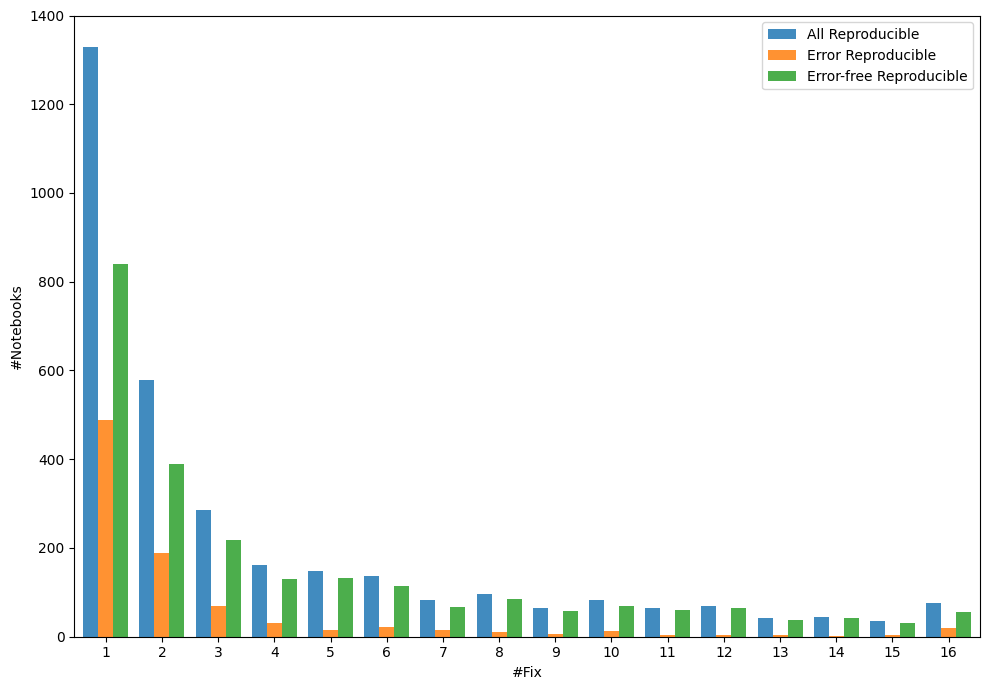

Group Summary Statistics:
To All: n=3292, Median=2.00, Mean=3.87
To E-R: n=895, Median=1.00, Mean=2.56
To EF-R: n=2397, Median=2.00, Mean=4.35


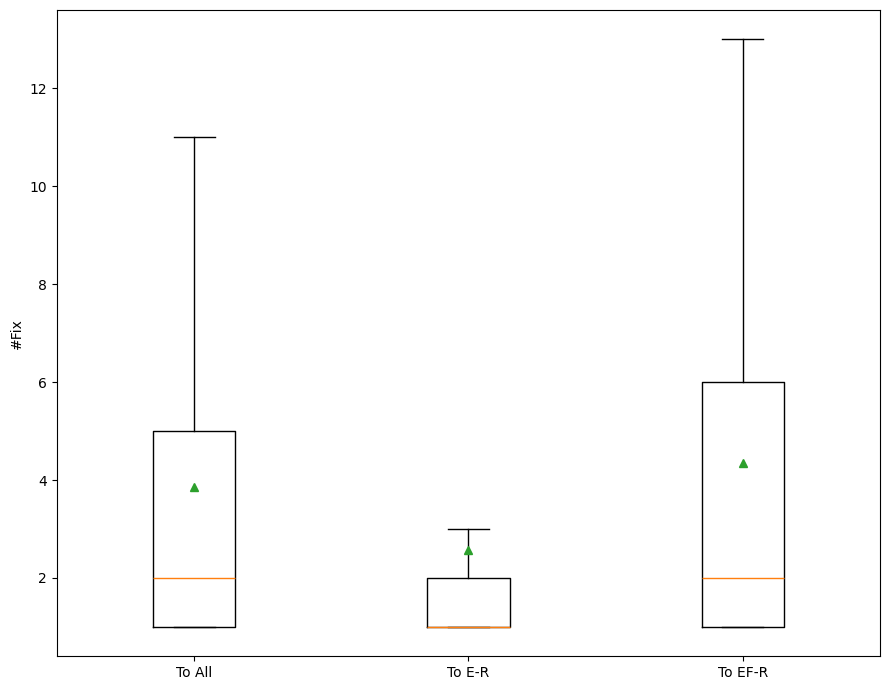

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def normalize_fix(value):
    """Convert a stored fix value to a non-negative integer."""
    try:
        fix = int(value or 0)
    except (TypeError, ValueError):
        return 0

    return max(fix, 0)


with open("./results/upgrade/gpt_file/executable_files_w_timer_parrallel.json", "r") as f:
    executable_files_w_timer_parrallel = json.load(f)
    
total_upgraded_notebooks = len(
    executable_files_w_timer_parrallel
)

total_fix = sum(
    normalize_fix(record.get("fix", 0))
    for record in executable_files_w_timer_parrallel.values()
)

mean_fixes_all_upgraded = (
    total_fix / total_upgraded_notebooks
    if total_upgraded_notebooks
    else float("nan")
)

print("Overall Upgrade Statistics:")
print(
    f"All upgraded notebooks -> "
    f"n={total_upgraded_notebooks}, "
    f"Total fixes={total_fix}, "
    f"Mean={mean_fixes_all_upgraded:.2f}"
)


groups = {
    "All Reproducible": all_repli_fix,
    "Error Reproducible": error_repli_fix,
    "Error-free Reproducible": error_free_repli_fix,
}

counts = {
    name: Counter(values)
    for name, values in groups.items()
}

fix_vals = sorted(
    set().union(
        *(counter.keys() for counter in counts.values())
    )
)

x = np.arange(len(fix_vals))

n_groups = len(groups)
group_width = 0.80
bar_width = group_width / n_groups

offsets = (
    np.arange(n_groups)
    - (n_groups - 1) / 2
) * bar_width

fig, ax = plt.subplots(figsize=(10, 7))

for i, name in enumerate(groups):
    y = [
        counts[name].get(fix, 0)
        for fix in fix_vals
    ]

    ax.bar(
        x + offsets[i],
        y,
        width=bar_width,
        label=name,
        alpha=0.85,
    )

ax.set_xlabel("#Fix")
ax.set_ylabel("#Notebooks")

ax.set_xticks(x)
ax.set_xticklabels(fix_vals)

# Set y-axis range and tick interval
ax.set_ylim(0, 1400)
ax.set_yticks(np.arange(0, 1401, 200))

ax.margins(x=0.01)
ax.legend()

fig.tight_layout()
fig.savefig(
    "fix_distribution_upgrade_file.png",
    dpi=600,
    bbox_inches="tight",
)
plt.show()


groups = {
    "To All": all_repli_fix,
    "To E-R": error_repli_fix,
    "To EF-R": error_free_repli_fix,
}

print("Group Summary Statistics:")
for label, values in groups.items():
    print(
        f"{label}: "
        f"n={len(values)}, "
        f"Median={np.median(values):.2f}, "
        f"Mean={np.mean(values):.2f}"
    )

labels = list(groups.keys())
data = [groups[label] for label in labels]

fig, ax = plt.subplots(figsize=(9, 7))

ax.boxplot(
    data,
    tick_labels=labels,
    showmeans=True,
    showfliers=False,
)

ax.set_ylabel("#Fix")

fig.tight_layout()
fig.savefig(
    "fix_boxplot_upgrade_file.png",
    dpi=600,
    bbox_inches="tight",
)
plt.show()

In [ ]:
# Fix @ 1 — replication rate after first fix iteration (gpt_file)
import json
from tqdm import tqdm

total_target_notebooks = len(
    executable_files_w_timer_parrallel
)

fix_1_success_ids = {
    entity
    for entity, record in reproducible_records.items()
    if record["fix"] == 1
}

fix_1_success = len(fix_1_success_ids)

replication_rate = (
    fix_1_success
    / total_target_notebooks
    * 100
)

print(f"total_target_notebooks={total_target_notebooks}")
print(f"fix_1_success={fix_1_success}")
print(f"replication_rate={replication_rate:.2f}%")

total_target_notebooks=8210
fix_1_success=1328
replication_rate=16.18%


In [78]:
from tqdm import tqdm
from statistics import mean, median

upgrade_type = "cell"
print(f"upgrade_type: {upgrade_type}")
def is_replicable(reported_score,measured_score):

    if isinstance(reported_score, float) and isinstance(measured_score, float) and reported_score != 0.0:
        thrus = abs(measured_score-reported_score)/abs(reported_score) * 100
    else:
        thrus = None

    return (thrus is not None) and (thrus <= float(10))

def _has_error(nb: str) -> bool:
    for i, cell in enumerate(nb.get('cells', [])):
        if cell.get('cell_type') == 'code':
            for out in cell.get('outputs', []):
                if out.get('output_type') == 'error':
                    return True
    
    return False

with open("./verification/baseline_non_reproducible.json") as f:
    baselione_non_reproducible = json.load(f)

from_error_non_repli_fix_cell = []
all_repli_fix_cell = []
error_repli_fix_cell = []
error_free_repli_fix_cell = []
error_non_repli_fix_cell = []
error_free_non_repli_fix_cell = []
with open(f"./results/upgrade/gpt_{upgrade_type}/csv_score.json", "r") as f:
    score_content = json.load(f)
with open("./results/baseline/csv_score.json", "r") as f:
    baseline_exec_files = json.load(f)

for k, v in tqdm(sorted(score_content.items())):
    if v.get('failed', 0) == 1:
        continue
    if v['fix'] == 0:
        continue
    
    if v['fix'] -1 == 0:
        with open(f"./results/baseline/script_out_allINone/{k}", "r") as f:
            pred_nb = json.load(f)
    else:
        with open(f"./results/upgrade/gpt_{upgrade_type}/script_out_allINone/fix_{v['fix']-1}/{k}", "r") as f:
            pred_nb = json.load(f)
    error_nb = _has_error(pred_nb)
    
    replicable = is_replicable(score_content[k]['target'], score_content[k].get('score', None))
    if replicable and v.get('execution_time', 0) <= 600:
        all_repli_fix_cell.append(v['fix'])
        if error_nb:
            error_repli_fix_cell.append(v['fix'])
        else:
            error_free_repli_fix_cell.append(v['fix'])
    if not replicable:
        if error_nb:
            error_non_repli_fix_cell.append(v['fix'])
        else:
            error_free_non_repli_fix_cell.append(v['fix'])

    with open(f"./results/baseline/script_out_allINone/{k}", "r") as f:
        baseline_nb = json.load(f)
    error_nb = _has_error(baseline_nb)

    if error_nb and k not in baselione_non_reproducible:
        from_error_non_repli_fix_cell.append(v['fix'])

print(f"{mean(all_repli_fix_cell)=},{mean(error_repli_fix_cell)=},{mean(error_free_repli_fix_cell)=},{mean(error_non_repli_fix_cell)=},{mean(error_free_non_repli_fix_cell)=}")
print(f"{median(all_repli_fix_cell)=},{median(error_repli_fix_cell)=},{median(error_free_repli_fix_cell)=},{median(error_non_repli_fix_cell)=},{median(error_free_non_repli_fix_cell)=}")

upgrade_type = "gpt_file"
print(f"upgrade_type: {upgrade_type}")

with open("./verification/gpt_file_non_reproducible.json", "r") as f:
    gpt_non_reproducible = json.load(f)
    
def is_replicable(entity):
    if entity in gpt_non_reproducible:
        return False
    else:
        return True

from_error_non_repli_fix_file = []
all_repli_fix_file = []
error_repli_fix_file = []
error_free_repli_fix_file = []
error_non_repli_fix_file = []
error_free_non_repli_fix_file = []
with open(f"./results/upgrade/{upgrade_type}/csv_score.json", "r") as f:
    score_content = json.load(f)

with open("./results/baseline/csv_score.json", "r") as f:
    baseline_exec_files = json.load(f)

for k, v in tqdm(sorted(score_content.items())):
    if v.get('failed', 0) == 1:
        continue
    if v['fix'] == 0:
        continue
    
    if v['fix'] -1 == 0:
        with open(f"./results/baseline/script_out_allINone/{k}", "r") as f:
            pred_nb = json.load(f)
    else:
        with open(f"./results/upgrade/{upgrade_type}/script_out_allINone/fix_{v['fix']-1}/{k}", "r") as f:
            pred_nb = json.load(f)
    error_nb = _has_error(pred_nb)
    
    replicable = is_replicable(k)
    if replicable and v.get('execution_time', 0) <= 600:
        all_repli_fix_file.append(v['fix'])
        if error_nb:
            error_repli_fix_file.append(v['fix'])
        else:
            error_free_repli_fix_file.append(v['fix'])
    if not replicable:
        if error_nb:
            error_non_repli_fix_file.append(v['fix'])
        else:
            error_free_non_repli_fix_file.append(v['fix'])

    with open(f"./results/baseline/script_out_allINone/{k}", "r") as f:
        baseline_nb = json.load(f)
    error_nb = _has_error(baseline_nb)
    if error_nb and k not in baselione_non_reproducible:
        from_error_non_repli_fix_file.append(v['fix'])

print(f"{mean(all_repli_fix_file)=},{mean(error_repli_fix_file)=},{mean(error_free_repli_fix_file)=},{mean(error_non_repli_fix_file)=},{mean(error_free_non_repli_fix_file)=}")
print(f"{median(all_repli_fix_file)=},{median(error_repli_fix_file)=},{median(error_free_repli_fix_file)=},{median(error_non_repli_fix_file)=},{median(error_free_non_repli_fix_file)=}")

upgrade_type: cell


100%|██████████| 2842/2842 [00:16<00:00, 171.93it/s]


mean(all_repli_fix_cell)=6.038461538461538,mean(error_repli_fix_cell)=4.7746144721233685,mean(error_free_repli_fix_cell)=8.029906542056075,mean(error_non_repli_fix_cell)=16,mean(error_free_non_repli_fix_cell)=16
median(all_repli_fix_cell)=5.0,median(error_repli_fix_cell)=3,median(error_free_repli_fix_cell)=8,median(error_non_repli_fix_cell)=16,median(error_free_non_repli_fix_cell)=16
upgrade_type: gpt_file


100%|██████████| 8210/8210 [00:19<00:00, 420.35it/s] 

mean(all_repli_fix_file)=3.853227771010962,mean(error_repli_fix_file)=1.9745358090185676,mean(error_free_repli_fix_file)=6.384560400285919,mean(error_non_repli_fix_file)=14.84766050054407,mean(error_free_non_repli_fix_file)=15.779333520022403
median(all_repli_fix_file)=2.0,median(error_repli_fix_file)=1,median(error_free_repli_fix_file)=5,median(error_non_repli_fix_file)=16,median(error_free_non_repli_fix_file)=16


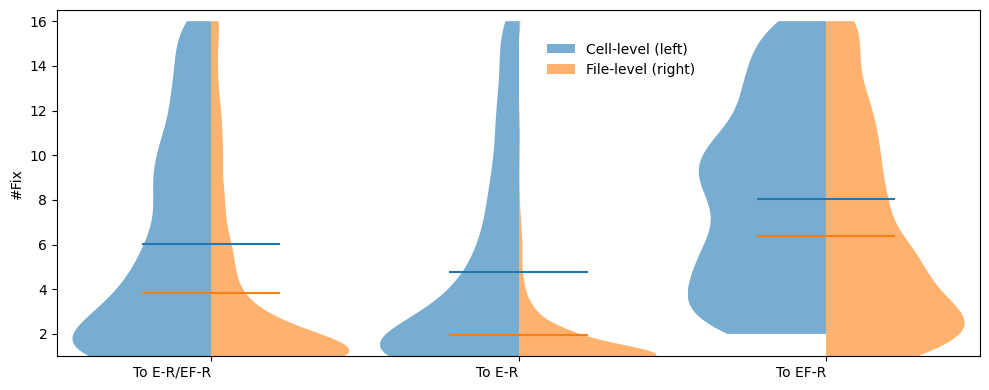

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

labels = [
    "To E-R/EF-R",
    "To E-R",
    "To EF-R",
    # "To From Error Non-Reproducible",
]

left_groups = {
    "To E-R/EF-R": all_repli_fix_cell,
    "To E-R": error_repli_fix_cell,
    "To EF-R": error_free_repli_fix_cell,
    # "To From Error Non-Reproducible": from_error_non_repli_fix_cell,
}

right_groups = {
    "To E-R/EF-R": all_repli_fix_file,
    "To E-R": error_repli_fix_file,
    "To EF-R": error_free_repli_fix_file,
    # "To From Error Non-Reproducible": from_error_non_repli_fix_file,
}

left_data = [left_groups[k] for k in labels]
right_data = [right_groups[k] for k in labels]

fig, ax = plt.subplots(figsize=(10, 4))

pos = np.arange(1, len(labels) + 1)

# draw both violins centered at the same x positions
vp_left = ax.violinplot(left_data, positions=pos, widths=0.9, showmeans=True, showextrema=False, showmedians=False)
vp_right = ax.violinplot(right_data, positions=pos, widths=0.9, showmeans=True, showextrema=False, showmedians=False)

# helper: clip each violin body to left or right half
def clip_violin_bodies(vp, positions, side):
    for body, x in zip(vp["bodies"], positions):
        path = body.get_paths()[0]
        verts = path.vertices
        xmin, xmax = verts[:, 0].min(), verts[:, 0].max()
        ymin, ymax = verts[:, 1].min(), verts[:, 1].max()
        xmid = x  # center

        if side == "left":
            rect = plt.Rectangle((xmin, ymin), xmid - xmin, ymax - ymin, transform=ax.transData)
        else:  # "right"
            rect = plt.Rectangle((xmid, ymin), xmax - xmid, ymax - ymin, transform=ax.transData)

        body.set_clip_path(rect)

clip_violin_bodies(vp_left, pos, "left")
clip_violin_bodies(vp_right, pos, "right")

# style a bit so left/right are distinguishable (optional)
for b in vp_left["bodies"]:
    b.set_alpha(0.6)
for b in vp_right["bodies"]:
    b.set_alpha(0.6)

# means (optional): ensure means are visible
if "cmeans" in vp_left:
    vp_left["cmeans"].set_linewidth(1.5)
if "cmeans" in vp_right:
    vp_right["cmeans"].set_linewidth(1.5)

left_fc = vp_left["bodies"][0].get_facecolor()[0]
right_fc = vp_right["bodies"][0].get_facecolor()[0]

x_leg = pos[1] + (pos[2] - pos[1]) / 3.0   # 1/3 between violin #2 and #3

y0, y1 = ax.get_ylim()
y_leg = y0 + 0.85 * (y1 - y0)             # put it high to avoid dense parts (tweak 0.85)

ax.legend(
    handles=[
        Patch(facecolor=left_fc, edgecolor="none", alpha=0.6, label="Cell-level (left)"),
        Patch(facecolor=right_fc, edgecolor="none", alpha=0.6, label="File-level (right)"),
    ],
    frameon=False,
    loc="center",
    bbox_to_anchor=(x_leg, y_leg),
    bbox_transform=ax.transData,  # <-- key: anchor interpreted in data coords
    borderaxespad=0.0,
)
ax.set_xticks(pos)
ax.set_xticklabels(labels, ha="right")
ax.set_ylabel("#Fix")
ax.set_xlim(0.5, len(labels) + 0.5)
ax.set_ylim(1, 16.5) 
# # optional: legend using proxy artists
# left_proxy = plt.Line2D([0], [0], linewidth=8, alpha=0.6, label="Cell-level upgrade (left)")
# right_proxy = plt.Line2D([0], [0], linewidth=8, alpha=0.6, label="File-level upgrade (right)")
# ax.legend(handles=[left_proxy, right_proxy], frameon=False)

plt.tight_layout()
plt.savefig("fix_combo_violin.png", dpi=600)
plt.show()


# RQs 3 and 4: State success rate and cost

In [82]:
import json
from tqdm import tqdm
from statistics import mean
    
def _has_error(nb: str) -> bool:
    for i, cell in enumerate(nb.get('cells', [])):
        if cell.get('cell_type') == 'code':
            for out in cell.get('outputs', []):
                if out.get('output_type') == 'error':
                    return True
    
    return False

with open("./verification/gpt_file_non_reproducible.json", "r") as f:
    gpt_non_reproducible = json.load(f)
    
def is_replicable(entity):
    if entity in gpt_non_reproducible:
        return False
    else:
        return True

upgrade_type = "gpt_file"

with open(f"./results/upgrade/{upgrade_type}/csv_score.json", "r") as f:
    score_content = json.load(f)
with open(f"./results/upgrade/{upgrade_type}/executable_files_w_timer_parrallel.json", "r") as f:
    exec_files = json.load(f)
with open("./results/baseline/executable_files_w_timer_parrallel.json", "r") as f:
    baseline_exec_files = json.load(f)


t = 0 # current state: timeout 
t_t = 0 # timeout to timeout
t_e_r = 0 # timeout to error replicable
t_ef_r = 0 # timeout to error-free replicable
t_e_n_r = 0 # timeout to error non-replicable
t_ef_n_r = 0 # timeout to error-free non-replicable

e_n_r = 0 # current state: error non-replicable 
e_n_r_e_n_r = 0 # error non-replicable to error non-replicable
e_n_r_t = 0 # error non-replicable to timeout
e_n_r_ef_n_r = 0 # error non-replicable to error-free non-replicable
e_n_r_e_r = 0 # error non-replicable to error replicable
e_n_r_ef_r = 0 # error non-replicable to error-free replicable

ef_n_r = 0 # current state: error-free non-replicable
ef_n_r_e_n_r = 0 # error-free non-replicable to error non-replicable
ef_n_r_t = 0 # error-free non-replicable to timeout
ef_n_r_ef_n_r = 0 # error-free non-replicable to error-free non-replicable
ef_n_r_e_r = 0 # error-free non-replicable to error replicable
ef_n_r_ef_r = 0 # error-free non-replicable to error-free replicable

error_fix_input_token = []
error_fix_cached_token = []
error_fix_output_token = []

calibrate_performance_input_token = []
calibrate_performance_cached_token = []
calibrate_performance_output_token = []

reduce_runtime_input_token = []
reduce_runtime_cached_token = []
reduce_runtime_output_token = []

cost = []
input_token = []
cached_token = []
output_token = []

reduce_runtime_cost = []
error_fix_cost = []
calibrate_performance_cost = []

for k, v in tqdm(sorted(score_content.items())):
    fixs = v['fix']
    if v.get('failed', 0) == 1 or fixs == 0:
        continue

    f_input_token = []
    f_cached_token = []
    f_output_token = []
    f_cost = []

    for fix in range(0, fixs):
        # current notebook
        if fix == 0:
            with open(f"./results/baseline/script_out_allINone/{k}", "r") as f:
                curr_nb = json.load(f)
            exec_time = baseline_exec_files[k]['execution_time']
        else:
            with open(f"./results/upgrade/{upgrade_type}/script_out_allINone/fix_{fix}/{k}", "r") as f:
                curr_nb = json.load(f)
            exec_time = exec_files[k]['upgrade'][str(fix)]['execution_time']
        error_nb = _has_error(curr_nb)

        fix = fix + 1
        i_tokens = exec_files[k]['upgrade'][str(fix)]['full_message']['usage']['prompt_tokens'] - exec_files[k]['upgrade'][str(fix)]['full_message']['usage']['prompt_tokens_details']['cached_tokens']
        c_token = exec_files[k]['upgrade'][str(fix)]['full_message']['usage']['prompt_tokens_details']['cached_tokens']
        o_token = exec_files[k]['upgrade'][str(fix)]['full_message']['usage']['completion_tokens']
        cost_ = 1.75 * (i_tokens / 1_000_000) + 0.175 * (c_token / 1_000_000) + 14 * (o_token / 1_000_000)
        fix = fix - 1

        f_input_token.append(i_tokens)
        f_cached_token.append(c_token)
        f_output_token.append(o_token)
        f_cost.append(cost_)
        
        if exec_time > 600:
            reduce_runtime_input_token.append(i_tokens)
            reduce_runtime_cached_token.append(c_token)
            reduce_runtime_output_token.append(o_token)
            reduce_runtime_cost.append(cost_)
        else:
            if error_nb:
                error_fix_input_token.append(i_tokens)
                error_fix_cached_token.append(c_token)
                error_fix_output_token.append(o_token)
                error_fix_cost.append(cost_)
            else:
                calibrate_performance_input_token.append(i_tokens)
                calibrate_performance_cached_token.append(c_token)
                calibrate_performance_output_token.append(o_token)
                calibrate_performance_cost.append(cost_)


        # notebook after fixed 
        with open(f"./results/upgrade/{upgrade_type}/script_out_allINone/fix_{fix+1}/{k}", "r") as f:
            next_nb = json.load(f)
        next_error_nb = _has_error(next_nb)
        next_exec_time = exec_files[k]['upgrade'][str(fix+1)]['execution_time']


        if fix + 1 < fixs: # not the second last fix
            if exec_time > 600: # current state is timeout: next state can be timeout, error non-replicable, error-free non-replicable
                t += 1
                if next_exec_time > 600: # timeout
                    t_t += 1
                else: # not timeout
                    if next_error_nb: # error non-replicable
                        t_e_n_r += 1
                    else: # error-free non-replicable
                        t_ef_n_r += 1
                continue


            if error_nb: # current state is error non-replicable: next state can be timeout, error non-replicable, error-free non-replicable
                e_n_r += 1
                if next_error_nb: # error non-replicable
                    e_n_r_e_n_r += 1
                else: # error-free
                    if next_exec_time > 600: # timeout
                        e_n_r_t += 1
                    else: # error-free non-replicable
                        e_n_r_ef_n_r += 1
            else: # current state is error-free non-replicable: next state can be timeout, error non-replicable, error-free non-replicable
                ef_n_r += 1
                if next_error_nb: # error non-replicable
                    ef_n_r_e_n_r += 1
                else: # error-free
                    if next_exec_time > 600: # timeout
                        ef_n_r_t += 1
                    else: # error-free non-replicable
                        ef_n_r_ef_n_r += 1


        else: # the second last fix-check the final result
            repli = is_replicable(k)
            if not repli: # non-replicable
                if exec_time > 600: # current state is timeout: next state can be timeout, error non-replicable, error-free non-replicable
                    t += 1
                    if next_exec_time > 600: # timeout
                        t_t += 1
                    else: # not timeout
                        if next_error_nb: # error non-replicable
                            t_e_n_r += 1
                        else: # error-free non-replicable
                            t_ef_n_r += 1
                    continue
                if error_nb: # current state is error non-replicable: next state can be timeout, error non-replicable, error-free non-replicable
                    e_n_r += 1
                    if next_error_nb: # error non-replicable
                        e_n_r_e_n_r += 1
                    else: # error-free
                        if next_exec_time > 600: # timeout
                            e_n_r_t += 1
                        else: # error-free non-replicable
                            e_n_r_ef_n_r += 1
                else: # current state is error-free non-replicable: next state can be timeout, error non-replicable, error-free non-replicable
                    ef_n_r += 1
                    if next_error_nb: # error non-replicable
                        ef_n_r_e_n_r += 1
                    else: # error-free non-replicable
                        ef_n_r_ef_n_r += 1
            else: # replicable
                if exec_time > 600: # current state is timeout: next state can be error replicable, error-free replicable
                    t += 1
                    if next_error_nb: # error replicable
                        t_e_r += 1
                    else: # error-free replicable
                        t_ef_r += 1
                    continue

                if error_nb: # current state is error non-replicable: next state can be error replicable, error-free replicable
                    e_n_r += 1
                    if next_error_nb: # error replicable
                        e_n_r_e_r += 1
                    else: # error-free replicable
                        e_n_r_ef_r += 1
                else: # current state is error-free non-replicable: next state can be error replicable, error-free replicable
                    ef_n_r += 1
                    if next_error_nb: # error replicable
                        ef_n_r_e_r += 1
                    else: # error-free replicable
                        ef_n_r_ef_r += 1

    if len(f_cost) == 0:
        print(f"Error in {k} fix 1 / {fixs}")
        print(v)
        continue

    cost.append(sum(f_cost))
    input_token.append(sum(f_input_token))
    cached_token.append(sum(f_cached_token))
    output_token.append(sum(f_output_token))
                
print("=== Upgrade results ===")
print("GPT-5.2")
print(f"current state: timeout {t:,}")
print(f"    timeout to timeout: {t_t:,}")
print(f"    timeout to error non-replicable: {t_e_n_r:,}")
print(f"    timeout to error-free non-replicable: {t_ef_n_r:,}")
print(f"    timeout to error replicable: {t_e_r:,}")
print(f"    timeout to error-free replicable: {t_ef_r:,}\n")

print(f"current state: error non-replicable {e_n_r:,}")
print(f"    error non-replicable to timeout: {e_n_r_t:,}")
print(f"    error non-replicable to error non-replicable: {e_n_r_e_n_r:,}")
print(f"    error non-replicable to error-free non-replicable: {e_n_r_ef_n_r:,}")
print(f"    error non-replicable to error replicable: {e_n_r_e_r:,}")
print(f"    error non-replicable to error-free replicable: {e_n_r_ef_r:,}\n")

print(f"current state: error-free non-replicable {ef_n_r:,}")
print(f"    error-free non-replicable to timeout: {ef_n_r_t:,}")
print(f"    error-free non-replicable to error non-replicable: {ef_n_r_e_n_r:,}")
print(f"    error-free non-replicable to error-free non-replicable: {ef_n_r_ef_n_r:,}")
print(f"    error-free non-replicable to error replicable: {ef_n_r_e_r:,}")
print(f"    error-free non-replicable to error-free replicable: {ef_n_r_ef_r:,}\n")


print(f"Per notebook token usage:")
print(f"Cost: {mean(cost):.4f}, Input (Not cached): {mean(input_token):,.2f}, Input cache: {mean(cached_token):,.2f}, Output: {mean(output_token):,.2f}\n")

print("Per fix type token usage:")
print(f"Error-repair Cost: {mean(error_fix_cost):.4f}, Input (Not cached): {mean(error_fix_input_token):,.2f}, Input cache: {mean(error_fix_cached_token):,.2f}, Output: {mean(error_fix_output_token):,.2f}")
print(f"Calibrate-performance Cost: {mean(calibrate_performance_cost):.4f}, Input (Not cached): {mean(calibrate_performance_input_token):,.2f}, Input cache: {mean(calibrate_performance_cached_token):,.2f}, Output: {mean(calibrate_performance_output_token):,.2f}")
print(f"Reduce-runtime Cost: {mean(reduce_runtime_cost):.4f}, Input (Not cached): {mean(reduce_runtime_input_token):,.2f}, Input cache: {mean(reduce_runtime_cached_token):,.2f}, Output: {mean(reduce_runtime_output_token):,.2f}")

100%|██████████| 8210/8210 [02:12<00:00, 61.93it/s] 


=== Upgrade results ===
GPT-5.2
current state: timeout 15,718
    timeout to timeout: 11,838
    timeout to error non-replicable: 2,797
    timeout to error-free non-replicable: 956
    timeout to error replicable: 41
    timeout to error-free replicable: 86

current state: error non-replicable 27,765
    error non-replicable to timeout: 3,650
    error non-replicable to error non-replicable: 17,046
    error non-replicable to error-free non-replicable: 5,176
    error non-replicable to error replicable: 834
    error non-replicable to error-free replicable: 1,059

current state: error-free non-replicable 39,226
    error-free non-replicable to timeout: 1,136
    error-free non-replicable to error non-replicable: 1,475
    error-free non-replicable to error-free non-replicable: 35,339
    error-free non-replicable to error replicable: 15
    error-free non-replicable to error-free replicable: 1,261

Per notebook token usage:
Cost: 0.6453, Input (Not cached): 52,197.54, Input cache: 35,

In [83]:
import json
from tqdm import tqdm
from statistics import mean
    
def _has_error(nb: str) -> bool:
    for i, cell in enumerate(nb.get('cells', [])):
        if cell.get('cell_type') == 'code':
            for out in cell.get('outputs', []):
                if out.get('output_type') == 'error':
                    return True
    
    return False

with open("./verification/oss_file_non_reproducible.json", "r") as f:
    oss_file_non_reproducible = json.load(f)
    
def is_replicable(entity):
    if entity in oss_file_non_reproducible:
        return False
    else:
        return True

upgrade_type = "oss_file"

with open(f"./results/upgrade/{upgrade_type}/csv_score.json", "r") as f:
    score_content = json.load(f)
with open(f"./results/upgrade/{upgrade_type}/executable_files_w_timer_parrallel.json", "r") as f:
    exec_files = json.load(f)
with open("./results/baseline/executable_files_w_timer_parrallel.json", "r") as f:
    baseline_exec_files = json.load(f)


t = 0 # current state: timeout 
t_t = 0 # timeout to timeout
t_e_r = 0 # timeout to error replicable
t_ef_r = 0 # timeout to error-free replicable
t_e_n_r = 0 # timeout to error non-replicable
t_ef_n_r = 0 # timeout to error-free non-replicable

e_n_r = 0 # current state: error non-replicable 
e_n_r_e_n_r = 0 # error non-replicable to error non-replicable
e_n_r_t = 0 # error non-replicable to timeout
e_n_r_ef_n_r = 0 # error non-replicable to error-free non-replicable
e_n_r_e_r = 0 # error non-replicable to error replicable
e_n_r_ef_r = 0 # error non-replicable to error-free replicable

ef_n_r = 0 # current state: error-free non-replicable
ef_n_r_e_n_r = 0 # error-free non-replicable to error non-replicable
ef_n_r_t = 0 # error-free non-replicable to timeout
ef_n_r_ef_n_r = 0 # error-free non-replicable to error-free non-replicable
ef_n_r_e_r = 0 # error-free non-replicable to error replicable
ef_n_r_ef_r = 0 # error-free non-replicable to error-free replicable

error_fix_input_token = []
error_fix_cached_token = []
error_fix_output_token = []

calibrate_performance_input_token = []
calibrate_performance_cached_token = []
calibrate_performance_output_token = []

reduce_runtime_input_token = []
reduce_runtime_cached_token = []
reduce_runtime_output_token = []

cost = []
input_token = []
cached_token = []
output_token = []

reduce_runtime_cost = []
error_fix_cost = []
calibrate_performance_cost = []

for k, v in tqdm(sorted(score_content.items())):
    fixs = v['fix']
    if v.get('failed', 0) == 1 or fixs == 0:
        continue

    f_input_token = []
    f_cached_token = []
    f_output_token = []
    f_cost = []

    for fix in range(0, fixs):
        # current notebook
        if fix == 0:
            with open(f"./results/baseline/script_out_allINone/{k}", "r") as f:
                curr_nb = json.load(f)
            exec_time = baseline_exec_files[k]['execution_time']
        else:
            with open(f"./results/upgrade/{upgrade_type}/script_out_allINone/fix_{fix}/{k}", "r") as f:
                curr_nb = json.load(f)
            if 'execution_time' not in exec_files[k]['upgrade'][str(fix)]:
                continue
            exec_time = exec_files[k]['upgrade'][str(fix)]['execution_time']
        error_nb = _has_error(curr_nb)

        # notebook after fixed 
        with open(f"./results/upgrade/{upgrade_type}/script_out_allINone/fix_{fix+1}/{k}", "r") as f:
            next_nb = json.load(f)
        next_error_nb = _has_error(next_nb)
        if 'execution_time' not in exec_files[k]['upgrade'][str(fix+1)]:
            continue
        
        fix = fix + 1
        i_tokens = exec_files[k]['upgrade'][str(fix)]['full_message']['usage']['prompt_tokens'] - (exec_files[k]['upgrade'][str(fix)]['full_message']['usage'].get('prompt_tokens_details') or {}).get('cached_tokens', 0)
        c_token = (exec_files[k]['upgrade'][str(fix)]['full_message']['usage'].get('prompt_tokens_details') or {}).get('cached_tokens', 0)
        o_token = exec_files[k]['upgrade'][str(fix)]['full_message']['usage']['completion_tokens']
        cost_ = 0.039 * (i_tokens / 1_000_000) + 0.039 * (c_token / 1_000_000) + 0.18 * (o_token / 1_000_000)
        fix = fix - 1

        f_input_token.append(i_tokens)
        f_cached_token.append(c_token)
        f_output_token.append(o_token)
        f_cost.append(cost_)
        
        if exec_time > 600:
            reduce_runtime_input_token.append(i_tokens)
            reduce_runtime_cached_token.append(c_token)
            reduce_runtime_output_token.append(o_token)
            reduce_runtime_cost.append(cost_)
        else:
            if error_nb:
                error_fix_input_token.append(i_tokens)
                error_fix_cached_token.append(c_token)
                error_fix_output_token.append(o_token)
                error_fix_cost.append(cost_)
            else:
                calibrate_performance_input_token.append(i_tokens)
                calibrate_performance_cached_token.append(c_token)
                calibrate_performance_output_token.append(o_token)
                calibrate_performance_cost.append(cost_)


        
        next_exec_time = exec_files[k]['upgrade'][str(fix+1)]['execution_time']


        if fix + 1 < fixs: # not the second last fix
            if exec_time > 600: # current state is timeout: next state can be timeout, error non-replicable, error-free non-replicable
                t += 1
                if next_exec_time > 600: # timeout
                    t_t += 1
                else: # not timeout
                    if next_error_nb: # error non-replicable
                        t_e_n_r += 1
                    else: # error-free non-replicable
                        t_ef_n_r += 1
                continue


            if error_nb: # current state is error non-replicable: next state can be timeout, error non-replicable, error-free non-replicable
                e_n_r += 1
                if next_error_nb: # error non-replicable
                    e_n_r_e_n_r += 1
                else: # error-free
                    if next_exec_time > 600: # timeout
                        e_n_r_t += 1
                    else: # error-free non-replicable
                        e_n_r_ef_n_r += 1
            else: # current state is error-free non-replicable: next state can be timeout, error non-replicable, error-free non-replicable
                ef_n_r += 1
                if next_error_nb: # error non-replicable
                    ef_n_r_e_n_r += 1
                else: # error-free
                    if next_exec_time > 600: # timeout
                        ef_n_r_t += 1
                    else: # error-free non-replicable
                        ef_n_r_ef_n_r += 1


        else: # the second last fix-check the final result
            repli = is_replicable(k)
            if not repli: # non-replicable
                if exec_time > 600: # current state is timeout: next state can be timeout, error non-replicable, error-free non-replicable
                    t += 1
                    if next_exec_time > 600: # timeout
                        t_t += 1
                    else: # not timeout
                        if next_error_nb: # error non-replicable
                            t_e_n_r += 1
                        else: # error-free non-replicable
                            t_ef_n_r += 1
                    continue
                if error_nb: # current state is error non-replicable: next state can be timeout, error non-replicable, error-free non-replicable
                    e_n_r += 1
                    if next_error_nb: # error non-replicable
                        e_n_r_e_n_r += 1
                    else: # error-free
                        if next_exec_time > 600: # timeout
                            e_n_r_t += 1
                        else: # error-free non-replicable
                            e_n_r_ef_n_r += 1
                else: # current state is error-free non-replicable: next state can be timeout, error non-replicable, error-free non-replicable
                    ef_n_r += 1
                    if next_error_nb: # error non-replicable
                        ef_n_r_e_n_r += 1
                    else: # error-free non-replicable
                        ef_n_r_ef_n_r += 1
            else: # replicable
                if exec_time > 600: # current state is timeout: next state can be error replicable, error-free replicable
                    t += 1
                    if next_error_nb: # error replicable
                        t_e_r += 1
                    else: # error-free replicable
                        t_ef_r += 1
                    continue

                if error_nb: # current state is error non-replicable: next state can be error replicable, error-free replicable
                    e_n_r += 1
                    if next_error_nb: # error replicable
                        e_n_r_e_r += 1
                    else: # error-free replicable
                        e_n_r_ef_r += 1
                else: # current state is error-free non-replicable: next state can be error replicable, error-free replicable
                    ef_n_r += 1
                    if next_error_nb: # error replicable
                        ef_n_r_e_r += 1
                    else: # error-free replicable
                        ef_n_r_ef_r += 1

    if len(f_cost) == 0:
        print(f"Error in {k} fix 1 / {fixs}")
        print(v)
        continue

    cost.append(sum(f_cost))
    input_token.append(sum(f_input_token))
    cached_token.append(sum(f_cached_token))
    output_token.append(sum(f_output_token))
                
print("=== Upgrade results ===")
print("GPT-OSS-120b")
print(f"current state: timeout {t:,}")
print(f"    timeout to timeout: {t_t:,}")
print(f"    timeout to error non-replicable: {t_e_n_r:,}")
print(f"    timeout to error-free non-replicable: {t_ef_n_r:,}")
print(f"    timeout to error replicable: {t_e_r:,}")
print(f"    timeout to error-free replicable: {t_ef_r:,}\n")

print(f"current state: error non-replicable {e_n_r:,}")
print(f"    error non-replicable to timeout: {e_n_r_t:,}")
print(f"    error non-replicable to error non-replicable: {e_n_r_e_n_r:,}")
print(f"    error non-replicable to error-free non-replicable: {e_n_r_ef_n_r:,}")
print(f"    error non-replicable to error replicable: {e_n_r_e_r:,}")
print(f"    error non-replicable to error-free replicable: {e_n_r_ef_r:,}\n")

print(f"current state: error-free non-replicable {ef_n_r:,}")
print(f"    error-free non-replicable to timeout: {ef_n_r_t:,}")
print(f"    error-free non-replicable to error non-replicable: {ef_n_r_e_n_r:,}")
print(f"    error-free non-replicable to error-free non-replicable: {ef_n_r_ef_n_r:,}")
print(f"    error-free non-replicable to error replicable: {ef_n_r_e_r:,}")
print(f"    error-free non-replicable to error-free replicable: {ef_n_r_ef_r:,}\n")


print(f"Per notebook token usage:")
print(f"Cost: {mean(cost):.4f}, Input (Not cached): {mean(input_token):,.2f}, Input cache: {mean(cached_token):,.2f}, Output: {mean(output_token):,.2f}\n")

print("Per fix type token usage:")
print(f"Error-repair Cost: {mean(error_fix_cost):.4f}, Input (Not cached): {mean(error_fix_input_token):,.2f}, Input cache: {mean(error_fix_cached_token):,.2f}, Output: {mean(error_fix_output_token):,.2f}")
print(f"Calibrate-performance Cost: {mean(calibrate_performance_cost):.4f}, Input (Not cached): {mean(calibrate_performance_input_token):,.2f}, Input cache: {mean(calibrate_performance_cached_token):,.2f}, Output: {mean(calibrate_performance_output_token):,.2f}")
print(f"Reduce-runtime Cost: {mean(reduce_runtime_cost):.4f}, Input (Not cached): {mean(reduce_runtime_input_token):,.2f}, Input cache: {mean(reduce_runtime_cached_token):,.2f}, Output: {mean(reduce_runtime_output_token):,.2f}")

100%|██████████| 8210/8210 [13:30<00:00, 10.13it/s]  

=== Upgrade results ===
GPT-OSS-120b
current state: timeout 14,727
    timeout to timeout: 10,493
    timeout to error non-replicable: 2,355
    timeout to error-free non-replicable: 1,643
    timeout to error replicable: 50
    timeout to error-free replicable: 186

current state: error non-replicable 27,234
    error non-replicable to timeout: 3,112
    error non-replicable to error non-replicable: 15,109
    error non-replicable to error-free non-replicable: 7,102
    error non-replicable to error replicable: 733
    error non-replicable to error-free replicable: 1,178

current state: error-free non-replicable 38,921
    error-free non-replicable to timeout: 1,983
    error-free non-replicable to error non-replicable: 3,141
    error-free non-replicable to error-free non-replicable: 32,259
    error-free non-replicable to error replicable: 18
    error-free non-replicable to error-free replicable: 1,520

Per notebook token usage:
Cost: 0.0074, Input (Not cached): 63,697.77, Input ca

In [ ]:
import json
from tqdm import tqdm
import re, os
import Levenshtein

def _drop_hash_comment_lines(src: str) -> str:
    """
    Remove lines that are commented out, e.g. starting with '#'
    (also removes ones with leading whitespace before '#').
    Keeps inline comments like: x = 1  # keep
    """
    kept: list[str] = []
    in_triple = None  # None, "'''", or '"""'

    for line in src.splitlines(True):  # keep newlines
        # naive triple-quote toggle (won't handle all edge cases, but avoids the common ones)
        if in_triple is None:
            if "'''" in line or '"""' in line or '```' in line:
                # enter triple-quote mode if it starts an odd-count triple quote on this line
                if line.count("'''") % 2 == 1:
                    in_triple = "'''"
                elif line.count('"""') % 2 == 1:
                    in_triple = '"""'
        else:
            if line.count(in_triple) % 2 == 1:
                in_triple = None

        if in_triple is None and line.lstrip().startswith("#"):
            continue
        kept.append(line)

    return "".join(kept)

def _normalize_code(nb: str) -> str:
    src = ""
    for i, cell in enumerate(nb.get('cells', [])):
        if cell.get("cell_type") != "code":
            continue
        source = ''.join(cell.get('source', []))
        source = _drop_hash_comment_lines(source)
        if source.strip() == "":
            continue
        src += f"{source}"
    return src

    
def _has_error(nb: str) -> bool:
    for i, cell in enumerate(nb.get('cells', [])):
        if cell.get('cell_type') == 'code':
            for out in cell.get('outputs', []):
                if out.get('output_type') == 'error':
                    return True
    
    return False

upgrade_type = "gpt_file"

with open(f"./results/upgrade/{upgrade_type}/csv_score.json", "r") as f:
    score_content = json.load(f)
with open(f"./results/upgrade/{upgrade_type}/executable_files_w_timer_parrallel.json", "r") as f:
    exec_files = json.load(f)

edit_simi = []
edit_simi_error = []
edit_simi_error_free = []
edit_simi_timeout = []

violin_all = []
violin_error = []
violin_error_free = []
violin_timeout = []



for k, v in tqdm(sorted(score_content.items())):
    fixs = v['fix']
    if v.get('failed', 0) == 1 or fixs == 0:
        continue
    with open(f"./results/baseline/script_out_allINone/{k}", "r") as f:
        baseline_nb = json.load(f)
    for fix in range(1, fixs+1):
        # notebook run in baseline
        if fix == 1:
            prev_exec_time = baseline_exec_files[k]['execution_time']
            prev_error_nb = _has_error(baseline_nb)
            prev_nb = baseline_nb
        else:
            with open(f"./results/upgrade/{upgrade_type}/script_out_allINone/fix_{fix-1}/{k}", "r") as f:
                prev_nb = json.load(f)
            prev_error_nb = _has_error(prev_nb)
            if 'execution_time' not in exec_files[k]['upgrade'][str(fix)]:
                continue
            prev_exec_time = exec_files[k]['upgrade'][str(fix)]['execution_time']
        
        # notebook after fixed 
        with open(f"./results/upgrade/{upgrade_type}/script_out_allINone/fix_{fix}/{k}", "r") as f:
            curr_nb = json.load(f)
        error_nb = _has_error(curr_nb)
        if 'execution_time' not in exec_files[k]['upgrade'][str(fix)]:
            continue
        exec_time = exec_files[k]['upgrade'][str(fix)]['execution_time']

        curr_code = _normalize_code(curr_nb)
        base_code = _normalize_code(baseline_nb)

        score = Levenshtein.ratio(curr_code, base_code)
        edit_simi.append((fix, score))

        if prev_exec_time > 600: # previous state is timeout
            edit_simi_timeout.append((fix, score))

            prev_code = _normalize_code(prev_nb)
            score = Levenshtein.ratio(curr_code, prev_code)
            violin_timeout.append(score)
            violin_all.append(score)
        else:
            if prev_error_nb: # previous state is error non-replicable
                edit_simi_error.append((fix, score))

                prev_code = _normalize_code(prev_nb)
                score = Levenshtein.ratio(curr_code, prev_code)
                violin_error.append(score)
                violin_all.append(score)
            else: # previous state is error-free non-replicable
                edit_simi_error_free.append((fix, score))

                prev_code = _normalize_code(prev_nb)
                score = Levenshtein.ratio(curr_code, prev_code)
                violin_error_free.append(score)
                violin_all.append(score)
len(edit_simi), len(edit_simi_timeout), len(edit_simi_error), len(edit_simi_error_free)

100%|██████████| 8210/8210 [15:20<00:00,  8.92it/s]  


(82709, 15937, 24939, 41833)

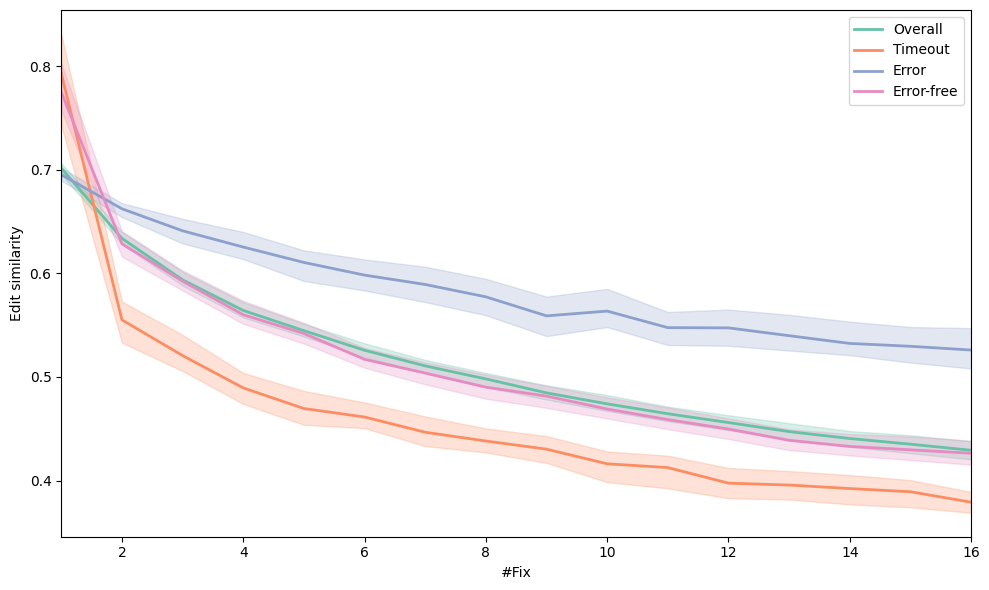

/tmp/ipykernel_3496406/1965290806.py:73: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




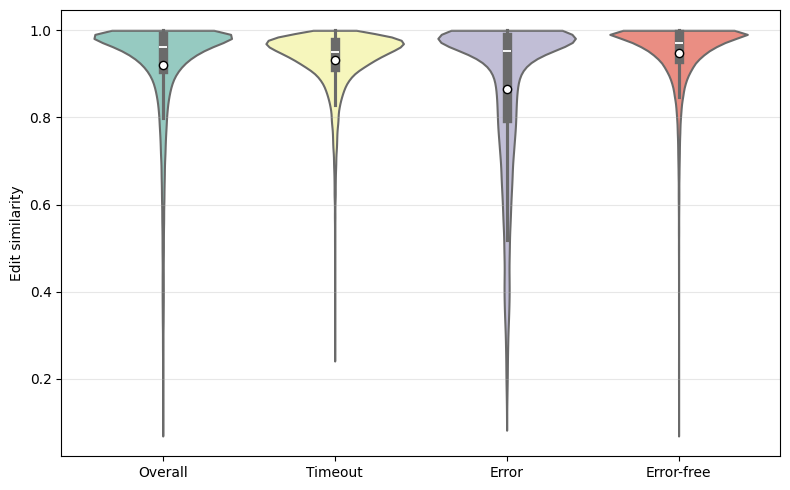

In [40]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import pandas as pd

# -------------------------
# 1) Line chart with band
# -------------------------

groups = {
    "Overall": edit_simi,
    "Timeout": edit_simi_timeout,
    "Error": edit_simi_error,
    "Error-free": edit_simi_error_free,
}

rows = []
for gname, pairs in groups.items():
    for fix, sim in pairs:
        rows.append({"fix": int(fix), "sim": float(sim), "group": gname})
df = pd.DataFrame(rows).sort_values("fix")

order = ["Overall", "Timeout", "Error", "Error-free"]
palette4 = sns.color_palette("Set2", n_colors=len(order))
palette = {k: palette4[i] for i, k in enumerate(order)}

plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=df,
    x="fix",
    y="sim",
    hue="group",
    hue_order=order,
    estimator="median",
    errorbar=("ci", 95),
    n_boot=1000,
    seed=0,
    err_style="band",
    err_kws={"alpha": 0.25},
    linewidth=2,
    palette=palette,
    markersize=4
)

ax.set_xlim(1, 16)
ax.legend(title=None, loc="upper right")
ax.set_xlabel("#Fix")
ax.set_ylabel("Edit similarity")
plt.tight_layout()
plt.savefig("edit_similarity_vs_fix_upgrade_file.png", dpi=600)
plt.show()


# -------------------------
# 2) Violin plot (3 violins)
# -------------------------
# build long-form df
vdf = pd.DataFrame({
    "group": (["Overall"] * len(violin_all)) +
             (["Timeout"] * len(violin_timeout)) +
             (["Error"] * len(violin_error)) +
             (["Error-free"] * len(violin_error_free)),
    "sim": list(map(float, violin_all)) +
           list(map(float, violin_timeout)) +
           list(map(float, violin_error)) +
           list(map(float, violin_error_free)),
})

order = ["Overall", "Timeout", "Error", "Error-free"]

plt.figure(figsize=(8, 5))
ax = sns.violinplot(
    data=vdf,
    x="group",
    y="sim",
    order=order,
    inner="box",     # <- box+whiskers inside violin (like your screenshot)
    cut=0,
    linewidth=1.5,
    density_norm='width',
    palette="Set3",
)

# white dot for mean (like the screenshot)
means = vdf.groupby("group")["sim"].mean().reindex(order).values
ax.scatter(range(len(order)), means, s=35, c="white", edgecolors="black", zorder=3)

ax.set_xlabel("")
ax.set_ylabel("Edit similarity")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("edit_similarity_violin_plot-f.png", dpi=600)
plt.show()


In [43]:
import json
from tqdm import tqdm
import re, os
import Levenshtein

def _drop_hash_comment_lines(src: str) -> str:
    """
    Remove lines that are commented out, e.g. starting with '#'
    (also removes ones with leading whitespace before '#').
    Keeps inline comments like: x = 1  # keep
    """
    kept: list[str] = []
    in_triple = None  # None, "'''", or '"""'

    for line in src.splitlines(True):  # keep newlines
        # naive triple-quote toggle (won't handle all edge cases, but avoids the common ones)
        if in_triple is None:
            if "'''" in line or '"""' in line or '```' in line:
                # enter triple-quote mode if it starts an odd-count triple quote on this line
                if line.count("'''") % 2 == 1:
                    in_triple = "'''"
                elif line.count('"""') % 2 == 1:
                    in_triple = '"""'
        else:
            if line.count(in_triple) % 2 == 1:
                in_triple = None

        if in_triple is None and line.lstrip().startswith("#"):
            continue
        kept.append(line)

    return "".join(kept)

def _normalize_code(nb: str) -> str:
    src = ""
    for i, cell in enumerate(nb.get('cells', [])):
        if cell.get("cell_type") != "code":
            continue
        source = ''.join(cell.get('source', []))
        source = _drop_hash_comment_lines(source)
        if source.strip() == "":
            continue
        src += f"{source}"
    return src

    
def _has_error(nb: str) -> bool:
    for i, cell in enumerate(nb.get('cells', [])):
        if cell.get('cell_type') == 'code':
            for out in cell.get('outputs', []):
                if out.get('output_type') == 'error':
                    return True
    
    return False

def is_replicable(reported_score,measured_score):

    if isinstance(reported_score, float) and isinstance(measured_score, float) and reported_score != 0.0:
        thrus = abs(measured_score-reported_score)/abs(reported_score) * 100
    else:
        thrus = None

    return (thrus is not None) and (thrus <= float(10))


upgrade_type = "oss_file"

with open(f"./results/upgrade/{upgrade_type}/csv_score.json", "r") as f:
    score_content = json.load(f)
with open(f"./results/upgrade/{upgrade_type}/executable_files_w_timer_parrallel.json", "r") as f:
    exec_files = json.load(f)

edit_simi = []
edit_simi_error = []
edit_simi_error_free = []
edit_simi_timeout = []

violin_all = []
violin_error = []
violin_error_free = []
violin_timeout = []



for k, v in tqdm(sorted(score_content.items())):
    fixs = v['fix']
    if v.get('failed', 0) == 1 or fixs == 0:
        continue
    with open(f"./results/baseline/script_out_allINone/{k}", "r") as f:
        baseline_nb = json.load(f)
    for fix in range(1, fixs+1):
        # notebook run in baseline
        if fix == 1:
            prev_exec_time = baseline_exec_files[k]['execution_time']
            prev_error_nb = _has_error(baseline_nb)
            prev_nb = baseline_nb
        else:
            with open(f"./results/upgrade/{upgrade_type}/script_out_allINone/fix_{fix-1}/{k}", "r") as f:
                prev_nb = json.load(f)
            prev_error_nb = _has_error(prev_nb)
            if 'execution_time' not in exec_files[k]['upgrade'][str(fix)]:
                continue
            prev_exec_time = exec_files[k]['upgrade'][str(fix)]['execution_time']
        
        # notebook after fixed 
        with open(f"./results/upgrade/{upgrade_type}/script_out_allINone/fix_{fix}/{k}", "r") as f:
            curr_nb = json.load(f)
        error_nb = _has_error(curr_nb)
        if 'execution_time' not in exec_files[k]['upgrade'][str(fix)]:
            continue
        exec_time = exec_files[k]['upgrade'][str(fix)]['execution_time']

        curr_code = _normalize_code(curr_nb)
        base_code = _normalize_code(baseline_nb)

        score = Levenshtein.ratio(curr_code, base_code)
        edit_simi.append((fix, score))

        if prev_exec_time > 600: # previous state is timeout
            edit_simi_timeout.append((fix, score))

            prev_code = _normalize_code(prev_nb)
            score = Levenshtein.ratio(curr_code, prev_code)
            violin_timeout.append(score)
            violin_all.append(score)
        else:
            if prev_error_nb: # previous state is error non-replicable
                edit_simi_error.append((fix, score))

                prev_code = _normalize_code(prev_nb)
                score = Levenshtein.ratio(curr_code, prev_code)
                violin_error.append(score)
                violin_all.append(score)
            else: # previous state is error-free non-replicable
                edit_simi_error_free.append((fix, score))

                prev_code = _normalize_code(prev_nb)
                score = Levenshtein.ratio(curr_code, prev_code)
                violin_error_free.append(score)
                violin_all.append(score)
len(edit_simi), len(edit_simi_timeout), len(edit_simi_error), len(edit_simi_error_free)

100%|██████████| 8210/8210 [15:44<00:00,  8.70it/s]  


(80899, 15234, 24693, 40972)

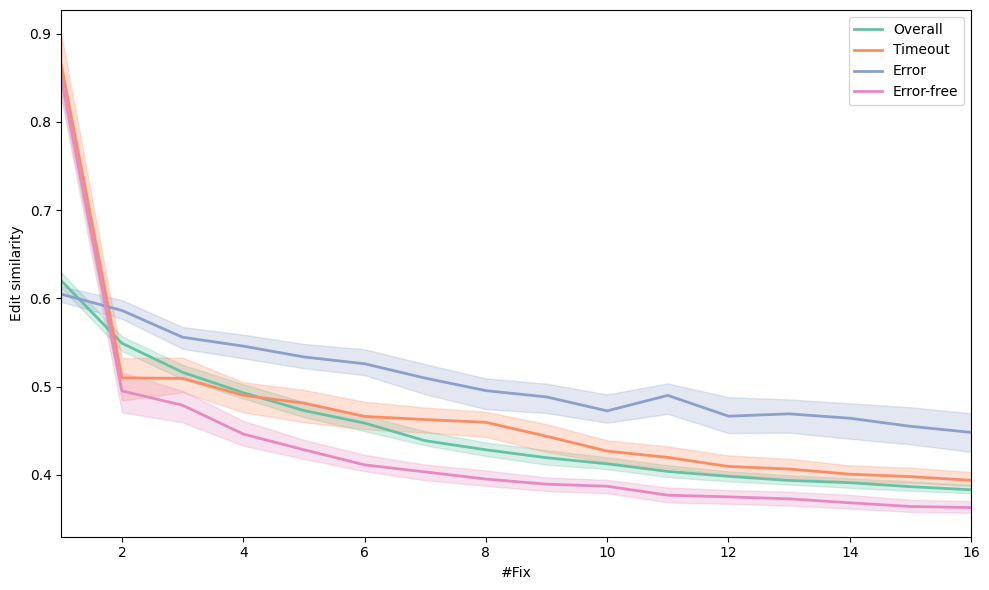

/tmp/ipykernel_3496406/3458633335.py:73: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




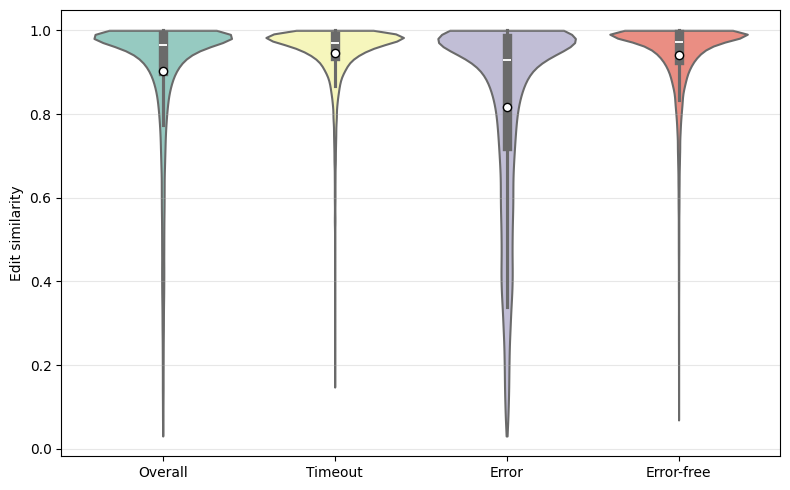

In [44]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import pandas as pd

# -------------------------
# 1) Line chart with band
# -------------------------

groups = {
    "Overall": edit_simi,
    "Timeout": edit_simi_timeout,
    "Error": edit_simi_error,
    "Error-free": edit_simi_error_free,
}

rows = []
for gname, pairs in groups.items():
    for fix, sim in pairs:
        rows.append({"fix": int(fix), "sim": float(sim), "group": gname})
df = pd.DataFrame(rows).sort_values("fix")

order = ["Overall", "Timeout", "Error", "Error-free"]
palette4 = sns.color_palette("Set2", n_colors=len(order))
palette = {k: palette4[i] for i, k in enumerate(order)}

plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=df,
    x="fix",
    y="sim",
    hue="group",
    hue_order=order,
    estimator="median",
    errorbar=("ci", 95),
    n_boot=1000,
    seed=0,
    err_style="band",
    err_kws={"alpha": 0.25},
    linewidth=2,
    palette=palette,
    markersize=4
)

ax.set_xlim(1, 16)
ax.legend(title=None, loc="upper right")
ax.set_xlabel("#Fix")
ax.set_ylabel("Edit similarity")
plt.tight_layout()
plt.savefig("edit_similarity_vs_fix_upgrade_file_oss.png", dpi=600)
plt.show()


# -------------------------
# 2) Violin plot (3 violins)
# -------------------------
# build long-form df
vdf = pd.DataFrame({
    "group": (["Overall"] * len(violin_all)) +
             (["Timeout"] * len(violin_timeout)) +
             (["Error"] * len(violin_error)) +
             (["Error-free"] * len(violin_error_free)),
    "sim": list(map(float, violin_all)) +
           list(map(float, violin_timeout)) +
           list(map(float, violin_error)) +
           list(map(float, violin_error_free)),
})

order = ["Overall", "Timeout", "Error", "Error-free"]

plt.figure(figsize=(8, 5))
ax = sns.violinplot(
    data=vdf,
    x="group",
    y="sim",
    order=order,
    inner="box",     # <- box+whiskers inside violin (like your screenshot)
    cut=0,
    linewidth=1.5,
    density_norm='width',
    palette="Set3",
)

# white dot for mean (like the screenshot)
means = vdf.groupby("group")["sim"].mean().reindex(order).values
ax.scatter(range(len(order)), means, s=35, c="white", edgecolors="black", zorder=3)

ax.set_xlabel("")
ax.set_ylabel("Edit similarity")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("edit_similarity_violin_plot-f_oss.png", dpi=600)
plt.show()


In [57]:
import json
from tqdm import tqdm
from statistics import mean
    
def _has_error(nb: str) -> bool:
    for i, cell in enumerate(nb.get('cells', [])):
        if cell.get('cell_type') == 'code':
            for out in cell.get('outputs', []):
                if out.get('output_type') == 'error':
                    return True
    
    return False

def is_replicable(reported_score,measured_score):

    if isinstance(reported_score, float) and isinstance(measured_score, float) and reported_score != 0.0:
        thrus = abs(measured_score-reported_score)/abs(reported_score) * 100
    else:
        thrus = None

    return (thrus is not None) and (thrus <= float(10))

upgrade_type = "cell"

with open(f"./results/upgrade/{upgrade_type}/csv_score.json", "r") as f:
    score_content = json.load(f)
with open(f"./results/upgrade/{upgrade_type}/executable_files_w_timer_parrallel.json", "r") as f:
    exec_files = json.load(f)
with open("./results/baseline/executable_files_w_timer_parrallel.json", "r") as f:
    baseline_exec_files = json.load(f)


error_fix_input_token = []
error_fix_cached_token = []
error_fix_output_token = []

calibrate_performance_input_token = []
calibrate_performance_cached_token = []
calibrate_performance_output_token = []

reduce_runtime_input_token = []
reduce_runtime_cached_token = []
reduce_runtime_output_token = []

cost = []
input_token = []
cached_token = []
output_token = []

reduce_runtime_cost = []
error_fix_cost = []
calibrate_performance_cost = []

for k, v in tqdm(sorted(score_content.items())):
    fixs = v['fix']
    if v.get('failed', 0) == 1 and fixs == 0:
        continue

    f_input_token = []
    f_cached_token = []
    f_output_token = []
    f_cost = []

    for fix in range(0, fixs):
        # current notebook
        if fix == 0:
            with open(f"./results/baseline/script_out_allINone/{k}", "r") as f:
                curr_nb = json.load(f)
            exec_time = baseline_exec_files[k]['execution_time']
        else:
            with open(f"./results/upgrade/{upgrade_type}/script_out_allINone/fix_{fix}/{k}", "r") as f:
                curr_nb = json.load(f)
            try:
                exec_time = exec_files[k]['upgrade'][str(fix)]['execution_time']
            except KeyError:
                parts = k.split("_")
                compt = parts[0]
                notebook_name = "_".join(parts[1:-2])
                version = parts[-2]
                try:
                    with open(f"/home/b27jin/CodeModernization/results/upgrade/{upgrade_type}/script_out/{compt}/{notebook_name}/{version}/fix_{fix}/result.json", "r") as f:
                        temp_nb = json.load(f)
                    exec_time = temp_nb['execution_time']
                except:
                    exec_time = 0
        error_nb = _has_error(curr_nb)

        fix = fix + 1
        i_tokens = exec_files[k]['upgrade'][str(fix)]['full_message']['usage']['prompt_tokens'] - exec_files[k]['upgrade'][str(fix)]['full_message']['usage']['prompt_tokens_details']['cached_tokens']
        c_token = exec_files[k]['upgrade'][str(fix)]['full_message']['usage']['prompt_tokens_details']['cached_tokens']
        o_token = exec_files[k]['upgrade'][str(fix)]['full_message']['usage']['completion_tokens']
        cost_ = 1.75 * (i_tokens / 1_000_000) + 0.175 * (c_token / 1_000_000) + 14 * (o_token / 1_000_000)
        fix = fix - 1

        f_input_token.append(i_tokens)
        f_cached_token.append(c_token)
        f_output_token.append(o_token)
        f_cost.append(cost_)
        
        if exec_time > 600:
            reduce_runtime_input_token.append(i_tokens)
            reduce_runtime_cached_token.append(c_token)
            reduce_runtime_output_token.append(o_token)
            reduce_runtime_cost.append(cost_)
        else:
            if error_nb:
                error_fix_input_token.append(i_tokens)
                error_fix_cached_token.append(c_token)
                error_fix_output_token.append(o_token)
                error_fix_cost.append(cost_)
            else:
                calibrate_performance_input_token.append(i_tokens)
                calibrate_performance_cached_token.append(c_token)
                calibrate_performance_output_token.append(o_token)
                calibrate_performance_cost.append(cost_)

    if len(f_cost) == 0:
        print(f"Error in {k} fix 1 / {fixs}")
        print(v)
        continue

    cost.append(sum(f_cost))
    input_token.append(sum(f_input_token))
    cached_token.append(sum(f_cached_token))
    output_token.append(sum(f_output_token))

print("===Cell-level upgrade results:===\n")
print(f"Per notebook token usage:")
print(f"Cost: {mean(cost):.4f}, Input (Not cached): {mean(input_token):,.2f}, Input cache: {mean(cached_token):,.2f}, Output: {mean(output_token):,.2f}\n")

print("Per fix type token usage:")
print(f"Error-repair Cost: {mean(error_fix_cost):.4f}, Input (Not cached): {mean(error_fix_input_token):,.2f}, Input cache: {mean(error_fix_cached_token):,.2f}, Output: {mean(error_fix_output_token):,.2f}")
print(f"Calibrate-performance Cost: {mean(calibrate_performance_cost):.4f}, Input (Not cached): {mean(calibrate_performance_input_token):,.2f}, Input cache: {mean(calibrate_performance_cached_token):,.2f}, Output: {mean(calibrate_performance_output_token):,.2f}")
print(f"Reduce-runtime Cost: {mean(reduce_runtime_cost):.4f}, Input (Not cached): {mean(reduce_runtime_input_token):,.2f}, Input cache: {mean(reduce_runtime_cached_token):,.2f}, Output: {mean(reduce_runtime_output_token):,.2f}")

100%|██████████| 6583/6583 [09:14<00:00, 11.88it/s]  


===Cell-level upgrade results:===

Per notebook token usage:
Cost: 0.1967, Input (Not cached): 31,674.66, Input cache: 20,623.25, Output: 9,832.37

Per fix type token usage:
Error-repair Cost: 0.0142, Input (Not cached): 3,354.33, Input cache: 2,166.94, Output: 569.56
Calibrate-performance Cost: 0.0500, Input (Not cached): 4,643.24, Input cache: 3,248.01, Output: 2,948.14
Reduce-runtime Cost: 0.0563, Input (Not cached): 4,203.38, Input cache: 2,067.45, Output: 3,470.44


# Additional studies: relationship btw #fix and file size / loc / #error

In [45]:
import json
import re
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats

def _drop_hash_comment_lines(src: str) -> str:
    """
    Remove lines that are commented out, e.g. starting with '#'
    (also removes ones with leading whitespace before '#').
    Keeps inline comments like: x = 1  # keep
    """
    kept: list[str] = []
    in_triple = None  # None, "'''", or '"""'

    for line in src.splitlines(True):  # keep newlines
        # naive triple-quote toggle (won't handle all edge cases, but avoids the common ones)
        if in_triple is None:
            if "'''" in line or '"""' in line or '```' in line:
                # enter triple-quote mode if it starts an odd-count triple quote on this line
                if line.count("'''") % 2 == 1:
                    in_triple = "'''"
                elif line.count('"""') % 2 == 1:
                    in_triple = '"""'
        else:
            if line.count(in_triple) % 2 == 1:
                in_triple = None

        if in_triple is None and line.lstrip().startswith("#"):
            continue
        kept.append(line)

    return "".join(kept)

def ipynb_code_as_py_text(ipynb_path: str | Path, *, normalize: bool = True) -> str:
    ipynb_path = Path(ipynb_path)
    nb = json.loads(ipynb_path.read_text(encoding="utf-8"))
    cells = nb.get("cells", [])

    chunks: list[str] = []
    for c in cells:
        if c.get("cell_type") != "code":
            continue
        src = c.get("source", "")
        if isinstance(src, list):
            src = "".join(src)
        if not isinstance(src, str):
            continue
        if normalize:
            src = _drop_hash_comment_lines(src)
        if src and not src.endswith("\n"):
            src += "\n"
        chunks.append(src)

    return "\n\n".join(chunks)

def count_loc(py_text: str, *, nonempty_only: bool = True) -> int:
    lines = py_text.splitlines()
    if nonempty_only:
        return sum(1 for ln in lines if ln.strip() != "")
    return len(lines)

def count_error_outputs(ipynb_path: str | Path) -> int:
    ipynb_path = Path(ipynb_path)
    nb = json.loads(ipynb_path.read_text(encoding="utf-8"))
    cells = nb.get("cells", [])

    n_err = 0
    for c in cells:
        if c.get("cell_type") != "code":
            continue
        for out in c.get("outputs", []) or []:
            if isinstance(out, dict) and out.get("output_type") == "error":
                n_err += 1
    return n_err

def notebook_metrics(ipynb_path: str | Path, *, normalize: bool = True) -> dict:
    py_text = ipynb_code_as_py_text(ipynb_path, normalize=normalize)
    py_bytes = len(py_text.encode("utf-8"))
    loc = count_loc(py_text, nonempty_only=True)
    n_errors = count_error_outputs(ipynb_path)
    return {
        "ipynb_path": str(ipynb_path),
        "py_bytes": py_bytes,
        "loc": loc,
        "n_errors": n_errors,
    }


def build_dataframe(fix_map: dict[str, int]) -> pd.DataFrame:
    rows = []
    for fname, fix_num in tqdm(fix_map.items()):
        path = f"./results/baseline/script_out_allINone/{fname}"
        m = notebook_metrics(path)
        m["fix_num"] = int(fix_num)
        rows.append(m)
    df = pd.DataFrame(rows)

    # helpful transforms
    df["log_py_bytes"] = np.log1p(df["py_bytes"])
    df["log_loc"] = np.log1p(df["loc"])
    df["log_errors"] = np.log1p(df["n_errors"])
    df["log_fix"] = np.log1p(df["fix_num"])
    return df

def corr_report(x, y):
    pear = stats.pearsonr(x, y)      # linear
    spear = stats.spearmanr(x, y)    # monotonic (rank)
    kend = stats.kendalltau(x, y)    # monotonic (rank)
    return {
        "pearson_r": pear.statistic, "pearson_p": pear.pvalue,
        "spearman_rho": spear.statistic, "spearman_p": spear.pvalue,
        "kendall_tau": kend.statistic, "kendall_p": kend.pvalue,
    }

def run_correlations(df: pd.DataFrame) -> pd.DataFrame:
    results = []
    pairs = [
        ("fix_num", "py_bytes"),
        ("fix_num", "loc"),
        ("fix_num", "n_errors"),
        # often better-behaved:
        # ("log_fix", "log_py_bytes"),
        # ("log_fix", "log_loc"),
        # ("log_fix", "log_errors"),
    ]
    for a, b in pairs:
        rep = corr_report(df[a], df[b])
        rep["x"] = a
        rep["y"] = b
        rep["n"] = len(df)
        results.append(rep)
    return pd.DataFrame(results)[["n","x","y","pearson_r","pearson_p","spearman_rho","spearman_p","kendall_tau","kendall_p"]]

In [46]:
upgrade_type = "gpt_file"

with open(f"./results/upgrade/{upgrade_type}/executable_files_w_timer_parrallel.json", "r") as f:
    exec_files = json.load(f)

fix_map = {}
for k, v in tqdm(sorted(exec_files.items())):
    if v.get('replicable', False):
        fix_map[k] = v['fix']

df = build_dataframe(fix_map)
# print(df[["ipynb_path","fix_num","py_bytes","loc","n_errors"]].to_string(index=False))

corr_df = run_correlations(df)
print(corr_df.to_string(index=False))

100%|██████████| 3828/3828 [00:18<00:00, 206.68it/s]

   n       x        y  pearson_r    pearson_p  spearman_rho   spearman_p  kendall_tau    kendall_p
3828 fix_num py_bytes   0.145136 1.804468e-19      0.182006 7.237634e-30     0.130480 2.007367e-29
3828 fix_num      loc   0.165870 5.112849e-25      0.180597 2.004151e-29     0.129971 4.234871e-29
3828 fix_num n_errors   0.061558 1.383822e-04      0.137714 1.143397e-17     0.099847 5.240657e-17


In [48]:
import numpy as np
import pandas as pd
from cliffs_delta import cliffs_delta

def cliffs_label(d: float) -> str:
    ad = abs(d)
    if ad < 0.147:
        return "negligible"
    if ad < 0.33:
        return "small"
    if ad < 0.474:
        return "medium"
    return "large"

def cliffs_report(df: pd.DataFrame, metric: str) -> dict:
    # Compare bottom quartile vs top quartile of fix_num (robust default)
    q1 = df["fix_num"].quantile(0.25)
    q3 = df["fix_num"].quantile(0.75)

    low = df.loc[df["fix_num"] <= q1, metric].dropna().to_numpy()
    high = df.loc[df["fix_num"] >= q3, metric].dropna().to_numpy()

    d, res = cliffs_delta(low, high)  # d in [-1, 1]
    return {
        "metric": metric,
        "n_low": int(low.size),
        "n_high": int(high.size),
        "q1_fix_num": float(q1),
        "q3_fix_num": float(q3),
        "cliffs_delta": float(d),
        "magnitude": cliffs_label(float(d)),
        "low_median": float(np.median(low)) if low.size else np.nan,
        "high_median": float(np.median(high)) if high.size else np.nan,
    }

metrics = ["py_bytes", "loc", "n_errors"]
rows = [cliffs_report(df, m) for m in metrics]
eff = pd.DataFrame(rows)

print(eff.to_string(index=False))


  metric  n_low  n_high  q1_fix_num  q3_fix_num  cliffs_delta  magnitude  low_median  high_median
py_bytes   1770     983         1.0         5.0     -0.239649      small      4211.5       5879.0
     loc   1770     983         1.0         5.0     -0.237921      small        99.0        135.0
n_errors   1770     983         1.0         5.0     -0.068557 negligible         6.0          6.0


# Additional studies: error rep

In [49]:
import json
import re
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats

def _drop_hash_comment_lines(src: str) -> str:
    """
    Remove lines that are commented out, e.g. starting with '#'
    (also removes ones with leading whitespace before '#').
    Keeps inline comments like: x = 1  # keep
    """
    kept: list[str] = []
    in_triple = None  # None, "'''", or '"""'

    for line in src.splitlines(True):  # keep newlines
        # naive triple-quote toggle (won't handle all edge cases, but avoids the common ones)
        if in_triple is None:
            if "'''" in line or '"""' in line or '```' in line:
                # enter triple-quote mode if it starts an odd-count triple quote on this line
                if line.count("'''") % 2 == 1:
                    in_triple = "'''"
                elif line.count('"""') % 2 == 1:
                    in_triple = '"""'
        else:
            if line.count(in_triple) % 2 == 1:
                in_triple = None

        if in_triple is None and line.lstrip().startswith("#"):
            continue
        kept.append(line)

    return "".join(kept)

def ipynb_code_as_py_text(ipynb_path: str | Path, *, normalize: bool = True) -> str:
    ipynb_path = Path(ipynb_path)
    nb = json.loads(ipynb_path.read_text(encoding="utf-8"))
    cells = nb.get("cells", [])

    chunks: list[str] = []
    for c in cells:
        if c.get("cell_type") != "code":
            continue
        src = c.get("source", "")
        if isinstance(src, list):
            src = "".join(src)
        if not isinstance(src, str):
            continue
        if normalize:
            src = _drop_hash_comment_lines(src)
        if src and not src.endswith("\n"):
            src += "\n"
        chunks.append(src)

    return "\n\n".join(chunks)

def count_loc(py_text: str, *, nonempty_only: bool = True) -> int:
    lines = py_text.splitlines()
    if nonempty_only:
        return sum(1 for ln in lines if ln.strip() != "")
    return len(lines)

def count_error_outputs(ipynb_path: str | Path) -> int:
    ipynb_path = Path(ipynb_path)
    nb = json.loads(ipynb_path.read_text(encoding="utf-8"))
    cells = nb.get("cells", [])

    n_err = 0
    for c in cells:
        if c.get("cell_type") != "code":
            continue
        for out in c.get("outputs", []) or []:
            if isinstance(out, dict) and out.get("output_type") == "error":
                n_err += 1
    return n_err

def notebook_metrics(ipynb_path: str | Path, *, normalize: bool = True) -> dict:
    py_text = ipynb_code_as_py_text(ipynb_path, normalize=normalize)
    py_bytes = len(py_text.encode("utf-8"))
    loc = count_loc(py_text, nonempty_only=True)
    n_errors = count_error_outputs(ipynb_path)        
    return {
        "ipynb_path": str(ipynb_path),
        "py_bytes": py_bytes,
        "loc": loc,
        "n_errors": n_errors,
    }


def build_dataframe(fix_map: dict[str, int]) -> pd.DataFrame:
    rows = []
    for fname, fix_num in tqdm(fix_map.items()):
        path = f"./results/baseline/script_out_allINone/{fname}"
        m = notebook_metrics(path)
        if m["n_errors"] is None or m["n_errors"] == 0:
            continue
        m["fix_num"] = int(fix_num)
        rows.append(m)
    df = pd.DataFrame(rows)

    # helpful transforms
    df["log_py_bytes"] = np.log1p(df["py_bytes"])
    df["log_loc"] = np.log1p(df["loc"])
    df["log_errors"] = np.log1p(df["n_errors"])
    df["log_fix"] = np.log1p(df["fix_num"])
    return df

def corr_report(x, y):
    pear = stats.pearsonr(x, y)      # linear
    spear = stats.spearmanr(x, y)    # monotonic (rank)
    kend = stats.kendalltau(x, y)    # monotonic (rank)
    return {
        "pearson_r": pear.statistic, "pearson_p": pear.pvalue,
        "spearman_rho": spear.statistic, "spearman_p": spear.pvalue,
        "kendall_tau": kend.statistic, "kendall_p": kend.pvalue,
    }

def run_correlations(df: pd.DataFrame) -> pd.DataFrame:
    results = []
    pairs = [
        ("fix_num", "py_bytes"),
        ("fix_num", "loc"),
        ("fix_num", "n_errors"),
        # often better-behaved:
        # ("log_fix", "log_py_bytes"),
        # ("log_fix", "log_loc"),
        # ("log_fix", "log_errors"),
    ]
    for a, b in pairs:
        rep = corr_report(df[a], df[b])
        rep["x"] = a
        rep["y"] = b
        rep["n"] = len(df)
        results.append(rep)
    return pd.DataFrame(results)[["n","x","y","pearson_r","pearson_p","spearman_rho","spearman_p","kendall_tau","kendall_p"]]

upgrade_type = "gpt_file"

with open(f"./results/upgrade/{upgrade_type}/executable_files_w_timer_parrallel.json", "r") as f:
    exec_files = json.load(f)

fix_map = {}
for k, v in tqdm(sorted(exec_files.items())):
    if v.get('replicable', False):
        fix_map[k] = v['fix']

df = build_dataframe(fix_map)
# print(df[["ipynb_path","fix_num","py_bytes","loc","n_errors"]].to_string(index=False))

corr_df = run_correlations(df)
print(corr_df.to_string(index=False))

import numpy as np
import pandas as pd
from cliffs_delta import cliffs_delta

def cliffs_label(d: float) -> str:
    ad = abs(d)
    if ad < 0.147:
        return "negligible"
    if ad < 0.33:
        return "small"
    if ad < 0.474:
        return "medium"
    return "large"

def cliffs_report(df: pd.DataFrame, metric: str) -> dict:
    # Compare bottom quartile vs top quartile of fix_num (robust default)
    q1 = df["fix_num"].quantile(0.25)
    q3 = df["fix_num"].quantile(0.75)

    low = df.loc[df["fix_num"] <= q1, metric].dropna().to_numpy()
    high = df.loc[df["fix_num"] >= q3, metric].dropna().to_numpy()

    d, res = cliffs_delta(low, high)  # d in [-1, 1]
    return {
        "metric": metric,
        "n_low": int(low.size),
        "n_high": int(high.size),
        "q1_fix_num": float(q1),
        "q3_fix_num": float(q3),
        "cliffs_delta": float(d),
        "magnitude": cliffs_label(float(d)),
        "low_median": float(np.median(low)) if low.size else np.nan,
        "high_median": float(np.median(high)) if high.size else np.nan,
    }

metrics = ["py_bytes", "loc", "n_errors"]
rows = [cliffs_report(df, m) for m in metrics]
eff = pd.DataFrame(rows)

print(eff.to_string(index=False))


100%|██████████| 3828/3828 [00:23<00:00, 166.03it/s]

   n       x        y  pearson_r    pearson_p  spearman_rho   spearman_p  kendall_tau    kendall_p
3349 fix_num py_bytes   0.131795 1.893988e-14      0.156562 7.999337e-20     0.112451 1.302926e-19
3349 fix_num      loc   0.154302 2.706693e-19      0.156189 9.795454e-20     0.112696 1.283214e-19
3349 fix_num n_errors  -0.000703 9.675473e-01     -0.010914 5.278026e-01    -0.006758 5.961574e-01
  metric  n_low  n_high  q1_fix_num  q3_fix_num  cliffs_delta  magnitude  low_median  high_median
py_bytes   1431     915         1.0         5.0     -0.207556      small      4487.0       6116.0
     loc   1431     915         1.0         5.0     -0.206551      small       105.0        138.0
n_errors   1431     915         1.0         5.0      0.071480 negligible         8.0          7.0


# Additional studies: error-free rep

In [50]:
import json
import re
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats

def _drop_hash_comment_lines(src: str) -> str:
    """
    Remove lines that are commented out, e.g. starting with '#'
    (also removes ones with leading whitespace before '#').
    Keeps inline comments like: x = 1  # keep
    """
    kept: list[str] = []
    in_triple = None  # None, "'''", or '"""'

    for line in src.splitlines(True):  # keep newlines
        # naive triple-quote toggle (won't handle all edge cases, but avoids the common ones)
        if in_triple is None:
            if "'''" in line or '"""' in line or '```' in line:
                # enter triple-quote mode if it starts an odd-count triple quote on this line
                if line.count("'''") % 2 == 1:
                    in_triple = "'''"
                elif line.count('"""') % 2 == 1:
                    in_triple = '"""'
        else:
            if line.count(in_triple) % 2 == 1:
                in_triple = None

        if in_triple is None and line.lstrip().startswith("#"):
            continue
        kept.append(line)

    return "".join(kept)

def ipynb_code_as_py_text(ipynb_path: str | Path, *, normalize: bool = True) -> str:
    ipynb_path = Path(ipynb_path)
    nb = json.loads(ipynb_path.read_text(encoding="utf-8"))
    cells = nb.get("cells", [])

    chunks: list[str] = []
    for c in cells:
        if c.get("cell_type") != "code":
            continue
        src = c.get("source", "")
        if isinstance(src, list):
            src = "".join(src)
        if not isinstance(src, str):
            continue
        if normalize:
            src = _drop_hash_comment_lines(src)
        if src and not src.endswith("\n"):
            src += "\n"
        chunks.append(src)

    return "\n\n".join(chunks)

def count_loc(py_text: str, *, nonempty_only: bool = True) -> int:
    lines = py_text.splitlines()
    if nonempty_only:
        return sum(1 for ln in lines if ln.strip() != "")
    return len(lines)

def count_error_outputs(ipynb_path: str | Path) -> int:
    ipynb_path = Path(ipynb_path)
    nb = json.loads(ipynb_path.read_text(encoding="utf-8"))
    cells = nb.get("cells", [])

    n_err = 0
    for c in cells:
        if c.get("cell_type") != "code":
            continue
        for out in c.get("outputs", []) or []:
            if isinstance(out, dict) and out.get("output_type") == "error":
                n_err += 1
    return n_err

def notebook_metrics(ipynb_path: str | Path, *, normalize: bool = True) -> dict:
    py_text = ipynb_code_as_py_text(ipynb_path, normalize=normalize)
    py_bytes = len(py_text.encode("utf-8"))
    loc = count_loc(py_text, nonempty_only=True)
    n_errors = count_error_outputs(ipynb_path)        
    return {
        "ipynb_path": str(ipynb_path),
        "py_bytes": py_bytes,
        "loc": loc,
        "n_errors": n_errors,
    }


def build_dataframe(fix_map: dict[str, int]) -> pd.DataFrame:
    rows = []
    for fname, fix_num in tqdm(fix_map.items()):
        path = f"./results/baseline/script_out_allINone/{fname}"
        m = notebook_metrics(path)
        if m["n_errors"] > 0:
            continue
        m["fix_num"] = int(fix_num)
        rows.append(m)
    df = pd.DataFrame(rows)

    # helpful transforms
    df["log_py_bytes"] = np.log1p(df["py_bytes"])
    df["log_loc"] = np.log1p(df["loc"])
    df["log_errors"] = np.log1p(df["n_errors"])
    df["log_fix"] = np.log1p(df["fix_num"])
    return df

def corr_report(x, y):
    pear = stats.pearsonr(x, y)      # linear
    spear = stats.spearmanr(x, y)    # monotonic (rank)
    kend = stats.kendalltau(x, y)    # monotonic (rank)
    return {
        "pearson_r": pear.statistic, "pearson_p": pear.pvalue,
        "spearman_rho": spear.statistic, "spearman_p": spear.pvalue,
        "kendall_tau": kend.statistic, "kendall_p": kend.pvalue,
    }

def run_correlations(df: pd.DataFrame) -> pd.DataFrame:
    results = []
    pairs = [
        ("fix_num", "py_bytes"),
        ("fix_num", "loc"),
        # ("fix_num", "n_errors"),
        # often better-behaved:
        # ("log_fix", "log_py_bytes"),
        # ("log_fix", "log_loc"),
        # ("log_fix", "log_errors"),
    ]
    for a, b in pairs:
        rep = corr_report(df[a], df[b])
        rep["x"] = a
        rep["y"] = b
        rep["n"] = len(df)
        results.append(rep)
    return pd.DataFrame(results)[["n","x","y","pearson_r","pearson_p","spearman_rho","spearman_p","kendall_tau","kendall_p"]]

upgrade_type = "oss_file"

with open(f"./results/upgrade/{upgrade_type}/executable_files_w_timer_parrallel.json", "r") as f:
    exec_files = json.load(f)

fix_map = {}
for k, v in tqdm(sorted(exec_files.items())):
    if v.get('replicable', False):
        fix_map[k] = v['fix']

df = build_dataframe(fix_map)
# print(df[["ipynb_path","fix_num","py_bytes","loc","n_errors"]].to_string(index=False))

corr_df = run_correlations(df)
print(corr_df.to_string(index=False))

import numpy as np
import pandas as pd
from cliffs_delta import cliffs_delta

def cliffs_label(d: float) -> str:
    ad = abs(d)
    if ad < 0.147:
        return "negligible"
    if ad < 0.33:
        return "small"
    if ad < 0.474:
        return "medium"
    return "large"

def cliffs_report(df: pd.DataFrame, metric: str) -> dict:
    # Compare bottom quartile vs top quartile of fix_num (robust default)
    q1 = df["fix_num"].quantile(0.25)
    q3 = df["fix_num"].quantile(0.75)

    low = df.loc[df["fix_num"] <= q1, metric].dropna().to_numpy()
    high = df.loc[df["fix_num"] >= q3, metric].dropna().to_numpy()

    d, res = cliffs_delta(low, high)  # d in [-1, 1]
    return {
        "metric": metric,
        "n_low": int(low.size),
        "n_high": int(high.size),
        "q1_fix_num": float(q1),
        "q3_fix_num": float(q3),
        "cliffs_delta": float(d),
        "magnitude": cliffs_label(float(d)),
        "low_median": float(np.median(low)) if low.size else np.nan,
        "high_median": float(np.median(high)) if high.size else np.nan,
    }

metrics = ["py_bytes", "loc"]
rows = [cliffs_report(df, m) for m in metrics]
eff = pd.DataFrame(rows)

print(eff.to_string(index=False))


100%|██████████| 3998/3998 [00:20<00:00, 191.22it/s]

  n       x        y  pearson_r  pearson_p  spearman_rho  spearman_p  kendall_tau  kendall_p
419 fix_num py_bytes   0.093343   0.056244      0.025216    0.606768     0.010848   0.760675
419 fix_num      loc   0.091813   0.060421      0.023223    0.635490     0.010271   0.773792
  metric  n_low  n_high  q1_fix_num  q3_fix_num  cliffs_delta  magnitude  low_median  high_median
py_bytes    142     112         0.0         4.0     -0.005030 negligible      3310.0       4014.0
     loc    142     112         0.0         4.0      0.001069 negligible        77.0         90.0


# RQ5: crash type analysis

## GPT

Top 5 crashes in baseline:
  NameError: 51772
  AttributeError: 19923
  ValueError: 9316
  KeyError: 2773
  TypeError: 2407
  Others: 6595

Crash counts at fix #16:
  NameError: 498
  AttributeError: 3265
  ValueError: 103
  KeyError: 27
  TypeError: 96
  Others: 194


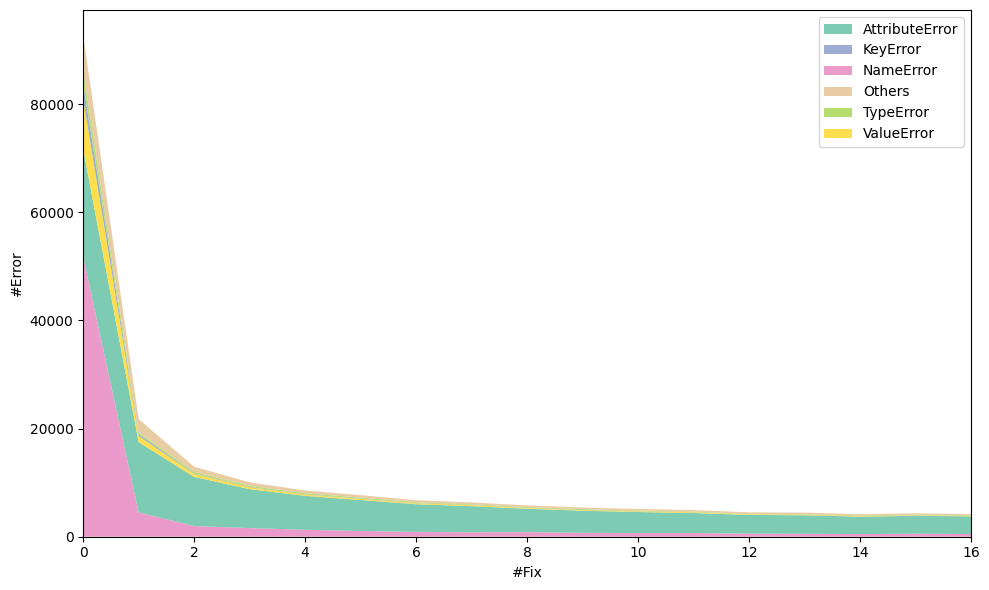

Keep in ER (>=2%):
  AttributeError: 4247 (93.46%)
  Others: 297 (6.54%)
Keep in ENR (>=2%):
  AttributeError: 3249 (78.16%)
  NameError: 496 (11.93%)
  ValueError: 103 (2.48%)
  TypeError: 95 (2.29%)
  Others: 214 (5.15%)


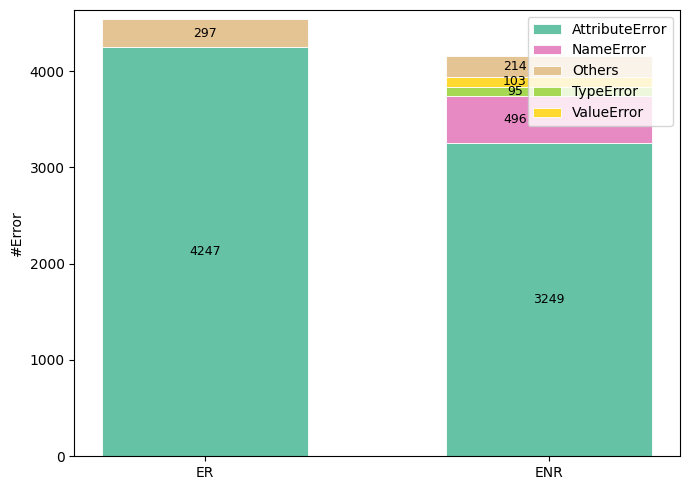

In [10]:
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

with open("./crash_report/crash_report_baseline.json", 'r') as f:
    baseline_crash = json.load(f)

top_5_crashes = dict(sorted(baseline_crash['counts']['exception_type'].items(), key=lambda item: item[1], reverse=True)[:5])
series = {k: [v] for k,v in top_5_crashes.items()}

baseline_ex_counts = baseline_crash.get("counts", {}).get("exception_type", {})
baseline_total = sum(baseline_ex_counts.values())
baseline_top5_total = sum(top_5_crashes.values())
series["Others"] = [baseline_total - baseline_top5_total]

print("Top 5 crashes in baseline:")
for k, v in top_5_crashes.items():
    print(f"  {k}: {v}")
print(f"  Others: {series['Others'][0]}")
top_5_crashes = list(top_5_crashes.keys())

# --------- Build shared color map (same type = same color) ----------
THRESH = 0.02  # 2%

def compress_counts(counts: dict, thresh: float):
    total = sum(counts.values())
    keep = {
        exception_type
        for exception_type, count in counts.items()
        if total > 0 and count / total >= thresh
    }
    kept_counts = {
        exception_type: counts.get(exception_type, 0)
        for exception_type in keep
    }
    kept_counts["Others"] = total - sum(kept_counts.values())
    return kept_counts, total, keep

def load_exception_counts(path):
    with open(path, "r", encoding="utf-8") as f:
        report = json.load(f)
    return report.get("counts", {}).get("exception_type", {})

# Load all datasets that may contribute legend categories.
gpt_er_ex_counts = load_exception_counts(
    "./crash_report/crash_report_upgrade_gpt_file-ER.json"
)
gpt_enr_ex_counts = load_exception_counts(
    "./crash_report/crash_report_upgrade_gpt_file-ENR.json"
)
oss_er_ex_counts = load_exception_counts(
    "./crash_report/crash_report_upgrade_oss_file-ER.json"
)
oss_enr_ex_counts = load_exception_counts(
    "./crash_report/crash_report_upgrade_oss_file-ENR.json"
)

_, _, gpt_er_keep = compress_counts(gpt_er_ex_counts, THRESH)
_, _, gpt_enr_keep = compress_counts(gpt_enr_ex_counts, THRESH)
_, _, oss_er_keep = compress_counts(oss_er_ex_counts, THRESH)
_, _, oss_enr_keep = compress_counts(oss_enr_ex_counts, THRESH)

# Build one shared color map for all four plots.
global_types = sorted(
    set(top_5_crashes)
    | set(gpt_er_keep)
    | set(gpt_enr_keep)
    | set(oss_er_keep)
    | set(oss_enr_keep)
)

# Keep "Others" in a fixed final position.
global_types = [
    exception_type
    for exception_type in global_types
    if exception_type != "Others"
]
global_types.append("Others")

palette = sns.color_palette(
    "Set2",
    n_colors=len(global_types),
)

color_map = dict(zip(global_types, palette))

er_ex_counts = gpt_er_ex_counts
enr_ex_counts = gpt_enr_ex_counts

# Apply >=2% rule per bar
er_counts2, er_total, er_keep = compress_counts(er_ex_counts, THRESH)
enr_counts2, enr_total, enr_keep = compress_counts(enr_ex_counts, THRESH)

# # Shared type order for both figures (alphabetical)
# master_types = sorted(set(top_5_crashes) | {"Others"} | set(er_keep) | set(enr_keep))

# palette = sns.color_palette("Set2", n_colors=7)
# color_map = {t: palette[i % len(palette)] for i, t in enumerate(master_types)}

fix_nums = list(range(0, 17))

for i in fix_nums:
    if i == 0:
        continue
    with open(f"./crash_report/crash_report_upgrade_gpt_file-{i}.json", 'r') as f:
        fix_crash = json.load(f)

    ex_counts = fix_crash.get("counts", {}).get("exception_type", {})
    for k in top_5_crashes:
        series[k].append(ex_counts.get(k, 0))

    # others = total - sum(top5)
    total_i = sum(ex_counts.values())
    top5_i = sum(ex_counts.get(k, 0) for k in top_5_crashes)
    series["Others"].append(total_i - top5_i)
    
    if i == 16:
        print("\nCrash counts at fix #16:")
        for k in top_5_crashes:
            print(f"  {k}: {ex_counts.get(k, 0)}")
        print(f"  Others: {total_i - top5_i}")

# Stackplot (Top-5 baseline across fixes)
ys = [series[k] for k in top_5_crashes] + [series["Others"]]
labels = top_5_crashes + ["Others"]
colors = [
    color_map[exception_type]
    for exception_type in labels
]

plt.figure(figsize=(10, 6))
plt.stackplot(fix_nums, ys, labels=labels, colors=colors, alpha=0.85)
plt.xlim(0, 16)
plt.xlabel("#Fix")
plt.ylabel("#Error")
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
order = np.argsort(labels)
ax.legend([handles[i] for i in order], [labels[i] for i in order], loc="upper right")
plt.tight_layout()
plt.savefig("top5_crash_types_stackplot_upgrade_gpt_file.png", dpi=600)
plt.show()

# --------- Stacked bars (ER vs ENR) ----------
print("Keep in ER (>=2%):")
for k in sorted([k for k in er_keep], key=lambda x: er_counts2[x], reverse=True):
    print(f"  {k}: {er_counts2[k]} ({er_counts2[k]/er_total:.2%})")
print(f"  Others: {er_counts2['Others']} ({er_counts2['Others']/er_total:.2%})")

print("Keep in ENR (>=2%):")
for k in sorted([k for k in enr_keep], key=lambda x: enr_counts2[x], reverse=True):
    print(f"  {k}: {enr_counts2[k]} ({enr_counts2[k]/enr_total:.2%})")
print(f"  Others: {enr_counts2['Others']} ({enr_counts2['Others']/enr_total:.2%})")

# Union of kept types across both bars, plus Others (use shared ordering)
displayed_types = (
    set(er_keep)
    | set(enr_keep)
    | {"Others"}
)
all_types = [
    exception_type
    for exception_type in global_types
    if exception_type in displayed_types
]
# all_types = [t for t in master_types if t in (set(er_keep) | set(enr_keep) | {"Others"})]

labels = ["ER", "ENR"]
x = np.arange(len(labels))
width = 0.6
bottom = np.zeros(len(labels))

fig, ax = plt.subplots(figsize=(7, 5))

for t in all_types:
    vals = np.array(
        [
            er_counts2.get(t, 0),
            enr_counts2.get(t, 0),
        ],
        dtype=float,
    )

    ax.bar(
        x,
        vals,
        width,
        bottom=bottom,
        color=color_map[t],
        label=t,
        edgecolor="white",
        linewidth=0.6,
    )

    for i, v in enumerate(vals):
        if v <= 0:
            continue

        y = bottom[i] + v / 2

        # Keep the large AttributeError label centered.
        # Move the other ENR labels slightly left to avoid the legend.
        if i == 1 and t != "AttributeError":
            text_x = x[i] - 0.10
        else:
            text_x = x[i]

        # Preserve your special vertical adjustment.
        dy = 40 if (i == 1 and int(v) == 58) else 0

        ax.text(
            text_x,
            y + dy,
            f"{int(v)}",
            ha="center",
            va="center",
            fontsize=9,
        )

    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("#Error")
ax.set_ylim(0, bottom.max() * 1.02)

handles, labels = ax.get_legend_handles_labels()
order = np.argsort(labels)
ax.legend([handles[i] for i in order], [labels[i] for i in order], title=None, bbox_to_anchor=(1.0, 1), loc="upper right")

plt.tight_layout()
plt.savefig("crash_types_bar_upgrade_gpt_file.png", dpi=600)
plt.show()

## GPT-OSS

Top 5 crashes in baseline:
  NameError: 51772
  AttributeError: 19923
  ValueError: 9316
  KeyError: 2773
  TypeError: 2407
  Others: 6595

Crash counts at fix #16:
  NameError: 965
  AttributeError: 1261
  ValueError: 87
  KeyError: 22
  TypeError: 76
  Others: 241


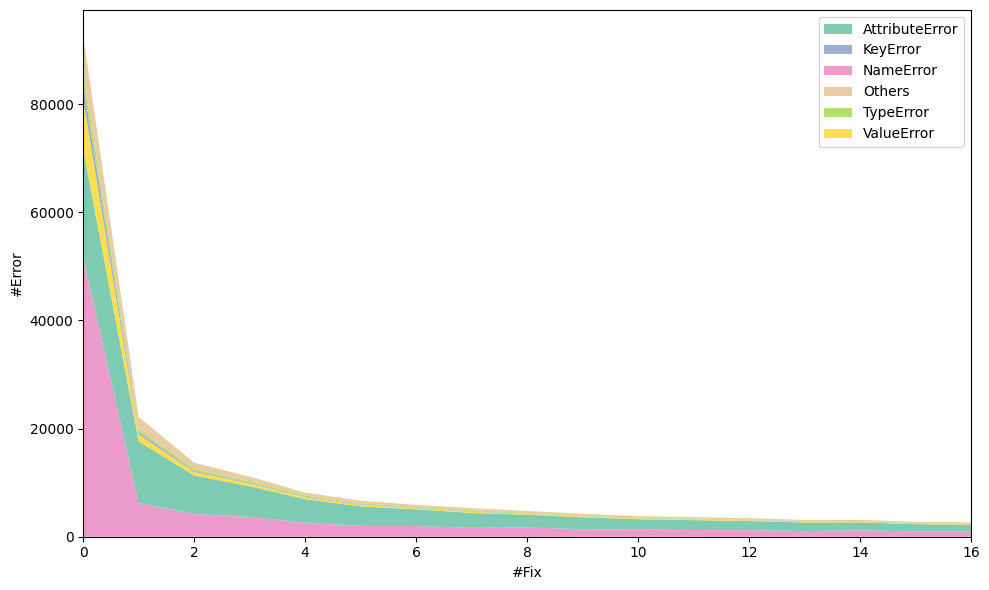

Keep in ER (>=2%):
  AttributeError: 3752 (93.17%)
  NameError: 122 (3.03%)
  Others: 153 (3.80%)
Keep in ENR (>=2%):
  AttributeError: 1235 (47.19%)
  NameError: 961 (36.72%)
  FileNotFoundError: 99 (3.78%)
  ValueError: 87 (3.32%)
  TypeError: 74 (2.83%)
  Others: 161 (6.15%)


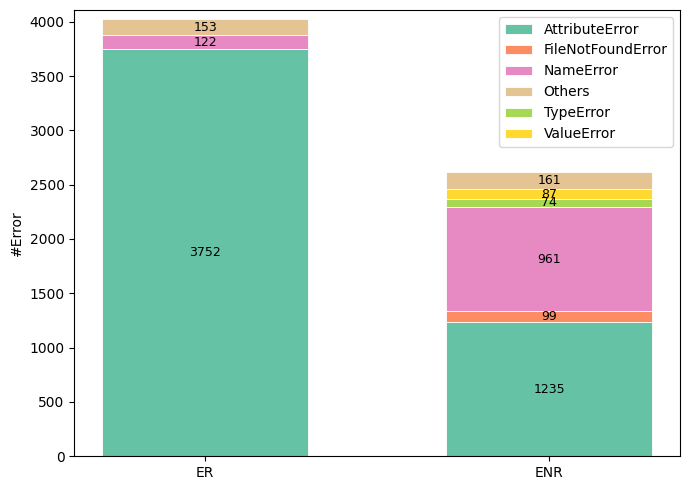

In [8]:
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

with open("./crash_report/crash_report_baseline.json", 'r') as f:
    baseline_crash = json.load(f)

top_5_crashes = dict(sorted(baseline_crash['counts']['exception_type'].items(), key=lambda item: item[1], reverse=True)[:5])
series = {k: [v] for k,v in top_5_crashes.items()}

baseline_ex_counts = baseline_crash.get("counts", {}).get("exception_type", {})
baseline_total = sum(baseline_ex_counts.values())
baseline_top5_total = sum(top_5_crashes.values())
series["Others"] = [baseline_total - baseline_top5_total]

print("Top 5 crashes in baseline:")
for k, v in top_5_crashes.items():
    print(f"  {k}: {v}")
print(f"  Others: {series['Others'][0]}")
top_5_crashes = list(top_5_crashes.keys())

# --------- Build shared color map (same type = same color) ----------
THRESH = 0.02  # 2%

def compress_counts(counts: dict, thresh: float):
    total = sum(counts.values())
    keep = {
        exception_type
        for exception_type, count in counts.items()
        if total > 0 and count / total >= thresh
    }
    kept_counts = {
        exception_type: counts.get(exception_type, 0)
        for exception_type in keep
    }
    kept_counts["Others"] = total - sum(kept_counts.values())
    return kept_counts, total, keep

def load_exception_counts(path):
    with open(path, "r", encoding="utf-8") as f:
        report = json.load(f)
    return report.get("counts", {}).get("exception_type", {})

# Load all datasets that may contribute legend categories.
gpt_er_ex_counts = load_exception_counts(
    "./crash_report/crash_report_upgrade_gpt_file-ER.json"
)
gpt_enr_ex_counts = load_exception_counts(
    "./crash_report/crash_report_upgrade_gpt_file-ENR.json"
)
oss_er_ex_counts = load_exception_counts(
    "./crash_report/crash_report_upgrade_oss_file-ER.json"
)
oss_enr_ex_counts = load_exception_counts(
    "./crash_report/crash_report_upgrade_oss_file-ENR.json"
)

_, _, gpt_er_keep = compress_counts(gpt_er_ex_counts, THRESH)
_, _, gpt_enr_keep = compress_counts(gpt_enr_ex_counts, THRESH)
_, _, oss_er_keep = compress_counts(oss_er_ex_counts, THRESH)
_, _, oss_enr_keep = compress_counts(oss_enr_ex_counts, THRESH)

# Build one shared color map for all four plots.
global_types = sorted(
    set(top_5_crashes)
    | set(gpt_er_keep)
    | set(gpt_enr_keep)
    | set(oss_er_keep)
    | set(oss_enr_keep)
)

# Keep "Others" in a fixed final position.
global_types = [
    exception_type
    for exception_type in global_types
    if exception_type != "Others"
]
global_types.append("Others")

# Generate enough distinct colors; do not use modulo.
palette = sns.color_palette(
    "Set2",
    n_colors=len(global_types),
)

color_map = dict(zip(global_types, palette))

er_ex_counts = oss_er_ex_counts
enr_ex_counts = oss_enr_ex_counts

# Apply >=2% rule per bar
er_counts2, er_total, er_keep = compress_counts(er_ex_counts, THRESH)
enr_counts2, enr_total, enr_keep = compress_counts(enr_ex_counts, THRESH)

# # Shared type order for both figures (alphabetical)
# master_types = sorted(set(top_5_crashes) | {"Others"} | set(er_keep) | set(enr_keep))

# palette = sns.color_palette("Set2", n_colors=7)
# color_map = {t: palette[i % len(palette)] for i, t in enumerate(master_types)}

fix_nums = list(range(0, 17))

for i in fix_nums:
    if i == 0:
        continue
    with open(f"./crash_report/crash_report_upgrade_oss_file-{i}.json", 'r') as f:
        fix_crash = json.load(f)

    ex_counts = fix_crash.get("counts", {}).get("exception_type", {})
    for k in top_5_crashes:
        series[k].append(ex_counts.get(k, 0))

    # others = total - sum(top5)
    total_i = sum(ex_counts.values())
    top5_i = sum(ex_counts.get(k, 0) for k in top_5_crashes)
    series["Others"].append(total_i - top5_i)
    
    if i == 16:
        print("\nCrash counts at fix #16:")
        for k in top_5_crashes:
            print(f"  {k}: {ex_counts.get(k, 0)}")
        print(f"  Others: {total_i - top5_i}")

# Stackplot (Top-5 baseline across fixes)
ys = [series[k] for k in top_5_crashes] + [series["Others"]]
labels = top_5_crashes + ["Others"]
colors = [
    color_map[exception_type]
    for exception_type in labels
]

plt.figure(figsize=(10, 6))
plt.stackplot(fix_nums, ys, labels=labels, colors=colors, alpha=0.85)
plt.xlim(0, 16)
plt.xlabel("#Fix")
plt.ylabel("#Error")
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
order = np.argsort(labels)
ax.legend([handles[i] for i in order], [labels[i] for i in order], loc="upper right")
plt.tight_layout()
plt.savefig("top5_crash_types_stackplot_upgrade_oss_file.png", dpi=600)
plt.show()

# --------- Stacked bars (ER vs ENR) ----------
print("Keep in ER (>=2%):")
for k in sorted([k for k in er_keep], key=lambda x: er_counts2[x], reverse=True):
    print(f"  {k}: {er_counts2[k]} ({er_counts2[k]/er_total:.2%})")
print(f"  Others: {er_counts2['Others']} ({er_counts2['Others']/er_total:.2%})")

print("Keep in ENR (>=2%):")
for k in sorted([k for k in enr_keep], key=lambda x: enr_counts2[x], reverse=True):
    print(f"  {k}: {enr_counts2[k]} ({enr_counts2[k]/enr_total:.2%})")
print(f"  Others: {enr_counts2['Others']} ({enr_counts2['Others']/enr_total:.2%})")

# Union of kept types across both bars, plus Others (use shared ordering)
displayed_types = (
    set(er_keep)
    | set(enr_keep)
    | {"Others"}
)
all_types = [
    exception_type
    for exception_type in global_types
    if exception_type in displayed_types
]
# all_types = [t for t in master_types if t in (set(er_keep) | set(enr_keep) | {"Others"})]

labels = ["ER", "ENR"]
x = np.arange(len(labels))
width = 0.6
bottom = np.zeros(len(labels))

fig, ax = plt.subplots(figsize=(7, 5))

for t in all_types:
    vals = np.array([er_counts2.get(t, 0), enr_counts2.get(t, 0)], dtype=float)
    ax.bar(x, vals, width, bottom=bottom, color=color_map[t], label=t, edgecolor="white", linewidth=0.6)

    for i, v in enumerate(vals):
        if v > 0:
            y = bottom[i] + v / 2
            dy = 40 if (i == 1 and int(v) == 58) else 0
            ax.text(x[i], y + dy, f"{int(v)}", ha="center", va="center", fontsize=9)

    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("#Error")
ax.set_ylim(0, bottom.max() * 1.02)

handles, labels = ax.get_legend_handles_labels()
order = np.argsort(labels)
ax.legend([handles[i] for i in order], [labels[i] for i in order], title=None, bbox_to_anchor=(1.0, 1), loc="upper right")

plt.tight_layout()
plt.savefig("crash_types_bar_upgrade_oss_file.png", dpi=600)
plt.show()

# RQ5: Manual Analysis

## GPT-5.2

In [51]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

an1_path = "./verification/gpt_annotator1_368.xlsx"
an2_path = "./verification/gpt_annotator2_368.xlsx"

df_b = pd.read_excel(an1_path)
df_l = pd.read_excel(an2_path)

# Normalize column names and candidate keys
df_b.columns = [c.strip() for c in df_b.columns]
df_l.columns = [c.strip() for c in df_l.columns]
df_b["candidate"] = df_b["candidate"].astype(str).str.strip()
df_l["candidate"] = df_l["candidate"].astype(str).str.strip()

merged = df_b.merge(df_l, on="candidate", suffixes=("_b", "_l"), how="inner")
print(f"Matched candidates: {len(merged)}")

def norm_empty(v):
    if pd.isna(v):
        return None
    s = str(v).strip()
    if s == "" or s.lower() in {"nan", "none", "null"}:
        return None
    return s.lower()

def norm_bool_bihui(v):
    s = norm_empty(v)
    if s is None:
        return None
    if s in {"t", "p changed", "true"}:
        return "true"
    if s in {"f", "false"}:
        return "false"
    return None

def norm_bool_larry(v):
    s = norm_empty(v)
    if s is None:
        return None
    if s in {"true", "t", "p changed"}:
        return "true"
    if s in {"false", "f"}:
        return "false"
    return None

def combine_before_after(v_before, v_after):
    vals = [norm_empty(v_before), norm_empty(v_after)]
    vals = sorted(set([v for v in vals if v is not None]))
    if not vals:
        return "__empty__"
    return "|".join(vals)

def kappa_from_series(a, b, drop_empty=False):
    mask = a.notna() & b.notna()
    if drop_empty:
        mask &= (a != "__empty__") & (b != "__empty__")
    a2 = a[mask]
    b2 = b[mask]
    if len(a2) == 0:
        return float("nan"), 0
    return cohen_kappa_score(a2, b2), len(a2)

# 1) Consistency kappa: Bihui(T/P changed/F) vs Larry(TRUE/FALSE)
cons_b = merged["consistency_b"].map(norm_bool_bihui)
cons_l = merged["consistency_l"].map(norm_bool_larry)
kappa_cons, n_cons = kappa_from_series(cons_b, cons_l, drop_empty=False)

# 2) Cause kappa: append/merge cause_before + cause_after into one label
cause_b = merged.apply(lambda r: combine_before_after(r["cause_before_b"], r["cause_after_b"]), axis=1)
cause_l = merged.apply(lambda r: combine_before_after(r["cause_before_l"], r["cause_after_l"]), axis=1)
kappa_cause_all, n_cause_all = kappa_from_series(cause_b, cause_l, drop_empty=False)
kappa_cause_nonempty, n_cause_nonempty = kappa_from_series(cause_b, cause_l, drop_empty=True)

# 3) Phase kappa: append/merge phase_before + phase_after into one label
phase_b = merged.apply(lambda r: combine_before_after(r["phase_before_b"], r["phase_after_b"]), axis=1)
phase_l = merged.apply(lambda r: combine_before_after(r["phase_before_l"], r["phase_after_l"]), axis=1)
kappa_phase_all, n_phase_all = kappa_from_series(phase_b, phase_l, drop_empty=False)
kappa_phase_nonempty, n_phase_nonempty = kappa_from_series(phase_b, phase_l, drop_empty=True)

summary = pd.DataFrame({
    "metric": [
        "consistency (T/P changed vs TRUE/FALSE)",
        "cause_combined (include __empty__)",
        "cause_combined (exclude __empty__)",
        "phase_combined (include __empty__)",
        "phase_combined (exclude __empty__)",
    ],
    "n": [n_cons, n_cause_all, n_cause_nonempty, n_phase_all, n_phase_nonempty],
    "kappa": [kappa_cons, kappa_cause_all, kappa_cause_nonempty, kappa_phase_all, kappa_phase_nonempty],
})

display(summary)

# Optional: inspect disagreements for cause/phase
cause_disagree = merged.loc[cause_b != cause_l, ["candidate"]].copy()
cause_disagree["bihui_cause_combined"] = cause_b[cause_b != cause_l].values
cause_disagree["larry_cause_combined"] = cause_l[cause_b != cause_l].values

phase_disagree = merged.loc[phase_b != phase_l, ["candidate"]].copy()
phase_disagree["bihui_phase_combined"] = phase_b[phase_b != phase_l].values
phase_disagree["larry_phase_combined"] = phase_l[phase_b != phase_l].values

print(f"Cause disagreements: {len(cause_disagree)}")
print(f"Phase disagreements: {len(phase_disagree)}")

Matched candidates: 368


,metric,n,kappa
0,consistency (T/P changed vs TRUE/FALSE),368,0.703848
1,cause_combined (include __empty__),368,0.921382
2,cause_combined (exclude __empty__),332,0.903002
3,phase_combined (include __empty__),368,0.917587
4,phase_combined (exclude __empty__),332,0.900212


Cause disagreements: 19
Phase disagreements: 21


In [2]:
import pandas as pd
from collections import Counter

an1_path = "./verification/gpt_annotator1_368.xlsx"
an2_path = "./verification/gpt_annotator2_368.xlsx"
an3_path = "./verification/gpt_annotator3_judge.xlsx"

PATTERN_COLS = ["cause_before", "cause_after", "phase_before", "phase_after"]
VOTE_COLS = ["consistency"] + PATTERN_COLS

def load_annotator(path):
    df = pd.read_excel(path)
    df.columns = [c.strip() for c in df.columns]
    df["candidate"] = df["candidate"].astype(str).str.strip()
    return df

df_a1 = load_annotator(an1_path)
df_a2 = load_annotator(an2_path)
df_a3 = load_annotator(an3_path)

# an1 + an2 (+ judge columns only where needed)
merged = df_a1.merge(df_a2, on="candidate", suffixes=("_a1", "_a2"), how="inner")
merged = merged.merge(
    df_a3[["candidate"] + VOTE_COLS],
    on="candidate",
    how="left",
    suffixes=("", "_j"),
)

def normalize_consistency(v):
    if pd.isna(v):
        return None
    s = str(v).strip().lower()
    if s in {"t", "p changed", "true"}:
        return "true"
    if s in {"f", "false"}:
        return "false"
    return None

def normalize_pattern(v):
    if pd.isna(v):
        return "No Crash"
    s = str(v).strip()
    if s == "" or s.lower() in {"nan", "none", "null"}:
        return "No Crash"
    return s.lower()

def majority_vote(v_a1, v_a2, v_j):
    """Majority on normalized labels; judge breaks ties."""
    votes = [v_a1, v_a2, v_j]
    counts = Counter(votes)
    top_count = counts.most_common(1)[0][1]
    winners = [v for v, c in counts.items() if c == top_count]
    if len(winners) == 1:
        return winners[0]
    # 3-way tie or 2-way tie with count=1 each: prefer judge, else a1
    if v_j in winners:
        return v_j
    return v_a1

resolved_rows = []
stats = {"agree": 0, "disagree_majority": 0, "disagree_no_judge": 0}

for _, r in merged.iterrows():
    out = {"candidate": r["candidate"]}
    for col in VOTE_COLS:
        if col == "consistency":
            v1 = normalize_consistency(r["consistency_a1"])
            v2 = normalize_consistency(r["consistency_a2"])
            vj = normalize_consistency(r.get("consistency_j", r.get("consistency", pd.NA)))
            judge_raw = r.get("consistency_j", r.get("consistency", pd.NA))
        else:
            v1 = normalize_pattern(r[f"{col}_a1"])
            v2 = normalize_pattern(r[f"{col}_a2"])
            vj = normalize_pattern(r.get(f"{col}_j", r.get(col, pd.NA)))
            judge_raw = r.get(f"{col}_j", r.get(col, pd.NA))

        if v1 == v2:
            final = v1
            stats["agree"] += 1
        else:
            if pd.isna(judge_raw):
                stats["disagree_no_judge"] += 1
                final = majority_vote(v1, v2, v1)  # fallback when judge missing
            else:
                stats["disagree_majority"] += 1
                final = majority_vote(v1, v2, vj)
        out[col] = final
    resolved_rows.append(out)

df_xlsx = pd.DataFrame(resolved_rows)
print(f"Resolved rows: {len(df_xlsx)}")
print(f"Column decisions — agree: {stats['agree']}, "
      f"disagree+majority: {stats['disagree_majority']}, "
      f"disagree+no judge: {stats['disagree_no_judge']}")

# def build_combined_table(cols):
#     combined = pd.DataFrame()
#     for col in cols:
#         normalized = df_xlsx[col].map(normalize_pattern)
#         vc = normalized.value_counts(dropna=False)
#         combined[col] = vc
#     combined = combined.fillna(0).astype(int)
#     combined.index.name = "pattern"
#     combined = combined.sort_values(by=cols, ascending=False)
#     return combined.reset_index()

def build_combined_table(cols):
    combined = pd.DataFrame()
    for col in cols:
        normalized = df_xlsx[col].map(normalize_pattern)
        vc = normalized.value_counts(dropna=False)
        combined[col] = vc
    combined = combined.fillna(0).astype(int)
    combined.index.name = "pattern"
    combined = combined.sort_values(by=cols, ascending=False)
    result = combined.reset_index()
    for col in cols:
        nonempty = result["pattern"] != "No Crash"
        denom = int(result.loc[nonempty, col].sum())  # sum of pattern counts, non-empty only
        pct_col = f"{col}_pct"
        result[pct_col] = float("nan")
        if denom > 0:
            result.loc[nonempty, pct_col] = (
                result.loc[nonempty, col] / denom * 100
            ).round(1)
        # optional: sanity print
        # print(f"{col}: nonempty={denom}, pct sum={result.loc[nonempty, pct_col].sum():.1f}%")
    return result

cause_cols = ["cause_before", "cause_after"]
phase_cols = ["phase_before", "phase_after"]

consistency_table = (
    df_xlsx["consistency"]
    .value_counts(dropna=False)
    .rename_axis("consistency")
    .reset_index(name="count")
)
consistency_table["pct"] = (
    consistency_table["count"] / consistency_table["count"].sum() * 100
).round(1)

cause_table = build_combined_table(cause_cols)
phase_table = build_combined_table(phase_cols)

display(consistency_table)
display(cause_table)
display(phase_table)

Resolved rows: 368
Column decisions — agree: 1755, disagree+majority: 84, disagree+no judge: 1


,consistency,count,pct
0,true,263,71.5
1,false,105,28.5


,pattern,cause_before,cause_after,cause_before_pct,cause_after_pct
0,lib,182,92,49.5,25.1
1,env,130,2,35.3,0.5
2,no crash,37,262,10.1,71.4
3,api,8,4,2.2,1.1
4,impl,6,4,1.6,1.1
5,data,5,3,1.4,0.8


,pattern,phase_before,phase_after,phase_before_pct,phase_after_pct
0,envs,189,90,51.4,24.5
1,datap,74,5,20.1,1.4
2,no crash,37,262,10.1,71.2
3,mcons,30,2,8.2,0.5
4,train,20,4,5.4,1.1
5,eval,16,4,4.3,1.1
6,datav,2,1,0.5,0.3


In [ ]:
import json
import os

upgrade_type = "gpt_file"  # matches gpt_annotator1/2/3_368.xlsx sample

def is_replicable(reported_score, measured_score):
    if isinstance(reported_score, float) and isinstance(measured_score, float) and reported_score != 0.0:
        thrus = abs(measured_score - reported_score) / abs(reported_score) * 100
    else:
        thrus = None
    return (thrus is not None) and (thrus <= float(10))

def _has_error(nb):
    for cell in nb.get("cells", []):
        if cell.get("cell_type") == "code":
            for out in cell.get("outputs", []):
                if out.get("output_type") == "error":
                    return True
    return False

def last_fix_nb_path(candidate, info):
    fix = info.get("fix", 0)
    if fix <= 0:
        return None
    if fix - 1 == 0:
        return f"./results/baseline/script_out_allINone/{candidate}"
    return f"./results/upgrade/{upgrade_type}/script_out_allINone/fix_{fix - 1}/{candidate}"

with open(f"./results/upgrade/{upgrade_type}/csv_score.json", "r") as f:
    score_content = json.load(f)

f_candidates = df_xlsx.loc[df_xlsx["consistency"] == "false", "candidate"].tolist()
print(f"Final-vote consistency=F: {len(f_candidates)}")

rows = []
for candidate in f_candidates:
    info = score_content.get(candidate)
    if info is None:
        rows.append({"candidate": candidate, "status": "missing_score"})
        continue
    if info.get("failed", 0) == 1:
        rows.append({"candidate": candidate, "status": "failed"})
        continue
    if info.get("fix", 0) == 0:
        rows.append({"candidate": candidate, "status": "no_fix"})
        continue

    nb_path = last_fix_nb_path(candidate, info)
    if not nb_path or not os.path.isfile(nb_path):
        rows.append({"candidate": candidate, "status": "missing_notebook"})
        continue

    with open(nb_path, "r") as f:
        pred_nb = json.load(f)

    has_error = _has_error(pred_nb)
    replicable = is_replicable(info.get("target"), info.get("score"))
    runtime = info.get("execution_time", float("inf"))
    runtime_ok = runtime <= 600

    rows.append({
        "candidate": candidate,
        "status": "ok",
        "has_error": has_error,
        "replicable": replicable,
        "runtime_s": runtime,
        "runtime_ok": runtime_ok,
        "match": (not has_error) and (not replicable) and runtime_ok,
    })

audit = pd.DataFrame(rows)
ok = audit[audit["status"] == "ok"]
matched = ok[ok["match"]]

print(
    f"Among F (last-fix notebook): "
    f"no error & non-replicable & runtime<=600s -> {len(matched)}/{len(f_candidates)}"
)
print(f"  (evaluated notebooks: {len(ok)}, skipped: {len(audit) - len(ok)})")
print(
    f"  breakdown on evaluated: "
    f"has_error={int(ok['has_error'].sum())}, "
    f"replicable={int(ok['replicable'].sum())}, "
    f"runtime>600={int((~ok['runtime_ok']).sum())}"
)
display(matched[["candidate", "runtime_s"]].head(10))

Final-vote consistency=F: 105
Among F (last-fix notebook): no error & non-replicable & runtime<=600s -> 50/105
  (evaluated notebooks: 105, skipped: 0)
  breakdown on evaluated: has_error=29, replicable=46, runtime>600=0


,candidate,runtime_s
0,AI4Code_snaker_new-rank_v42_C1.ipynb,234.523946
1,aerial-cactus-identification_togawashota_noteb...,110.590025
15,cassava-leaf-disease-classification_zhongxinaa...,51.153409
16,champs-scalar-coupling_chechir_champs-ensemble...,13.724715
17,champs-scalar-coupling_ruhong_champs-scalar-co...,125.318767
18,champs-scalar-coupling_vaishvik25_blend_v15_C1...,575.841563
19,champs-scalar-coupling_vaishvik25_keras-nn-s-i...,51.236605
22,h-and-m-personalized-fashion-recommendations_b...,289.496845
23,hms-harmful-brain-activity-classification_dan3...,50.788941
24,hms-harmful-brain-activity-classification_mmri...,6.563699


## GPT-OSS

In [53]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

an1_path = "./verification/oss_annotator1_368.xlsx"
an2_path = "./verification/oss_annotator2_368.xlsx"

df_b = pd.read_excel(an1_path)
df_l = pd.read_excel(an2_path)

# Normalize column names and candidate keys
df_b.columns = [c.strip() for c in df_b.columns]
df_l.columns = [c.strip() for c in df_l.columns]
df_b["candidate"] = df_b["candidate"].astype(str).str.strip()
df_l["candidate"] = df_l["candidate"].astype(str).str.strip()

merged = df_b.merge(df_l, on="candidate", suffixes=("_b", "_l"), how="inner")
print(f"Matched candidates: {len(merged)}")

def norm_empty(v):
    if pd.isna(v):
        return None
    s = str(v).strip()
    if s == "" or s.lower() in {"nan", "none", "null"}:
        return None
    return s.lower()

def norm_bool_bihui(v):
    s = norm_empty(v)
    if s is None:
        return None
    if s in {"t", "p changed", "true"}:
        return "true"
    if s in {"f", "false"}:
        return "false"
    return None

def norm_bool_larry(v):
    s = norm_empty(v)
    if s is None:
        return None
    if s in {"true", "t", "p changed"}:
        return "true"
    if s in {"false", "f"}:
        return "false"
    return None

def combine_before_after(v_before, v_after):
    vals = [norm_empty(v_before), norm_empty(v_after)]
    vals = sorted(set([v for v in vals if v is not None]))
    if not vals:
        return "__empty__"
    return "|".join(vals)

def kappa_from_series(a, b, drop_empty=False):
    mask = a.notna() & b.notna()
    if drop_empty:
        mask &= (a != "__empty__") & (b != "__empty__")
    a2 = a[mask]
    b2 = b[mask]
    if len(a2) == 0:
        return float("nan"), 0
    return cohen_kappa_score(a2, b2), len(a2)

# 1) Consistency kappa: Bihui(T/P changed/F) vs Larry(TRUE/FALSE)
cons_b = merged["consistency_b"].map(norm_bool_bihui)
cons_l = merged["consistency_l"].map(norm_bool_larry)
kappa_cons, n_cons = kappa_from_series(cons_b, cons_l, drop_empty=False)

# 2) Cause kappa: append/merge cause_before + cause_after into one label
cause_b = merged.apply(lambda r: combine_before_after(r["cause_before_b"], r["cause_after_b"]), axis=1)
cause_l = merged.apply(lambda r: combine_before_after(r["cause_before_l"], r["cause_after_l"]), axis=1)
kappa_cause_all, n_cause_all = kappa_from_series(cause_b, cause_l, drop_empty=False)
kappa_cause_nonempty, n_cause_nonempty = kappa_from_series(cause_b, cause_l, drop_empty=True)

# 3) Phase kappa: append/merge phase_before + phase_after into one label
phase_b = merged.apply(lambda r: combine_before_after(r["phase_before_b"], r["phase_after_b"]), axis=1)
phase_l = merged.apply(lambda r: combine_before_after(r["phase_before_l"], r["phase_after_l"]), axis=1)
kappa_phase_all, n_phase_all = kappa_from_series(phase_b, phase_l, drop_empty=False)
kappa_phase_nonempty, n_phase_nonempty = kappa_from_series(phase_b, phase_l, drop_empty=True)

summary = pd.DataFrame({
    "metric": [
        "consistency (T/P changed vs TRUE/FALSE)",
        "cause_combined (include __empty__)",
        "cause_combined (exclude __empty__)",
        "phase_combined (include __empty__)",
        "phase_combined (exclude __empty__)",
    ],
    "n": [n_cons, n_cause_all, n_cause_nonempty, n_phase_all, n_phase_nonempty],
    "kappa": [kappa_cons, kappa_cause_all, kappa_cause_nonempty, kappa_phase_all, kappa_phase_nonempty],
})

display(summary)

# Optional: inspect disagreements for cause/phase
cause_disagree = merged.loc[cause_b != cause_l, ["candidate"]].copy()
cause_disagree["bihui_cause_combined"] = cause_b[cause_b != cause_l].values
cause_disagree["larry_cause_combined"] = cause_l[cause_b != cause_l].values

phase_disagree = merged.loc[phase_b != phase_l, ["candidate"]].copy()
phase_disagree["bihui_phase_combined"] = phase_b[phase_b != phase_l].values
phase_disagree["larry_phase_combined"] = phase_l[phase_b != phase_l].values

print(f"Cause disagreements: {len(cause_disagree)}")
print(f"Phase disagreements: {len(phase_disagree)}")

Matched candidates: 368


,metric,n,kappa
0,consistency (T/P changed vs TRUE/FALSE),368,0.784905
1,cause_combined (include __empty__),368,0.867178
2,cause_combined (exclude __empty__),332,0.835938
3,phase_combined (include __empty__),368,0.929589
4,phase_combined (exclude __empty__),332,0.914838


Cause disagreements: 32
Phase disagreements: 18


In [4]:
import pandas as pd
from collections import Counter

an1_path = "./verification/oss_annotator1_368.xlsx"
an2_path = "./verification/oss_annotator2_368.xlsx"
an3_path = "./verification/oss_annotator3_judge.xlsx"

PATTERN_COLS = ["cause_before", "cause_after", "phase_before", "phase_after"]
VOTE_COLS = ["consistency"] + PATTERN_COLS

def load_annotator(path):
    df = pd.read_excel(path)
    df.columns = [c.strip() for c in df.columns]
    df["candidate"] = df["candidate"].astype(str).str.strip()
    return df

df_a1 = load_annotator(an1_path)
df_a2 = load_annotator(an2_path)
df_a3 = load_annotator(an3_path)

# an1 + an2 (+ judge columns only where needed)
merged = df_a1.merge(df_a2, on="candidate", suffixes=("_a1", "_a2"), how="inner")
merged = merged.merge(
    df_a3[["candidate"] + VOTE_COLS],
    on="candidate",
    how="left",
    suffixes=("", "_j"),
)

def normalize_consistency(v):
    if pd.isna(v):
        return None
    s = str(v).strip().lower()
    if s in {"t", "p changed", "true"}:
        return "true"
    if s in {"f", "false"}:
        return "false"
    return None

def normalize_pattern(v):
    if pd.isna(v):
        return "No Crash"
    s = str(v).strip()
    if s == "" or s.lower() in {"nan", "none", "null"}:
        return "No Crash"
    return s.lower()

def majority_vote(v_a1, v_a2, v_j):
    """Majority on normalized labels; judge breaks ties."""
    votes = [v_a1, v_a2, v_j]
    counts = Counter(votes)
    top_count = counts.most_common(1)[0][1]
    winners = [v for v, c in counts.items() if c == top_count]
    if len(winners) == 1:
        return winners[0]
    # 3-way tie or 2-way tie with count=1 each: prefer judge, else a1
    if v_j in winners:
        return v_j
    return v_a1

resolved_rows = []
stats = {"agree": 0, "disagree_majority": 0, "disagree_no_judge": 0}

for _, r in merged.iterrows():
    out = {"candidate": r["candidate"]}
    for col in VOTE_COLS:
        if col == "consistency":
            v1 = normalize_consistency(r["consistency_a1"])
            v2 = normalize_consistency(r["consistency_a2"])
            vj = normalize_consistency(r.get("consistency_j", r.get("consistency", pd.NA)))
            judge_raw = r.get("consistency_j", r.get("consistency", pd.NA))
        else:
            v1 = normalize_pattern(r[f"{col}_a1"])
            v2 = normalize_pattern(r[f"{col}_a2"])
            vj = normalize_pattern(r.get(f"{col}_j", r.get(col, pd.NA)))
            judge_raw = r.get(f"{col}_j", r.get(col, pd.NA))

        if v1 == v2:
            final = v1
            stats["agree"] += 1
        else:
            if pd.isna(judge_raw):
                stats["disagree_no_judge"] += 1
                final = majority_vote(v1, v2, v1)  # fallback when judge missing
            else:
                stats["disagree_majority"] += 1
                final = majority_vote(v1, v2, vj)
        out[col] = final
    resolved_rows.append(out)

df_xlsx = pd.DataFrame(resolved_rows)
print(f"Resolved rows: {len(df_xlsx)}")
print(f"Column decisions — agree: {stats['agree']}, "
      f"disagree+majority: {stats['disagree_majority']}, "
      f"disagree+no judge: {stats['disagree_no_judge']}")

# def build_combined_table(cols):
#     combined = pd.DataFrame()
#     for col in cols:
#         normalized = df_xlsx[col].map(normalize_pattern)
#         vc = normalized.value_counts(dropna=False)
#         combined[col] = vc
#     combined = combined.fillna(0).astype(int)
#     combined.index.name = "pattern"
#     combined = combined.sort_values(by=cols, ascending=False)
#     return combined.reset_index()

def build_combined_table(cols):
    combined = pd.DataFrame()
    for col in cols:
        normalized = df_xlsx[col].map(normalize_pattern)
        vc = normalized.value_counts(dropna=False)
        combined[col] = vc
    combined = combined.fillna(0).astype(int)
    combined.index.name = "pattern"
    combined = combined.sort_values(by=cols, ascending=False)
    result = combined.reset_index()
    for col in cols:
        nonempty = result["pattern"] != "No Crash"
        denom = int(result.loc[nonempty, col].sum())  # sum of pattern counts, non-empty only
        pct_col = f"{col}_pct"
        result[pct_col] = float("nan")
        if denom > 0:
            result.loc[nonempty, pct_col] = (
                result.loc[nonempty, col] / denom * 100
            ).round(1)
        # optional: sanity print
        # print(f"{col}: nonempty={denom}, pct sum={result.loc[nonempty, pct_col].sum():.1f}%")
    return result

cause_cols = ["cause_before", "cause_after"]
phase_cols = ["phase_before", "phase_after"]

consistency_table = (
    df_xlsx["consistency"]
    .value_counts(dropna=False)
    .rename_axis("consistency")
    .reset_index(name="count")
)
consistency_table["pct"] = (
    consistency_table["count"] / consistency_table["count"].sum() * 100
).round(1)

cause_table = build_combined_table(cause_cols)
phase_table = build_combined_table(phase_cols)

display(consistency_table)
display(cause_table)
display(phase_table)

Resolved rows: 368
Column decisions — agree: 1751, disagree+majority: 89, disagree+no judge: 0


,consistency,count,pct
0,false,194,52.7
1,true,174,47.3


,pattern,cause_before,cause_after,cause_before_pct,cause_after_pct
0,lib,186,57,50.5,15.5
1,env,123,7,33.4,1.9
2,no crash,37,291,10.1,79.1
3,data,10,5,2.7,1.4
4,api,9,2,2.4,0.5
5,impl,3,6,0.8,1.6


,pattern,phase_before,phase_after,phase_before_pct,phase_after_pct
0,envs,187,56,50.8,15.2
1,datap,75,11,20.4,3.0
2,no crash,37,291,10.1,79.1
3,mcons,34,2,9.2,0.5
4,train,20,7,5.4,1.9
5,eval,13,1,3.5,0.3
6,datav,2,0,0.5,0.0


In [5]:
import json
import os

upgrade_type = "oss_file"  # matches gpt_annotator1/2/3_368.xlsx sample

def is_replicable(reported_score, measured_score):
    if isinstance(reported_score, float) and isinstance(measured_score, float) and reported_score != 0.0:
        thrus = abs(measured_score - reported_score) / abs(reported_score) * 100
    else:
        thrus = None
    return (thrus is not None) and (thrus <= float(10))

def _has_error(nb):
    for cell in nb.get("cells", []):
        if cell.get("cell_type") == "code":
            for out in cell.get("outputs", []):
                if out.get("output_type") == "error":
                    return True
    return False

def last_fix_nb_path(candidate, info):
    fix = info.get("fix", 0)
    if fix <= 0:
        return None
    if fix - 1 == 0:
        return f"./results/baseline/script_out_allINone/{candidate}"
    return f"./results/upgrade/{upgrade_type}/script_out_allINone/fix_{fix - 1}/{candidate}"

with open(f"./results/upgrade/{upgrade_type}/csv_score.json", "r") as f:
    score_content = json.load(f)

f_candidates = df_xlsx.loc[df_xlsx["consistency"] == "false", "candidate"].tolist()
print(f"Final-vote consistency=F: {len(f_candidates)}")

rows = []
for candidate in f_candidates:
    info = score_content.get(candidate)
    if info is None:
        rows.append({"candidate": candidate, "status": "missing_score"})
        continue
    if info.get("failed", 0) == 1:
        rows.append({"candidate": candidate, "status": "failed"})
        continue
    if info.get("fix", 0) == 0:
        rows.append({"candidate": candidate, "status": "no_fix"})
        continue

    nb_path = last_fix_nb_path(candidate, info)
    if not nb_path or not os.path.isfile(nb_path):
        rows.append({"candidate": candidate, "status": "missing_notebook"})
        continue

    with open(nb_path, "r") as f:
        pred_nb = json.load(f)

    has_error = _has_error(pred_nb)
    replicable = is_replicable(info.get("target"), info.get("score"))
    runtime = info.get("execution_time", float("inf"))
    runtime_ok = runtime <= 600

    rows.append({
        "candidate": candidate,
        "status": "ok",
        "has_error": has_error,
        "replicable": replicable,
        "runtime_s": runtime,
        "runtime_ok": runtime_ok,
        "match": (not has_error) and (not replicable) and runtime_ok,
    })

audit = pd.DataFrame(rows)
ok = audit[audit["status"] == "ok"]
matched = ok[ok["match"]]

print(
    f"Among F (last-fix notebook): "
    f"no error & non-replicable & runtime<=600s -> {len(matched)}/{len(f_candidates)}"
)
print(f"  (evaluated notebooks: {len(ok)}, skipped: {len(audit) - len(ok)})")
print(
    f"  breakdown on evaluated: "
    f"has_error={int(ok['has_error'].sum())}, "
    f"replicable={int(ok['replicable'].sum())}, "
    f"runtime>600={int((~ok['runtime_ok']).sum())}"
)
display(matched[["candidate", "runtime_s"]].head(10))

Final-vote consistency=F: 194
Among F (last-fix notebook): no error & non-replicable & runtime<=600s -> 91/194
  (evaluated notebooks: 193, skipped: 1)
  breakdown on evaluated: has_error=49, replicable=86, runtime>600=-386


,candidate,runtime_s
0,AI4Code_snaker_new-rank_v42_C1.ipynb,12.599668
17,cassava-leaf-disease-classification_evansjh_en...,132.493468
19,cassava-leaf-disease-classification_junhuigjh_...,333.423981
27,cassava-leaf-disease-classification_simpleacco...,213.576632
30,chaii-hindi-and-tamil-question-answering_jagad...,11.016149
31,champs-scalar-coupling_ruhong_champs-scalar-co...,28.975641
39,google-quest-challenge_rajprakhar_google-quest...,8.373783
42,hms-harmful-brain-activity-classification_cooo...,9.749529
43,hms-harmful-brain-activity-classification_dan3...,16.659356
47,hms-harmful-brain-activity-classification_ryan...,6.276335
